In [32]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.13.11


# Python libraries

In [33]:
import re
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle


import cartopy.crs as ccrs
import cmocean.cm as cmo

try:
    import ultraplot as plot
except ImportError:
    plot = None  # proplot is optional; install via: pip install ultraplot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior
from TEXAS.stan.io import load_posterior, save_posterior
from TEXAS import predict_T_from_proxyObs, predict_proxy_from_T
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.data import MahalanobisOutlierDetector
from TEXAS import regrid_curvilinear_to_latlon
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.2.5


# Cosmetic settings

In [34]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [35]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

In [36]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [37]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def inverse_generalized_logistic_model_fixed_upper(y, x0, b, k, v):
    """
    Inverse of the generalized logistic model function with a fixed upper asymptote.
    Parameters:
    - y: The output value for which to compute the inverse.
    - x0: Inflection point
    - b: Lower asymptote (left asymptote)
    - k: Slope
    - v: Shape parameter
    Returns:
    - The input value x corresponding to the output y in the generalized logistic model.
    """
    term = ((1 - b) / (y - b))**v - 1
    x = x0 - (np.log(term) / k)
    return x

In [38]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':4,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren5 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren2 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':2, 
    'fGDGT_cren':2,
    'reported_1292_iso':2,
    'fGDGT_cren_prime':2,
    'reported_1292_iso2':2,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren3 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':3, 
    'fGDGT_cren':3,
    'reported_1292_iso':3,
    'fGDGT_cren_prime':3,
    'reported_1292_iso2':3,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


# Set local path

In [39]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR, INVT_CACHE_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# ---------------------------------------------------------------------------
# Machine-agnostic paths
# ---------------------------------------------------------------------------
# Both paths used to be hardcoded to one Windows layout, which broke on Linux
# and on any machine whose OneDrive is named for an institution
# ("OneDrive - University of Arizona"). Resolve them instead.

IN_DOCKER = Path("/home/micromamba/app").exists()


def _find_repo_root(start=None):
    """Walk up from the notebook until pyproject.toml appears."""
    if IN_DOCKER:
        return Path("/home/micromamba/app")
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists() and (cand / "src" / "TEXAS").exists():
            return cand
    raise FileNotFoundError(
        f"Could not locate the TEXAS repo root above {p}. "
        "Set local_github_path by hand."
    )


def _find_onedrive(marker="Postdoc/WOA23"):
    """First ~/OneDrive* that actually contains the WOA23 tree.

    Personal and institutional OneDrive folders coexist ("OneDrive" and
    "OneDrive - University of Arizona"); only one has the data.
    """
    if IN_DOCKER:
        return Path("/mnt/onedrive")
    for cand in sorted(Path.home().glob("OneDrive*")):
        if (cand / marker).is_dir():
            return cand
    for cand in sorted(Path.home().glob("OneDrive*")):
        return cand          # fall back to any OneDrive so paths still build
    return Path.home() / "OneDrive"


local_github_path = _find_repo_root()
local_onedrive_path = _find_onedrive()

print("repo     ->", local_github_path)
print("onedrive ->", local_onedrive_path,
      "" if (local_onedrive_path / "Postdoc/WOA23").is_dir() else "  (WOA23 NOT found)")

DRAWS_CACHE = INVT_CACHE_DIR / "draws"


Set CMDSTAN -> C:\Users\ratta\.cmdstan\cmdstan-2.36.0
repo     -> C:\Users\ratta\Documents\GitHub\TEXAS
onedrive -> C:\Users\ratta\OneDrive - University of Arizona 


# Model variant switch --- additive EIV vs bounded-T

This notebook is the model-switchable version of `SI_code3_paleo_showcases`.
Every downstream cell (data loading, all four manuscript figures) is unchanged
from the original; the only difference is that the two places where a Stan
model name used to be hardcoded now read from the registry in the next cell.

**The two variants differ in where the non-thermal predictors enter the curve:**

| | additive EIV (`eiv`) | bounded-T (`boundedT`) |
|---|---|---|
| forward model | `..._priorApprox_eiv` | `..._priorApprox_eiv_boundedT` |
| predictors act on | the response `mu` | the inflection point `T0` |
| slope parameters | `beta_G23`, `beta_NO3` (Scaled-RI units) | `gamma_G23`, `gamma_NO3` (degC) |
| inverse model | `invT_gen_logi_fixed_multiv_marginal_unconstrained` | `..._unconstrained_boundedT` |
| `mu` range | can leave `[b, 1]` -> no inverse solution | stays in `(b, 1)` for any finite gamma |

**You do not have to select the inverse model yourself.** `build_invT_inputData`
detects `gamma_*_crtp` in the forward posterior, sets `is_bounded`, renames the
Stan data keys `beta_* -> gamma_*`, and `_select_invT_stan_file` appends
`_boundedT`. Pointing `fwd_posterior` at a bounded-T forward posterior is
sufficient --- the rest of the chain follows, including the output `.nc` name.

**For the reviewer response:** set `LOAD_BOTH = True` (default). The active
variant fills the canonical column names that the figure cells read, and the
other variant is loaded in parallel into `*_alt` columns. The comparison cell at
the end of the notebook then produces the per-site delta-T table and the
variant-vs-variant figure without re-running anything.


In [40]:
# ---------------------------------------------------------------------------
# MODEL VARIANT REGISTRY
# ---------------------------------------------------------------------------
# The only knobs in this notebook. Everything downstream derives from them.
MODEL_VARIANT = "boundedT"   # "eiv" | "boundedT"  -> fills the canonical columns
LOAD_BOTH     = True         # also load the other variant into *_alt columns
RUN_INVT      = False        # True -> re-run Stan (slow); False -> read the cache

# Scope of a RUN_INVT pass. Restrict this before a long run -- the bounded-T
# thermoT forward posterior (g23+no3) does not exist, so leaving thermoT in
# costs a third of the wall-clock for combinations that cannot complete.
TEMP_PARAMS   = ["SST"]      # subset of ["SST", "thermoT"]
GIG_SITES     = None         # None = every GIG site;  else e.g. ["U1482"]
PETM_SITES    = None         # None = every PETM site
_TEMPTYPE_TAG = {"SST": "sst", "thermoT": "thermoT", "cultureT": "cultureT"}

VARIANTS = {
    "eiv": dict(
        fwd_stem  = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv",
        invT_stem = "invT_gen_logi_fixed_multiv_unconstrained",
        label     = "additive EIV",
        fig_tag   = "",              # canonical figure names keep the original stem
    ),
    "boundedT": dict(
        fwd_stem  = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_boundedT",
        invT_stem = "invT_gen_logi_fixed_multiv_unconstrained_boundedT",
        label     = "bounded-T",
        fig_tag   = "_boundedT",     # so a bounded-T run cannot overwrite fig11-14
    ),
}

# The univariate (no-correction) baseline has NO bounded-T counterpart: bounded-T
# is a multivariate-only model, and TEXAS.stan.invT raises FileNotFoundError if
# you ask for invT_gen_logi_fixed_univ_*_boundedT. It is therefore loaded once,
# outside the variant loop, and is identical in both columns.
UNIV = dict(
    fwd_stem  = "gen_logi_fixed_hier_crtp_univ_priorApprox",
    invT_stem = "invT_gen_logi_fixed_univ_unconstrained",
)

FWD_CACHE  = Path(local_github_path) / "data/cache/TEXAS_posterior_cache"
INVT_CACHE = Path(local_github_path) / "data/cache/TEXAS_invT_posterior_cache"


def _slug(x):
    """Mirror of TEXAS.stan.io._slug, so load names match what save wrote."""
    return re.sub(r"[^a-zA-Z0-9._-]+", "", str(x).strip().replace(" ", "-"))


def other_variant(v=None):
    return "eiv" if (v or MODEL_VARIANT) == "boundedT" else "boundedT"


def fwd_name(temp_param, y_param, *, variant=None, univ=False,
             gdgt23ratio=False, no3_cutoff=None):
    """Forward-posterior stem, matching TEXAS.stan.io.save_posterior() naming.

    {stem}_{temptype}[_gdgt23ratio][_no3_{cutoff}]_{proxy_name}
    """
    stem = UNIV["fwd_stem"] if univ else VARIANTS[variant or MODEL_VARIANT]["fwd_stem"]
    parts = [stem, temp_param]
    if gdgt23ratio:
        parts.append("gdgt23ratio")
    if no3_cutoff is not None:
        parts.append(f"no3_{no3_cutoff}")
    parts.append(y_param)
    return "_".join(parts)


def invT_name(site, temp_type, y_param, *, variant=None, univ=False,
              gdgt23ratio=False, no3_cutoff=None, tags=None):
    """invT .nc filename, matching TEXAS.stan.io._generate_filename_base().

    {site}_{stem}_{temptype}[_gdgt23ratio][_no3_{cutoff}]_{proxy}[_{tags}]_direct.nc
    Multiple tags are joined with '+', exactly as the writer does.
    """
    stem = UNIV["invT_stem"] if univ else VARIANTS[variant or MODEL_VARIANT]["invT_stem"]
    parts = [_slug(site), stem, temp_type]
    if gdgt23ratio:
        parts.append("gdgt23ratio")
    if no3_cutoff is not None:
        parts.append(f"no3_{no3_cutoff}")
    parts.append(y_param)
    if tags:
        tags = [tags] if isinstance(tags, str) else list(tags)
        joined = "+".join(_slug(t) for t in tags if t)
        if joined:
            parts.append(joined)
    parts.append("direct")
    return "_".join(parts) + ".nc"


FIG_TAG = VARIANTS[MODEL_VARIANT]["fig_tag"]

# Provenance: every file this notebook actually opened, so any figure can be
# traced back to the exact posteriors behind it.
LOADED_FILES = []

print(f"Active variant  : {MODEL_VARIANT}  ({VARIANTS[MODEL_VARIANT]['label']})")
print(f"Compare variant : {other_variant() if LOAD_BOTH else 'off'}")
print(f"Re-run Stan     : {RUN_INVT}")
print(f"Figure suffix   : {FIG_TAG!r}")


# ---------------------------------------------------------------------------
# CASE IDs (short, CESM-style) -- see TEXAS.utils.naming
# ---------------------------------------------------------------------------
# Forward posteriors saved from now on land in a case directory rather than
# under a 95-char flat name, and invT results land inside their parent case.
# These helpers let the load cells find a file under EITHER layout, so the
# notebook works whether you read the existing cache or re-run with RUN_INVT.
COMPSET      = {"eiv": "GHEA", "boundedT": "GHEB"}
UNIV_COMPSET = "GHPU"
_TT = {"SST": "sst", "thermoT": "thm", "cultureT": "cul"}
_PX = {"scaledRI_cren3": "ri3", "scaledRI_cren4": "ri4", "TEX86": "tex"}


def case_id(temp_param, y_param, *, variant=None, univ=False,
            gdgt23ratio=False, no3_cutoff=None, run="001"):
    """Case id of a forward calibration, e.g. tx.v025.GHEB.sst.ri3.G23-N10.001"""
    from TEXAS.utils.naming import CaseName, encode_predictors
    return str(CaseName(
        compset=UNIV_COMPSET if univ else COMPSET[variant or MODEL_VARIANT],
        temptype=_TT.get(temp_param, temp_param.lower()[:4]),
        proxy=_PX.get(y_param, y_param.lower()[:5]),
        predictors=encode_predictors(gdgt23ratio, no3_cutoff is not None, no3_cutoff),
        run=run,
    ))


def resolve_invT(site, temp_type, temp_param, y_param, *, variant=None, univ=False,
                 gdgt23ratio=False, no3_cutoff=None, tags=None, run="001"):
    """Locate an invT .nc under the case layout, else the legacy flat name.

    Returns None when neither exists, so the caller can report a gap instead of
    raising 200 cells into a run.
    """
    try:
        cid = case_id(temp_param, y_param, variant=variant, univ=univ,
                      gdgt23ratio=gdgt23ratio, no3_cutoff=no3_cutoff, run=run)
        leaf = f"inv.{_slug(site)}.ud" + (f"-{_slug(tags)}" if tags else "")
        p = INVT_CACHE / cid / f"{leaf}.nc"
        if p.exists():
            return p
    except Exception:
        pass
    p = INVT_CACHE / invT_name(site, temp_type, y_param, variant=variant, univ=univ,
                               gdgt23ratio=gdgt23ratio, no3_cutoff=no3_cutoff, tags=tags)
    return p if p.exists() else None


print(f"Active case     : {case_id('SST', 'scaledRI_cren3', gdgt23ratio=True, no3_cutoff=1.0)}")


Active variant  : boundedT  (bounded-T)
Compare variant : eiv
Re-run Stan     : False
Figure suffix   : '_boundedT'
Active case     : tx.v025.GHEB.sst.ri3.G23-N10.001


In [41]:
# ---------------------------------------------------------------------------
# PREFLIGHT: which forward posteriors exist for each variant?
# ---------------------------------------------------------------------------
# Run this before anything else. Bounded-T was fitted later than the additive
# model and its grid is not complete, so a missing combination should surface
# here as a blank cell rather than as a FileNotFoundError 200 cells later.
_y = 'scaledRI_cren3'
_rows = []
for _tp in ['SST', 'thermoT']:
    for _g23, _cut, _desc in [(True, '1.0', 'g23 + no3'),
                              (True, None, 'g23 only'),
                              (False, '1.0', 'no3 only'),
                              (False, None, 'thermal only')]:
        _row = {'temptype': _tp, 'predictors': _desc}
        for _v in ('eiv', 'boundedT'):
            _f = FWD_CACHE / (fwd_name(_tp, _y, variant=_v,
                                       gdgt23ratio=_g23, no3_cutoff=_cut) + '.nc')
            _row[_v] = 'yes' if _f.exists() else '--'
        _rows.append(_row)

_avail = pd.DataFrame(_rows)
print("Forward posteriors in", FWD_CACHE)
display(_avail)

_missing = _avail[(_avail['eiv'] == 'yes') & (_avail['boundedT'] == '--')]
if len(_missing):
    print("\nNOT AVAILABLE under bounded-T (additive-only combinations):")
    for _, _r in _missing.iterrows():
        print(f"   - {_r['temptype']:8s} {_r['predictors']}")
    print("Refit these with the bounded-T forward model before running the "
          "matching invT cells, or restrict temp_params to what exists.")


Forward posteriors in C:\Users\ratta\Documents\GitHub\TEXAS\data\cache\TEXAS_posterior_cache


,temptype,predictors,eiv,boundedT
0,SST,g23 + no3,yes,yes
1,SST,g23 only,yes,yes
2,SST,no3 only,--,yes
3,SST,thermal only,--,yes
4,thermoT,g23 + no3,yes,--
5,thermoT,g23 only,yes,yes
6,thermoT,no3 only,--,yes
7,thermoT,thermal only,--,yes



NOT AVAILABLE under bounded-T (additive-only combinations):
   - thermoT  g23 + no3
Refit these with the bounded-T forward model before running the matching invT cells, or restrict temp_params to what exists.


In [42]:
fpath = fr'{local_github_path}/data/spreadsheets'
fname = 'combined_coretop_culture_mesocosm_rev20260210.csv'
combined_df_raw = pd.read_csv(os.path.join(fpath,fname))
combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,publicationYear,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.5327,-86.7852,-1.625,-86.875,2288.0,22.520248,23.409010,5.318187,10.865924,0.082981,...,0.398421,0.601579,0.063068,2025.0,Coretop,False,True,True,True,True
1,-3.9690,-81.3100,-3.875,-81.375,1024.0,21.319408,22.386110,4.969550,9.033489,0.081042,...,0.334914,0.665086,0.052155,2025.0,Coretop,False,True,True,True,True
2,-3.5830,-81.1650,-3.625,-81.125,381.0,22.093159,23.418110,4.208444,9.033489,0.090360,...,0.351273,0.648727,0.052215,2025.0,Coretop,False,True,True,True,True
3,-3.2237,-82.9142,-3.125,-82.875,2949.0,20.624901,22.126291,6.493748,12.159968,0.077579,...,0.374900,0.625100,0.067842,2025.0,Coretop,False,True,True,True,True
4,-3.5975,-83.9632,-3.625,-83.875,3224.0,21.165697,22.478001,6.708450,12.270123,0.051073,...,0.422404,0.577596,0.063600,2025.0,Coretop,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.000000,25.000000,NaN,NaN,NaN,...,0.266255,0.733745,0.018226,2007.0,Mesocosm,False,True,True,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.000000,32.000000,NaN,NaN,NaN,...,0.325581,0.674419,0.066023,2007.0,Mesocosm,False,True,True,True,True
2165,NaN,NaN,NaN,NaN,NaN,34.000000,34.000000,NaN,NaN,NaN,...,0.144080,0.855920,0.015506,2007.0,Mesocosm,False,True,True,True,True
2166,NaN,NaN,NaN,NaN,NaN,36.000000,36.000000,NaN,NaN,NaN,...,0.056856,0.943144,0.031926,2007.0,Mesocosm,False,True,True,True,True


# PhanTEX Analysis

In [43]:
# Paleo-data plotting
fpath = fr'{local_github_path}/data/spreadsheets'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001_extendedRR_121025.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df = PhanAlk_df.rename(columns={'ProxyValue':'Uk37'})
PhanAlk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pubYear
0,NaN,DEQ161-592,NaN,19.13,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
1,NaN,DEQ161-592,NaN,20.56,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
2,NaN,DEQ161-592,NaN,20.97,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
3,NaN,DEQ161-592,NaN,21.78,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
4,NaN,DEQ161-592,NaN,22.09,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35703,NaN,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35704,NaN,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35705,NaN,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35706,NaN,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025


In [44]:
# site_list = ['ODP1259','South Dover Bridge','ODP959','MD98-2152','U1482','DSDP591','U1510','Co1010']
# PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'][
#     PhanSST_df['SiteName'].isin(site_list)].reset_index(drop=True)
# PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
#                                         'GDGT0':'fGDGT_0',
#                                         'GDGT1':'fGDGT_1',
#                                         'GDGT2':'fGDGT_2',
#                                         'GDGT3':'fGDGT_3',
#                                         'Cren':'fGDGT_cren',
#                                         'Crenisomer':'fGDGT_cren_prime'})
# PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)
# PhanTEX_df['SampleID'] = [f'PhanTEX_RR{i:04d}' for i in range(len(PhanTEX_df))]

# features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
# sum_allGDGTs = PhanTEX_df[features].sum(axis=1)
# for feat in features:
#     PhanTEX_df[feat] = PhanTEX_df[feat] / sum_allGDGTs
# PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_zhang16.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
# PhanTEX_df['ringIndex_cren3'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_revised_cren3.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI_cren3'] = PhanTEX_df['ringIndex_cren3'] / 3
# PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

# PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
# PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
# PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
# PhanTEX_df['SST_Schouten03'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten03')
# PhanTEX_df['SST_OBrien17'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='OBrien17')

# detector = MahalanobisOutlierDetector(['TEX86','scaledRI_cren3'], confidence=0.9)
# detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
#         (combined_df_raw['datatype'] == 'coretop') 
#         & (combined_df_raw['gdgt23ratio'] <= 5)])
# PhanTEX_df[f'TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)
# # Plate reconstructions

# import pygplates

# rot_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# rot_filename="m06c9h_3id_forPgeog_19o_r1c.rot"
# rotation_model = pygplates.RotationModel(rot_filepath+rot_filename)

# poly_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# statPoly_filename="PALEOMAP_PlatePolygons__forPgeog_v19o.gpml"
# static_polygons = pygplates.FeatureCollection(poly_filepath+statPoly_filename)

# from tqdm import tqdm

# start_time = time.time()

# PhanTEX_df['paleolat'] = np.nan
# PhanTEX_df['paleolon'] = np.nan

# for i in tqdm(range(len(PhanTEX_df.ModLat))):
#     if np.isnan(PhanTEX_df.Age.iloc[i]):
#         continue
#     else:
#         point = pygplates.PointOnSphere(float(PhanTEX_df.ModLat.iloc[i]),float(PhanTEX_df.ModLon.iloc[i]))
#         point_feature = pygplates.Feature()
#         point_feature.set_geometry(point)

#         #Assign a point into an associated plate based on modern-day location, rotation files, etc.
#         partitioned_point_features = pygplates.partition_into_plates(static_polygons,
#                                                                 rotation_model,
#                                                                 point_feature) 



#         # Reconstruct the points to Age
#         reconstructed_point_features = []
#         pygplates.reconstruct(partitioned_point_features,
#                                 rotation_model,
#                                 reconstructed_point_features,
#                                 PhanTEX_df.Age.iloc[i])

#         point = reconstructed_point_features[0].get_reconstructed_geometry()
#         latitude, longitude = point.to_lat_lon()

#         PhanTEX_df.paleolat.iloc[i] = np.round(latitude,decimals=5)
#         PhanTEX_df.paleolon.iloc[i] = np.round(longitude,decimals=5)


# print("%.4f seconds" % (time.time() - start_time))
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_df.to_csv(os.path.join(fpath,'PhanTEX_v001_modified_032626.csv'),index=False)

In [45]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanTEX_v001_modified_032626.csv'
PhanTEX_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df['SiteName'].unique()

<ArrowStringArray>
[         'Aderet 1',          'Alstatte',        'ANDRILL-2A',
          'B997-316', 'Bajada Del Jaguel',        'Bass River',
      'Brazos River',           'DSDP231',           'DSDP249',
           'DSDP269',
 ...
               'TDP',         'Valdorbia',           'Well 10',
       'Wilson Lake',          'Wunstorf', 'Mid-Waipara River',
             'U1482',           'DSDP591',             'U1510',
            'Co1010']
Length: 116, dtype: str

In [46]:
### Regression dataset compilation
fpath = fr'{local_github_path}/data/spreadsheets'
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCrens,t_sf2tc_avg,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5,ocean_region_id,ocean_region,ocean_region_abbrev
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.014819,-1.636017,0.158812,1.761114,1.533491,1.647303,1.874926,24.0,Weddell Sea,Weddell Sea
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.024862,-1.586854,0.000000,1.575668,1.421365,1.498516,1.652819,27.0,Ross Sea,Ross Sea
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.015979,-1.692642,0.131073,1.648903,1.464398,1.556650,1.741155,24.0,Weddell Sea,Weddell Sea
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013538,-1.498910,0.158812,1.547138,1.425926,1.486532,1.607744,24.0,Weddell Sea,Weddell Sea
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.013332,-1.651191,0.041285,1.604469,1.425698,1.515084,1.693855,24.0,Weddell Sea,Weddell Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,0.208941,22.000000,NaN,1.673550,1.594122,1.633836,1.713264,NaN,NaN,NaN
1572,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.217802,25.000000,NaN,1.793452,1.683386,1.738419,1.848485,NaN,NaN,NaN
1573,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.177191,32.000000,NaN,2.269506,1.779857,2.024682,2.514331,NaN,NaN,NaN
1574,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.444013,36.000000,NaN,2.414045,1.989968,2.202006,2.626083,NaN,NaN,NaN


In [47]:
import numpy as np
from scipy.linalg import inv

class MahalanobisDistance:
    def __init__(self):
        self.mean_ = None
        self.cov_inv_ = None
    
    def fit(self, X):
        """Fit the model on reference data"""
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        self.cov_inv_ = inv(cov)
        return self
    
    def distance(self, X):
        """Compute Mahalanobis distance for new data"""
        diff = X - self.mean_
        distances = np.sqrt(np.sum(diff @ self.cov_inv_ * diff, axis=1))
        return distances

X_train = gridded_combined_df[['ringIndex_cren3','TEX86']].dropna().to_numpy()
# Usage
md_model = MahalanobisDistance()
md_model.fit(X_train)  # Fit on Dataset 1

# Apply to Dataset 2
X_test = PhanTEX_df[['ringIndex_cren3','TEX86']].dropna().to_numpy()
distances = md_model.distance(X_test)
print("Distances:", distances)

### add distances to PhanTEX_df
PhanTEX_df['mahalanobis_distance'] = np.nan
PhanTEX_df.loc[PhanTEX_df[['ringIndex_cren3','TEX86']].dropna().index, 'mahalanobis_distance'] = distances
PhanTEX_df

Distances: [1.37962223 1.70478341 1.36441818 ... 0.87731926 0.75888474 1.31814803]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,SST_Schouten03,SST_OBrien17,TEXRI_cren3_mahalDist_low23ratio_outliers_manual,paleolat,paleolon,mahalanobis_distance
0,PhanTEX_RR0000,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.65000,...,2.975410,30.333373,28.061152,28.043613,26.552479,30.053916,False,17.35493,29.48749,1.379622
1,PhanTEX_RR0001,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.65000,...,2.711864,32.086507,29.491964,28.939558,27.347373,31.316397,False,17.34220,29.48924,1.704783
2,PhanTEX_RR0002,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.65000,...,2.599119,30.764599,28.413095,28.266512,26.748003,30.364454,False,17.32728,29.49129,1.364418
3,PhanTEX_RR0003,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.65000,...,3.118881,31.479751,28.996763,28.632522,27.072262,30.879455,False,17.31416,29.49309,1.437557
4,PhanTEX_RR0004,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.65000,...,3.213920,30.576403,28.259500,28.169440,26.662672,30.228929,False,17.30117,29.49487,1.536365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8287,PhanTEX_RR8287,Co1010,NaN,16.58,NaN,16.58,NaN,NaN,so,-68.80236,...,1.129883,8.203522,9.999981,13.529242,16.518510,14.117605,False,-68.80185,77.88627,0.746433
8288,PhanTEX_RR8288,Co1010,NaN,16.98,NaN,16.98,NaN,NaN,so,-68.80236,...,1.186693,5.752977,7.999980,11.380903,15.407400,12.352900,False,-68.80183,77.88619,1.075373
8289,PhanTEX_RR8289,Co1010,NaN,17.28,NaN,17.28,NaN,NaN,so,-68.80236,...,1.322954,6.569825,8.666647,12.114416,15.777770,12.941135,False,-68.80182,77.88612,0.877319
8290,PhanTEX_RR8290,Co1010,NaN,18.06,NaN,18.06,NaN,NaN,so,-68.80236,...,1.148548,8.203522,9.999981,13.529242,16.518510,14.117605,False,-68.80179,77.88595,0.758885


## PhanTEX GIG

In [48]:
# PhanTEX_GIG_df = PhanTEX_df[
#     PhanTEX_df['SiteName'].isin(['MD98-2152','U1482','U1510','DSDP591']) #'MD97-2151', 'MD98-2152', 'ODP1239', 'U1510', 'U1482', 'DSDP591'
# ].reset_index(drop=True)

# # ── predict BAYSPAR subT and SST for GIG sites ────────────────────────────
# temp_subT_df_list = []
# temp_SST_df_list  = []

# for site_name, group in tqdm(PhanTEX_GIG_df.groupby('SiteName')):
#     tex  = group['TEX86']
#     lat  = group['paleolat'].iloc[0]
#     lon  = group['paleolon'].iloc[0]
#     sids = group['SampleID'].values   # .values avoids index misalignment

#     temp_subT_pred = bsr.predict_seatemp(
#         tex, lat=lat, lon=lon,
#         prior_std=10, temptype='subt',
#     ).percentile([5, 10, 16, 25, 50, 75, 84, 90, 95])

#     temp_subT_df_list.append(pd.DataFrame({
#         'SampleID':         sids,
#         'BAYSPAR_subT_p5':  temp_subT_pred[:, 0],
#         'BAYSPAR_subT_p16': temp_subT_pred[:, 2],
#         'BAYSPAR_subT_p25': temp_subT_pred[:, 3],
#         'BAYSPAR_subT':     temp_subT_pred[:, 4],
#         'BAYSPAR_subT_p75': temp_subT_pred[:, 5],
#         'BAYSPAR_subT_p84': temp_subT_pred[:, 6],
#         'BAYSPAR_subT_p95': temp_subT_pred[:, 8],
#     }))

#     temp_SST_pred = bsr.predict_seatemp(
#         tex, lat=lat, lon=lon,
#         prior_std=10, temptype='sst',
#     ).percentile([5, 10, 16, 25, 50, 75, 84, 90, 95])

#     temp_SST_df_list.append(pd.DataFrame({
#         'SampleID':        sids,
#         'BAYSPAR_SST_p5':  temp_SST_pred[:, 0],
#         'BAYSPAR_SST_p16': temp_SST_pred[:, 2],
#         'BAYSPAR_SST_p25': temp_SST_pred[:, 3],
#         'BAYSPAR_SST':     temp_SST_pred[:, 4],
#         'BAYSPAR_SST_p75': temp_SST_pred[:, 5],
#         'BAYSPAR_SST_p84': temp_SST_pred[:, 6],
#         'BAYSPAR_SST_p95': temp_SST_pred[:, 8],
#     }))


# BAYSPAR_subT_df = (pd.concat(temp_subT_df_list, ignore_index=True)
#                      .sort_values('SampleID').reset_index(drop=True))
# BAYSPAR_SST_df  = (pd.concat(temp_SST_df_list, ignore_index=True)
#                      .sort_values('SampleID').reset_index(drop=True))


# # ── sanity check before merging ───────────────────────────────────────────
# assert PhanTEX_GIG_df['SampleID'].duplicated().sum() == 0, "GIG base has dupes"
# assert BAYSPAR_subT_df['SampleID'].duplicated().sum() == 0, "subT df has dupes"
# assert BAYSPAR_SST_df['SampleID'].duplicated().sum() == 0,  "SST df has dupes"

# # ── merge and save ────────────────────────────────────────────────────────
# PhanTEX_GIG_df = (PhanTEX_GIG_df
#                   .merge(BAYSPAR_subT_df, on='SampleID', how='left')
#                   .merge(BAYSPAR_SST_df,  on='SampleID', how='left'))
    
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_GIG_df.to_parquet(os.path.join(fpath, 'PhanTEX_GIG_df.parquet'), index=False)
# PhanTEX_GIG_df.to_csv(os.path.join(fpath, 'PhanTEX_GIG_df.csv'), index=False)

In [49]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
PhanTEX_GIG_df = pd.read_csv(os.path.join(fpath, 'PhanTEX_GIG_df.csv'))

# drop _x columns (original NaN placeholders) and rename _y to clean names
x_cols = [c for c in PhanTEX_GIG_df.columns if c.endswith('_x')]
PhanTEX_GIG_df = PhanTEX_GIG_df.drop(columns=x_cols)
PhanTEX_GIG_df = PhanTEX_GIG_df.rename(columns=lambda c: c.removesuffix('_y'))
PhanTEX_GIG_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,BAYSPAR_subT_p75,BAYSPAR_subT_p84,BAYSPAR_subT_p95,BAYSPAR_SST_p5,BAYSPAR_SST_p16,BAYSPAR_SST_p25,BAYSPAR_SST,BAYSPAR_SST_p75,BAYSPAR_SST_p84,BAYSPAR_SST_p95
0,PhanTEX_RR0000,MD98-2152,NaN,0.105,NaN,NaN,NaN,NaN,in,-6.330,...,26.618080,27.508153,29.512810,24.455680,25.949632,26.646877,28.135709,29.628488,30.330943,31.729402
1,PhanTEX_RR0001,MD98-2152,NaN,0.530,NaN,NaN,NaN,NaN,in,-6.330,...,26.598866,27.543338,29.427888,24.317428,25.912653,26.602891,28.129562,29.603479,30.290661,31.847533
2,PhanTEX_RR0002,MD98-2152,NaN,0.710,NaN,NaN,NaN,NaN,in,-6.330,...,26.772120,27.757740,29.661360,24.467410,25.992776,26.704074,28.266857,29.739472,30.487495,32.074972
3,PhanTEX_RR0003,MD98-2152,NaN,0.910,NaN,NaN,NaN,NaN,in,-6.330,...,26.584591,27.578668,29.467905,24.327705,25.928382,26.649288,28.122268,29.595328,30.332681,31.815055
4,PhanTEX_RR0004,MD98-2152,NaN,1.110,NaN,NaN,NaN,NaN,in,-6.330,...,26.605050,27.491847,29.291473,24.484093,25.930100,26.648652,28.146728,29.654464,30.370544,31.846959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,PhanTEX_RR1026,U1510,NaN,3.950,NaN,3.95,NaN,NaN,pa,-36.329,...,13.986908,15.227379,17.934465,6.625682,9.020502,10.314624,12.874770,15.671613,17.055995,20.071898
544,PhanTEX_RR1027,U1510,NaN,3.990,NaN,3.99,NaN,NaN,pa,-36.329,...,11.314267,12.579953,15.346696,3.984341,6.699646,7.886211,10.621893,13.232763,14.605746,17.441734
545,PhanTEX_RR1028,U1510,NaN,4.190,NaN,4.19,NaN,NaN,pa,-36.329,...,12.496489,13.746410,16.423082,4.983846,7.599526,8.959071,11.631556,14.335802,15.660818,18.710253
546,PhanTEX_RR1029,U1510,NaN,4.340,NaN,4.34,NaN,NaN,pa,-36.329,...,16.748162,18.019568,20.922905,9.483522,11.975468,13.098582,15.760521,18.664465,20.196250,23.359308


In [50]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset> Size: 21MB
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 4MB ...
    no3_tc         (lat, lon) float32 4MB ...
    t_sf2tc_avg    (lat, lon) float32 4MB ...
    tc_depth       (lat, lon) float32 4MB ...
    t_tc           (lat, lon) float32 4MB ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [51]:
fpath = f'{local_github_path}/data/spreadsheets/published_data/NICOPP_d15Nsed_database'
fname = 'nicopp-coretop-data.txt'
d15N_df = pd.read_csv(os.path.join(fpath,fname),comment='#',delimiter='\t')
d15N_df.dropna(axis=1,how='all')

,core_id,Unnamed: 1,water_depth_m,lon,lat,d15N,ocean,reference,tag
0,ODP 1228,NaN,273.0,281.92217,-11.06417,5.351,Eastern Pacific,Agnihotri et al. (2006),NaN
1,D13882-5,NaN,NaN,350.54580,38.63450,5.600,Iberian Margin,Alt-Epping et al. (2007),NaN
2,GeoB8903-1,NaN,102.0,350.49170,38.62500,5.800,Iberian Margin,Alt-Epping et al. (2007),NaN
3,Plutur6-01,NaN,19.0,350.73940,38.69220,6.300,Iberian Margin,Alt-Epping et al. (2007),NaN
4,Plutur6-14,NaN,54.0,350.57583,38.64611,6.100,Iberian Margin,Alt-Epping et al. (2007),NaN
...,...,...,...,...,...,...,...,...,...
2172,EW0408-091 MC-8,NaN,198.0,214.85000,59.65000,2.500,Gulf of Alaska,Walinsky et al. (2009),NaN
2173,EW0408-094 MC-8,NaN,744.0,212.29000,60.66000,3.700,Gulf of Alaska,Walinsky et al. (2009),NaN
2174,EW0408-097 MC-8,NaN,401.0,213.23000,60.56000,4.200,Gulf of Alaska,Walinsky et al. (2009),NaN
2175,EW0408-101 MC-8,NaN,125.0,214.34000,60.15000,3.700,Gulf of Alaska,Walinsky et al. (2009),NaN


In [52]:
from TEXAS.utils.download import download_posteriors

In [53]:
download_posteriors()


All requested posteriors already cached.


[WindowsPath('C:/Users/ratta/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT_scaledRI_cren3.nc'),
 WindowsPath('C:/Users/ratta/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3.nc'),
 WindowsPath('C:/Users/ratta/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_scaledRI_cren3.nc'),
 WindowsPath('C:/Users/ratta/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3.nc'),
 WindowsPath('C:/Users/ratta/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3.nc')]

In [54]:
# ---------------------------------------------------------------------------
# GIG: run the inverse reconstructions            (guarded by RUN_INVT)
# ---------------------------------------------------------------------------
# In the original notebook this block was commented out and the NO3 scenarios
# were spelled out four times. It is now driven by the NO3_SCENARIOS registry
# below, which the LOAD cell also iterates -- so the filename a run writes and
# the filename the load reads can no longer drift apart.
#
# NOTE on a collision in the original: the no3=10 case and the modern-NO3 case
# were both saved with filename_tag=date_tag2, i.e. to the SAME file, so the
# modern-NO3 run silently overwrote the no3=10 run. Making the tag part of the
# scenario record makes that impossible to repeat.

from TEXAS.predict import predict_T_from_proxyObs

y_param = 'scaledRI_cren3'
temp_params = list(TEMP_PARAMS)                       # from the knob block
temp_types  = [_TEMPTYPE_TAG[t] for t in temp_params]
date_tag  = '050126'
date_tag2 = '050126'
no3_thershold_dict = {'thermoT': '1.0'}

# key      -> dataframe column stem   (pred_{tp}_TEXAS_{y}_{key})
# tag      -> filename_tag passed to predict_T_from_proxyObs
# no3      -> "modern" (WOA23 lookup at the site) or a fixed value
NO3_SCENARIOS = [
    dict(key='Tg23r_no3',     tag=f'{date_tag2}',            no3='modern',
         label='modern WOA23 NO3 at site'),
    dict(key='Tg23r_no3_01',  tag=f'{date_tag2}_no3_01',     no3=0.1,
         label='NO3 = 0.1 uM'),
    dict(key='Tg23r_no3_001', tag=f'{date_tag2}_no3_001',    no3=0.01,
         label='NO3 = 0.01 uM'),
]

# Which variants to produce. With LOAD_BOTH the comparison cell needs both.
_run_variants = [MODEL_VARIANT] + ([other_variant()] if LOAD_BOTH else [])

_gig_sites = list(GIG_SITES) if GIG_SITES else list(PhanTEX_GIG_df['SiteName'].unique())


def plan_gig_runs():
    """Enumerate the runs a RUN_INVT pass would do, before any sampling starts.

    Combinations whose forward posterior is absent are reported once here rather
    than discovered site-by-site an hour into the job.
    """
    todo, skip = [], []
    for tp, tt in zip(temp_params, temp_types):
        cut = no3_thershold_dict.get(tp, '1.0')
        univ_ok = (FWD_CACHE / f'{fwd_name(tp, y_param, univ=True)}.nc').exists()
        for site in _gig_sites:
            (todo if univ_ok else skip).append((site, tp, 'univ', 'thermal only'))
        for variant in _run_variants:
            post = fwd_name(tp, y_param, variant=variant, gdgt23ratio=True, no3_cutoff=cut)
            ok = (FWD_CACHE / f'{post}.nc').exists()
            for site in _gig_sites:
                for sc in NO3_SCENARIOS:
                    (todo if ok else skip).append((site, tp, variant, sc['key']))
    return todo, skip


_todo, _skip = plan_gig_runs()
print(f'GIG run plan: {len(_todo)} Stan runs over {len(_gig_sites)} site(s), '
      f'temp={temp_params}, variants={_run_variants}')
if _skip:
    _combos = sorted({(tp, v) for _, tp, v, _ in _skip})
    print(f'  {len(_skip)} run(s) SKIPPED -- no forward posterior for:')
    for tp, v in _combos:
        print(f'     {tp} / {v}')

if RUN_INVT:
    siteName_grouped = PhanTEX_GIG_df.groupby('SiteName')

    for temp_param, temp_type in zip(temp_params, temp_types):
        cut = no3_thershold_dict.get(temp_param, '1.0')

        for name, group in siteName_grouped:
            if name not in _gig_sites:
                continue
            proxy = group[y_param].astype(float).tolist()

            # --- univariate thermal-only baseline (variant-independent) -------
            univ_post = fwd_name(temp_param, y_param, univ=True)
            if (FWD_CACHE / f'{univ_post}.nc').exists():
                predict_T_from_proxyObs(
                    proxyObs=proxy,
                    prior_mu_t=20.0, prior_sigma_t=10,
                    fwd_posterior=univ_post,
                    site_name=name, temptype=temp_type,
                    save_results=True, filename_tag=date_tag,
                )
            else:
                print(f'skip univ {name} {temp_param}: {univ_post}.nc not in cache')

            # --- multivariate, once per variant x NO3 scenario ----------------
            modLat = group['ModLat'].iloc[0]
            modLon = group['ModLon'].iloc[0]
            modern_no3 = np.atleast_1d(
                ocean_prop_ds['no3_sf2tc_avg']
                .sel(lat=modLat, lon=modLon, method='nearest').values
            )[0]

            for variant in _run_variants:
                post = fwd_name(temp_param, y_param, variant=variant,
                                gdgt23ratio=True, no3_cutoff=cut)
                if not (FWD_CACHE / f'{post}.nc').exists():
                    print(f'skip {variant} {name} {temp_param}: {post}.nc not in cache')
                    continue

                for sc in NO3_SCENARIOS:
                    no3_val = (np.full(len(group), modern_no3)
                               if sc['no3'] == 'modern'
                               else np.full(len(group), sc['no3']))
                    print(f"{name} | {temp_param} | {variant} | {sc['label']}")
                    predict_T_from_proxyObs(
                        proxyObs=proxy,
                        prior_mu_t=20.0, prior_sigma_t=10,
                        fwd_posterior=post,
                        predictors={'gdgt23ratio': group['gdgt23ratio'].values,
                                    'no3': no3_val},
                        site_name=name, temptype=temp_type,
                        save_results=True, filename_tag=sc['tag'],
                    )
else:
    print('RUN_INVT = False -> using cached invT posteriors (set True to re-run)')


RUN_INVT = False -> using cached invT posteriors (set True to re-run)


In [55]:
# ---------------------------------------------------------------------------
# GIG: load the inverse reconstructions into PhanTEX_GIG_df
# ---------------------------------------------------------------------------
# The ACTIVE variant fills the canonical column names, so every figure cell
# downstream is unchanged. With LOAD_BOTH the other variant is loaded alongside
# into the same names + '_alt', which the comparison cell at the end consumes.

siteName_list = GIG_SITES or PhanTEX_GIG_df['SiteName'].unique()
QUANTS = [0.16, 0.25, 0.5, 0.75, 0.84]


def fill_quantiles(df, idx, base, path):
    """Write p50 to `base` and the other quantiles to `base_pNN`."""
    with xr.open_dataset(path, engine='netcdf4') as ds:
        da = ds['t_est']
        df.loc[idx, base] = da.sel(quantile=0.5).values
        for q in QUANTS:
            if q == 0.5:
                continue
            df.loc[idx, f'{base}_p{int(round(q * 100))}'] = da.sel(quantile=q).values
    LOADED_FILES.append(Path(path).name)


_targets = [(MODEL_VARIANT, '')] + ([(other_variant(), '_alt')] if LOAD_BOTH else [])
_missing = []

for temp_param, temp_type in zip(temp_params, temp_types):
    cut = no3_thershold_dict.get(temp_param, '1.0')

    for site_name in siteName_list:
        idx = PhanTEX_GIG_df[PhanTEX_GIG_df['SiteName'] == site_name].index
        stem = f'pred_{temp_param}_TEXAS_{y_param}'

        # --- univariate thermal-only baseline: loaded once, no variant ------
        f = resolve_invT(site_name, temp_type, temp_param, y_param,
                         univ=True, tags=date_tag)
        if f is not None:
            fill_quantiles(PhanTEX_GIG_df, idx, stem, f)
        else:
            _missing.append(invT_name(site_name, temp_type, y_param,
                                      univ=True, tags=date_tag))

        # --- multivariate, per variant x NO3 scenario -----------------------
        for variant, colsfx in _targets:
            for sc in NO3_SCENARIOS:
                f = resolve_invT(site_name, temp_type, temp_param, y_param,
                                 variant=variant, gdgt23ratio=True,
                                 no3_cutoff=cut, tags=sc['tag'])
                base = f"{stem}_{sc['key']}{colsfx}"
                if f is not None:
                    fill_quantiles(PhanTEX_GIG_df, idx, base, f)
                else:
                    _missing.append(invT_name(site_name, temp_type, y_param,
                                              variant=variant, gdgt23ratio=True,
                                              no3_cutoff=cut, tags=sc['tag']))

if _missing:
    print(f'{len(_missing)} invT file(s) not found -- those columns stay NaN:')
    for m in sorted(set(_missing))[:15]:
        print('   ', m)
    if len(set(_missing)) > 15:
        print(f'    ... and {len(set(_missing)) - 15} more')
else:
    print(f'Loaded {len(LOADED_FILES)} invT posteriors for GIG sites.')


56 invT file(s) not found -- those columns stay NaN:
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_boundedT_sst_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_boundedT_sst_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_no3_001_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_boundedT_sst_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_no3_01_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_boundedT_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_boundedT_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_no3_001_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_boundedT_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_no3_01_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_direct.nc
    DSDP591_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_no3_1.0_scaledRI_cr

In [56]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset> Size: 21MB
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 4MB ...
    no3_tc         (lat, lon) float32 4MB ...
    t_sf2tc_avg    (lat, lon) float32 4MB ...
    tc_depth       (lat, lon) float32 4MB ...
    t_tc           (lat, lon) float32 4MB ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [57]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)> Size: 423MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(102, 720, 1440), dtype=float32)
Coordinates:
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [58]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

In [59]:
def bayspar_percentile(pred, q=None, method='nearest'):
    """numpy-2-safe replacement for bayspar's Prediction.percentile().
    baysparpy 0.0.3 calls np.percentile(interpolation=), a kwarg removed in
    numpy 2.0. This reproduces the method exactly using the current `method=`."""
    if q is None:
        q = [5, 50, 95]
    q = np.asarray(q, dtype=np.float64)
    axes = tuple(range(1, pred.ensemble.ndim))
    return np.percentile(pred.ensemble, q=q, axis=axes, method=method).T

In [60]:
PhanAlk_GIG_df = PhanAlk_df[PhanAlk_df['SiteName'].isin(['MD98-2152','U1510','U1482','DSDP591'])].reset_index(drop=True)
_result = bayspar_percentile(bsl.predict_sst(PhanAlk_GIG_df['Uk37'],prior_std=5),q=[16,50,84])

PhanAlk_GIG_df['predSST_p16'] = _result[:,1]
PhanAlk_GIG_df['predSST'] = _result[:,1]
PhanAlk_GIG_df['predSST_p50'] = _result[:,1]

100%|██████████| 500/500 [00:11<00:00, 43.61it/s]


## Tasman Sea

In [61]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'ds07_TasmanSea_paleorecords.xlsx'


#################
DSDP591_uk37_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_Alkenones',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_Alkenones',skiprows=2).iloc[0,:].values
DSDP591_uk37_df.columns = header
DSDP591_uk37_df = DSDP591_uk37_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                  "UK37'":'uk37',
                                                  'BAYSPLINE-derived SST':'SST_bayspline',
                                                  "UK37 Total":'uk37_conc_ng_g'})
features = ['Depth_mbsf','Age','uk37','SST_bayspline','uk37_conc_ng_g']
DSDP591_uk37_df = DSDP591_uk37_df[features].dropna(subset=['uk37','SST_bayspline','uk37_conc_ng_g'])
display(DSDP591_uk37_df.head())

#################
DSDP591_tex86_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_GDGTs',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_GDGTs',skiprows=2).iloc[0,:].values
DSDP591_tex86_df.columns = header

DSDP591_tex86_df = DSDP591_tex86_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                    'GDGTs':'gdgt_conc_ng_g'})
features = ['Depth_mbsf','Age','TEX86','BIT','MI','%GDGT-0',
            'TEX86H-derived SST','BAYSPAR-derived SST','gdgt_conc_ng_g',
            'GDGT-2/GDGT-3']
DSDP591_tex86_df = DSDP591_tex86_df[features].dropna(subset=['TEX86','gdgt_conc_ng_g'])
DSDP591_tex86_df['subt_new'] = (DSDP591_tex86_df['TEX86']-intercept)/slope

### calculate BAYSPAR-subT and TEX86H-subT
## modern lat/lon for DSDP591 = -31.5842, 164.4487
sel_lat = -31.5842
sel_lon = 164.4487
DSDP591_tex86_df['subT_bsr'] = bayspar_percentile(bsr.predict_seatemp(
    DSDP591_tex86_df['TEX86'],
    lon=sel_lon,
    lat=sel_lat,
    temptype='subt',prior_std=6),q=50)
DSDP591_tex86_df['subT_kim12_0_200m'] = 54.7 * np.log10(DSDP591_tex86_df['TEX86']) +30.7

display(DSDP591_tex86_df.head())

#################
IODPU1510_uk37_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_Alkenones',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_Alkenones',skiprows=2).iloc[0,:].values
IODPU1510_uk37_df.columns = header
IODPU1510_uk37_df = IODPU1510_uk37_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                  "UK37'":'uk37',
                                                  'BAYSPLINE-derived SST':'SST_bayspline',
                                                  "UK37 Total":'uk37_conc_ng_g'})
features = ['Depth_mbsf','Age','uk37','SST_bayspline','uk37_conc_ng_g']
IODPU1510_uk37_df = IODPU1510_uk37_df[features].dropna(subset=['uk37','SST_bayspline','uk37_conc_ng_g'])
display(IODPU1510_uk37_df.head())

################
IODPU1510_tex86_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_GDGTs',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_GDGTs',skiprows=2).iloc[0,:].values
IODPU1510_tex86_df.columns = header
IODPU1510_tex86_df = IODPU1510_tex86_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                    'GDGTs':'gdgt_conc_ng_g'})
features = ['Depth_mbsf','Age','TEX86','BIT','MI','%GDGT-0',
            'TEX86H-derived SST','BAYSPAR-derived SST','gdgt_conc_ng_g',
            'GDGT-2/GDGT-3']
IODPU1510_tex86_df = IODPU1510_tex86_df[features].rename(columns={'Mid Depth':'Depth_mbsf',})
IODPU1510_tex86_df['subt_new'] = (IODPU1510_tex86_df['TEX86']-intercept)/slope

### calculate BAYSPAR-subT and TEX86H-subT
## modern lat/lon for IODPU1510 = -36.329, 164.559
sel_lat = -36.329
sel_lon = 164.559
IODPU1510_tex86_df['subT_bsr'] = bayspar_percentile(bsr.predict_seatemp(
    IODPU1510_tex86_df['TEX86'],
    lon=sel_lon,
    lat=sel_lat,
    temptype='subt',prior_std=6),q=50)
IODPU1510_tex86_df['subT_kim12_0_200m'] = 54.7 * np.log10(IODPU1510_tex86_df['TEX86']) +30.7

display(IODPU1510_tex86_df.head())


,Depth_mbsf,Age,uk37,SST_bayspline,uk37_conc_ng_g
1,0.08,3.733333,0.780302,21.567039,60.142137
2,0.13,6.066667,0.782140,21.612052,55.215972
3,0.15,7.000000,0.778392,21.518875,42.346749
4,0.21,9.800000,0.758567,20.904653,51.550387
5,0.26,12.133333,0.751895,20.705976,51.653682


,Depth_mbsf,Age,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m
0,0.015,0.700000,0.671171,0.069047,0.222435,35.965057,26.755403,28.201728,32.764723,6.643391,27.903564,26.032365,21.227786
1,0.080,3.733333,0.642051,0.037590,0.221535,34.735051,25.437735,26.282491,15.966103,6.741961,25.524841,24.232637,20.174037
2,0.130,6.066667,0.642196,0.053097,0.220875,31.220607,25.444456,26.414724,10.182232,7.332651,25.536707,24.148980,20.179411
3,0.150,7.000000,0.654427,0.049686,0.225565,33.106594,26.004924,27.038865,5.306411,7.053021,26.535839,24.864855,20.627622
4,0.210,9.800000,0.668655,0.240218,0.206030,33.489438,26.643825,28.100964,4.722384,6.716418,27.698024,25.815903,21.138556


,Depth_mbsf,Age,uk37,SST_bayspline,uk37_conc_ng_g
0,0.07,1.465116,0.633501,17.126924,83.571324
1,0.26,5.441860,0.698090,19.083926,58.193295
2,0.39,8.162791,0.673087,18.333064,85.346620
3,0.48,10.046512,0.659800,17.927198,117.040424
4,0.60,12.558140,0.648789,17.605263,174.607923


,Depth_mbsf,Age,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m
0,0.07,1.465116,0.557329,0.028901,0.202573,40.018913,21.234060,19.896243,41.740885,7.645045,18.604409,18.042763,16.812326
1,0.26,5.441860,0.605109,0.285887,0.211529,39.180328,23.677416,23.084513,13.579156,6.687910,22.507270,21.086768,18.766296
2,0.39,8.162791,0.586678,0.221950,0.218698,39.879790,22.758566,21.744193,29.976034,6.114361,21.001774,19.861712,18.031485
3,0.48,10.046512,0.584390,0.068079,0.202950,37.339231,22.642486,21.744478,111.254399,8.574644,20.814872,19.743920,17.938654
4,0.60,12.558140,0.557171,0.093141,0.238187,43.778182,21.225638,19.951818,116.056611,8.450111,18.591504,18.081334,16.805591


In [62]:
DSDP591_uk37_df['SiteName'] = 'DSDP591'
IODPU1510_uk37_df['SiteName'] = 'U1510'
tasman_sea_uk_df = pd.concat([DSDP591_uk37_df,IODPU1510_uk37_df],axis=0)
tasman_sea_uk_df['alk_conc_ug_g'] = tasman_sea_uk_df['uk37_conc_ng_g']/1000
tasman_sea_uk_df = tasman_sea_uk_df.reset_index(drop=True)
display(tasman_sea_uk_df)


DSDP591_tex86_df['SiteName'] = 'DSDP591'
IODPU1510_tex86_df['SiteName'] = 'U1510'
tasman_sea_GDGT_df = pd.concat([DSDP591_tex86_df,IODPU1510_tex86_df],axis=0)
tasman_sea_GDGT_df['gdgt_conc_ug_g'] = tasman_sea_GDGT_df['gdgt_conc_ng_g']/1000
tasman_sea_GDGT_df = tasman_sea_GDGT_df.reset_index(drop=True)
display(tasman_sea_GDGT_df)

,Depth_mbsf,Age,uk37,SST_bayspline,uk37_conc_ng_g,SiteName,alk_conc_ug_g
0,0.08,3.733333,0.780302,21.567039,60.142137,DSDP591,0.060142
1,0.13,6.066667,0.782140,21.612052,55.215972,DSDP591,0.055216
2,0.15,7.000000,0.778392,21.518875,42.346749,DSDP591,0.042347
3,0.21,9.800000,0.758567,20.904653,51.550387,DSDP591,0.051550
4,0.26,12.133333,0.751895,20.705976,51.653682,DSDP591,0.051654
...,...,...,...,...,...,...,...
83,3.95,135.000000,0.584286,15.656501,508.796876,U1510,0.508797
84,3.99,136.333333,0.552574,14.732364,756.298852,U1510,0.756299
85,4.19,142.558219,0.578720,15.510962,796.581756,U1510,0.796582
86,4.34,146.821918,0.623861,16.845277,474.699921,U1510,0.474700


,Depth_mbsf,Age,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m,SiteName,gdgt_conc_ug_g
0,0.015,0.700000,0.671171,0.069047,0.222435,35.965057,26.755403,28.201728,32.764723,6.643391,27.903564,26.032365,21.227786,DSDP591,0.032765
1,0.080,3.733333,0.642051,0.037590,0.221535,34.735051,25.437735,26.282491,15.966103,6.741961,25.524841,24.232637,20.174037,DSDP591,0.015966
2,0.130,6.066667,0.642196,0.053097,0.220875,31.220607,25.444456,26.414724,10.182232,7.332651,25.536707,24.148980,20.179411,DSDP591,0.010182
3,0.150,7.000000,0.654427,0.049686,0.225565,33.106594,26.004924,27.038865,5.306411,7.053021,26.535839,24.864855,20.627622,DSDP591,0.005306
4,0.210,9.800000,0.668655,0.240218,0.206030,33.489438,26.643825,28.100964,4.722384,6.716418,27.698024,25.815903,21.138556,DSDP591,0.004722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,3.950,135.000000,0.464174,0.074321,0.226236,50.855751,15.800974,14.008276,199.140727,9.062967,10.995029,12.234563,12.467445,U1510,0.199141
85,3.990,136.333333,0.434287,0.039100,0.206296,50.974645,13.823910,12.028115,562.264941,8.565907,8.553676,10.319907,10.886373,U1510,0.562265
86,4.190,142.558219,0.447291,0.030306,0.197353,50.488403,14.700356,12.781605,613.400562,8.510049,9.615921,11.157621,11.587273,U1510,0.613401
87,4.340,146.821918,0.499510,0.047334,0.194886,46.722277,17.980449,16.124270,272.980591,8.848661,13.881473,14.526423,14.210388,U1510,0.272981


#### Fig. 11 | TEXAS SST reconstructions for two Tasman Sea ocean drilling sediment cores over the last 150,000 years

modern NO3 DSDP591 0.5755885


KeyError: 'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3'

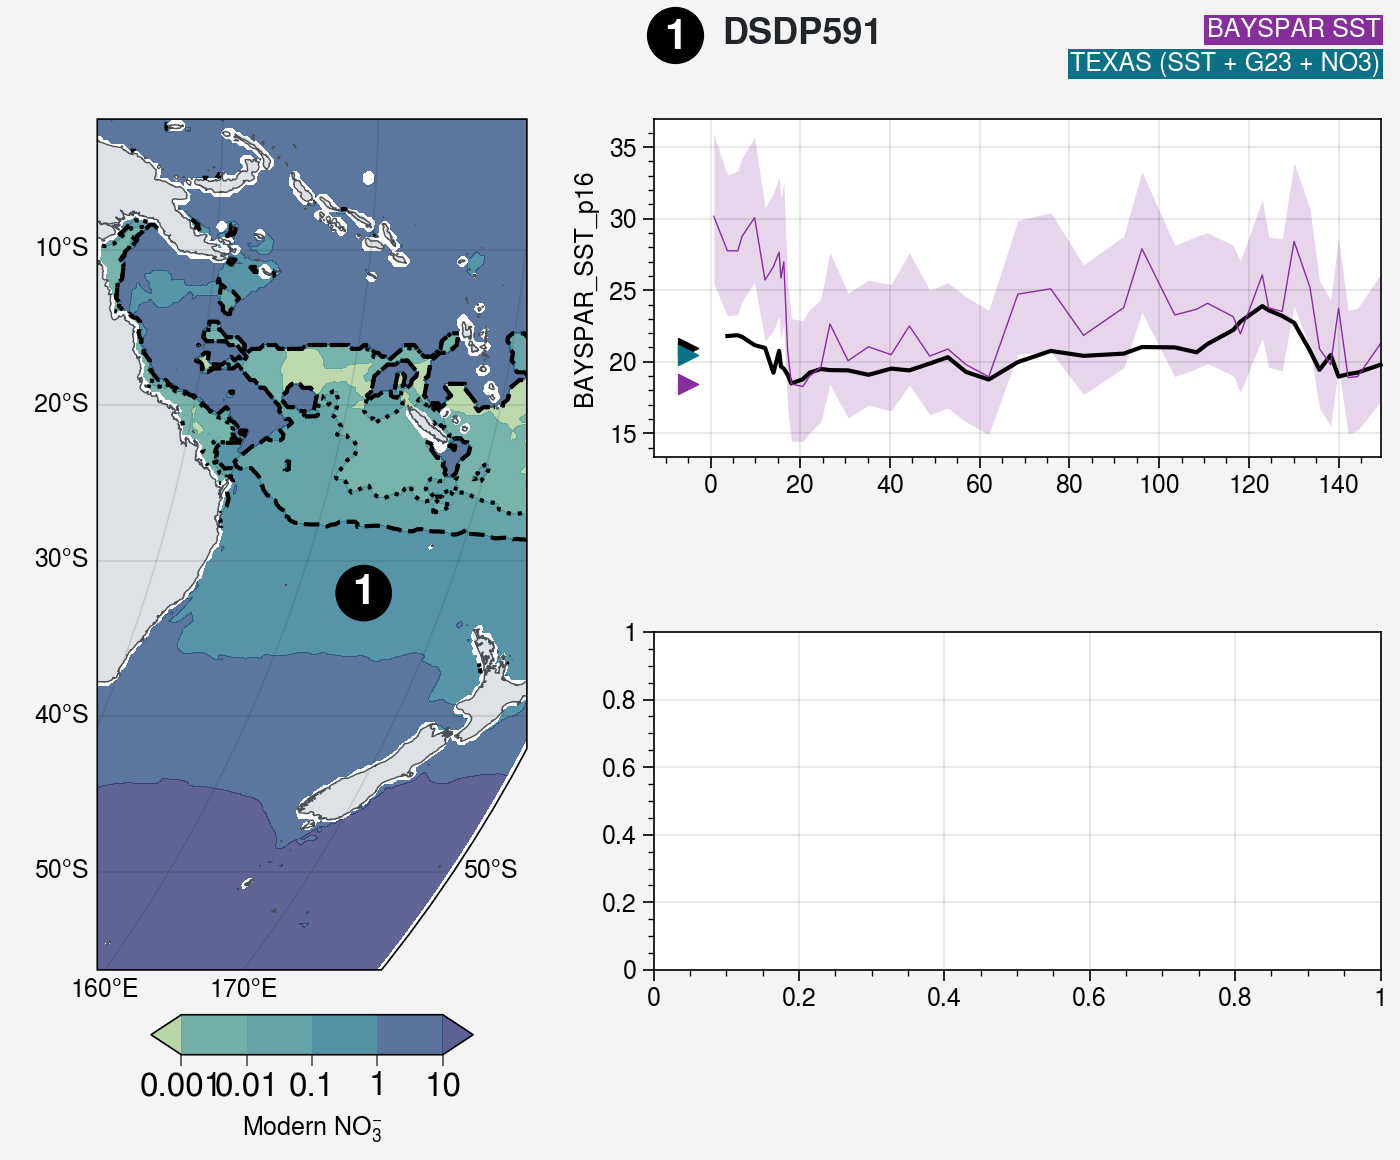

In [63]:
from cartopy import crs as ccrs
from collections import OrderedDict

# ============================================================
# CONTROL PANEL — edit only this section
# ============================================================
_map = 'thermoNO3'
sel_age_limit = 0.151
sel_site_list = [
    'DSDP591',
    'U1510',
]

site_yparam_dict = {
    'DSDP591': {
        'params':   ['BAYSPAR_SST',
                    #  'pred_SST_TEXAS_scaledRI_cren3',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_001'
                     ],
        'band_pct': (16, 84),
        'band_params': ['BAYSPAR_SST',
                        'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3'],
        
    },
    'U1510': {
        'params':   ['BAYSPAR_SST',
                    #  'pred_SST_TEXAS_scaledRI_cren3',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_001'
                     ],
        'band_pct': (16, 84),
        'band_params': ['BAYSPAR_SST',
                        'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3'],
    },
}

# Secondary y-axis config — omit a site to skip twin axis
site_twinx_dict = {
    'DSDP591': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 11),
        'yaxis_lim':   (5, 20),
        'yticks':      np.arange(5, 11.1, 3),
        'hlines':      [5],
        'hline_style': {'lw': 0.7, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 0,
    },
    'U1510': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 11),
        'yaxis_lim':   (5, 25),
        'yticks':      np.arange(5, 11.1, 3),
        'hlines':      [5],
        'hline_style': {'lw': 0.7, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 0,
    },
}

site_twinx2_dict = {
    'DSDP591': {
        'col':         'gdgt_conc_ug_g',   # ← your actual column name
        'label':       r'iGDGT Conc. ($\mu$g/g)',
        'color':       'denim',
        'ydata_lim':   (0, 0.6),
        'yaxis_lim':   (0, 1.5),
        'yticks':      np.arange(0, 0.7, 0.2),
        'hline_style': {'lw': 0.5, 'ls': ':', 'alpha': 0.7},
    },
    'U1510': {
        'col':         'gdgt_conc_ug_g',   # ← your actual column name
        'label':       r'iGDGT Conc. ($\mu$g/g)',
        'color':       'denim',
        'ydata_lim':   (0, 1),
        'yaxis_lim':   (0, 2),
        'yticks':      np.arange(0, 1.1, 0.2),
        'hline_style': {'lw': 0.5, 'ls': ':', 'alpha': 0.7},
    },
}

yaxis_dict = {
    'DSDP591': {
        'ylim':    (0, 30),
        'yticks':  np.arange(0, 40, 5),
        'ybounds': (10, 30),          # spine drawn only between these values
    },
    'U1510': {
        'ylim':    (-5, 30),
        'yticks':  np.arange(0, 40, 5),
        'ybounds': (5, 30),
    },
}

# Map padding
pad_latmax = 30
pad_latmin = 20
pad_lonmin = 5
pad_lonmax = 5

# Figure sizing
height_per_site = 2
legend_space    = 1.8
fig_width       = 7
hspace_base     = 7
hspace_compensate = 0.25   # reduce gap at map→empty boundary

# ============================================================
# LOOKUP DICTS — edit to add new methods
# ============================================================
method_color_dict = {
    'SST_Schouten02':                          ('red9',   '-'),
    'SST_Kim10':                               ('yellow9','-'),
    'BAYSPAR_SST':                             ('grape9', '-'),
    'BAYSPAR_subT':                            ('grape9', '-'),
    'pred_thermoT_TEXAS_scaledRI_cren3':       ('cyan9',   '--'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': ('cyan9',  '-'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_01': ('cyan9',  '--'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_001': ('cyan9',  ':'),
    'pred_SST_TEXAS_scaledRI_cren3':           ('cyan9',   '--'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': ('cyan9',  '-'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01': ('cyan9',  '--'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_001': ('cyan9',  ':'),
}

text_annotation_dict = {
    'BAYSPAR: SST': 'BAYSPAR_SST',
    'BAYSPAR: subT': 'BAYSPAR_subT',
    'TEXAS: SST': 'pred_SST_TEXAS_scaledRI_cren3',
    'TEXAS: SST': 'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3',
    'TEXAS: SST': 'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01',
    'TEXAS: SST': 'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_001',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_01',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_001',
}

method_label_dict = {
    'SST_Schouten02':                          'Schouten et al. 2002',
    'SST_Kim10':                               r'TEX$^{H}_{86}$',
    'BAYSPAR_SST':                             'BAYSPAR SST',
    'BAYSPAR_subT':                            'BAYSPAR subT',
    'pred_thermoT_TEXAS_scaledRI_cren3':       'TEXAS Thermo-T',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': 'TEXAS (Thermo-T + G23)',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS (Thermo-T + G23 + NO3)',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_01': 'TEXAS (Thermo-T + G23 + NO3)',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_001': 'TEXAS (Thermo-T + G23 + NO3)',
    'pred_SST_TEXAS_scaledRI_cren3':           'TEXAS SST',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     'TEXAS (SST + G23)',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS (SST + G23 + NO3)',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01': 'TEXAS (SST + G23 + NO3)',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_001': 'TEXAS (SST + G23 + NO3)',
}

# Collapse BAYSPAR/TEXAS variants to single legend entry
# Band entries are built dynamically — no hardcoded band strings needed
legend_label_remap = {
    'BAYSPAR_SST':                             'BAYSPAR',
    'BAYSPAR_subT':                            'BAYSPAR',
    'pred_thermoT_TEXAS_scaledRI_cren3':       'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': 'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_01': 'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3_001': 'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3':           'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3':     'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01':     'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_001':     'TEXAS',
}

# ============================================================
# DATA PREPARATION
# ============================================================
n_sites       = len(sel_site_list)
site_axs_dict = {site: i + 1 for i, site in enumerate(sel_site_list)}

plot_data = (
    PhanTEX_GIG_df[PhanTEX_GIG_df['Age'] < sel_age_limit]
    [PhanTEX_GIG_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False]
    [(((PhanTEX_GIG_df['TEX86']>0.5)&(PhanTEX_GIG_df['SiteName']=='MD98-2152'))|(PhanTEX_GIG_df['SiteName']!='MD98-2152'))]
    [PhanTEX_GIG_df['gdgt23ratio']<15]
    [PhanTEX_GIG_df['SiteName'].isin(sel_site_list)]
    .reset_index(drop=True)
)
plot_data['SiteName'] = pd.Categorical(
    plot_data['SiteName'], categories=sel_site_list, ordered=True
)

plot_alk_data = (
    PhanAlk_GIG_df[PhanAlk_GIG_df['Age'] < sel_age_limit]
    [PhanAlk_GIG_df['SiteName'].isin(sel_site_list)]
    .reset_index(drop=True)
)

plot_alk_conc_data = tasman_sea_GDGT_df
site_name_col = 'SiteName'

# Auto map extent
site_lats = plot_data.groupby('SiteName')['ModLat'].first()
site_lons = plot_data.groupby('SiteName')['ModLon'].first()
lat_min = max(site_lats.min() - pad_latmin, -90)
lat_max = min(site_lats.max() + pad_latmax,  90)
lon_min = max(site_lons.min() - pad_lonmin, -180)
lon_max = min(site_lons.max() + pad_lonmax,  180)

# ============================================================
# FIGURE SETUP
# ============================================================
map_rows   = max(2, round(n_sites / 2))
array      = [[1 if row < map_rows else 0, row + 2] for row in range(n_sites)]
hratios    = [1] * n_sites
fig_height = height_per_site * n_sites + legend_space

hspace_vals = []
for gap_idx in range(n_sites - 1):
    if gap_idx == map_rows - 1:
        hspace_vals.append(hspace_compensate)
    else:
        hspace_vals.append(hspace_base)

fig, axs = plot.subplots(
    array,
    width=fig_width, height=fig_height,
    proj={1: 'eck3'},
    hspace=hspace_vals,
    wratios=[1, 1.5],
    hratios=hratios,
    share=0,
)

# ============================================================
# MAP PANEL
# ============================================================
ax = axs[0]
ax.format(
    land=True, landcolor='gray3', landzorder=0,
    coast=False, # coastcolor='gray7', coastzorder=1,
    latlabels=True, lonlabels=True, latlines=10, lonlines=10,
    latlim=(lat_min, lat_max),
    lonlim=(lon_min, lon_max),
)
import cartopy.feature as cfeature
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),   # '110m' → '50m' → '10m'
               linewidth=0.5, edgecolor='gray7', zorder=1)

if _map == 'SST':
    plot_T   = T_da.isel(depth=0).values
    plot_lat = T_da['lat'].values
    plot_lon = T_da['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=np.arange(20, 30.1, 1), extend='both',
                    vmin=20, vmax=30, cmap='thermal', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label='Modern SST (°C)', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
if _map == 'thermoT':
    plot_T   = ocean_prop_ds['t_sf2tc_avg'].values
    plot_lat = ocean_prop_ds['lat'].values
    plot_lon = ocean_prop_ds['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=np.arange(20, 30.1, 2), extend='both',
                    vmin=20, vmax=30, cmap='thermal', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label='Modern thermo-T (°C)', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
if _map == 'thermoNO3':
    plot_T   = ocean_prop_ds['no3_sf2tc_avg'].values
    plot_lat = ocean_prop_ds['lat'].values
    plot_lon = ocean_prop_ds['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=[0.001,0.01,0.1,1,10], extend='both',
                    cmap='Crest', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label=r'Modern NO$_{3}^{-}$', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
    ax.contour(plot_lon, plot_lat, plot_T,levels=[0.1],c='k',ls='--')
    ax.contour(plot_lon, plot_lat, plot_T,levels=[0.01],c='k',ls=':')
     

# ============================================================
# MAIN SITE LOOP
# ============================================================
grouped      = plot_data.groupby('SiteName')
legend_items = OrderedDict()

for i, (group_name, group_data) in enumerate(grouped):

    modLat = group_data['ModLat'].unique()[0]
    modLon = group_data['ModLon'].unique()[0]

    # Pre-compute modern reference values
    mod_SST        = T_da.isel(depth=0).sel(lat=modLat, lon=modLon, method='nearest').values
    mod_subT_gamma = subT.sel(lat=modLat, lon=modLon, method='nearest').values
    thermoT        = ocean_prop_ds.sel(lat=modLat, lon=modLon, method='nearest')['t_sf2tc_avg'].values

    print("modern NO3", group_name,
          ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat, lon=modLon, method='nearest').values)

    # --- Map marker + number ---
    # axs[0].plot(modLon, modLat, marker='o', markersize=15,
    #             c='k', mec='w', mew=0.5)
    axs[0].text(modLon, modLat - 0.5, i + 1,
                fontweight='bold', fontsize=15,
                ha='center', va='center', color='white',
                transform=ccrs.PlateCarree(),
               bbox=dict(facecolor='k', boxstyle='circle,pad=0.2',
                         edgecolor='none')
                )

    ax = axs[site_axs_dict[group_name]]

    # --- Modern reference markers (legend registered once via setdefault) ---
    h1 = ax.scatter(-5, mod_SST,        marker='>', color='k',                                                s=50)
    h2 = ax.scatter(-5, mod_subT_gamma, marker='>', color=method_color_dict['BAYSPAR_subT'][0],               s=50)
    h3 = ax.scatter(-5, thermoT,        marker='>', color=method_color_dict['pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3'][0], s=50)
    legend_items.setdefault('Modern SST',                    h1)
    legend_items.setdefault('Modern subT',   h2)
    legend_items.setdefault('Modern thermoT',                h3)

    # --- Circled number + site label ---
    y_pos = 1.25 if 'U1510' in group_name else 1.25
    ax.scatter(0.06-0.03, y_pos, marker='o', color='k', markersize=400,
               transform=ax.transAxes, clip_on=False, zorder=-1)
    ax.text(0.06-0.03, y_pos - 0.01, i + 1,
            transform=ax.transAxes, fontsize=15, fontweight='bold',
            ha='center', va='center', color='white')
    ax.text(0.125-0.03, y_pos, group_name,
            transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='left', va='center', color='gray9')
    
    # --- Alkenone ---
    sel_alk_data = plot_alk_data[plot_alk_data['SiteName'] == group_name]
    if not sel_alk_data.empty:
        h, = ax.plot(sel_alk_data['Age'].values * 1000, sel_alk_data['predSST'].values,
                    color='k', lw=1.5, clip_on=False)
        legend_items.setdefault(u"U$^{K'}_{37}$ SST", h)

    # --- Per-site param config ---
    site_cfg         = site_yparam_dict.get(group_name, {})
    yparam_list_site = site_cfg.get('params', [])
    plo, phi         = site_cfg.get('band_pct', (16, 84))
    band_label_str   = f'P{plo}-P{phi}'
    band_params      = site_cfg.get('band_params', yparam_list_site)

    # STEP 1: detect variants + colors for annotation
    bayspar_variant = None
    texas_variant   = None
    bayspar_color   = None
    texas_color     = None
    bayspar_label   = None
    texas_label     = None
    
    for yparam in yparam_list_site:
        if 'BAYSPAR' in yparam:
            bayspar_variant = 'subT' if 'subT' in yparam else 'SST'
            bayspar_color   = method_color_dict[yparam][0]
            bayspar_label = method_label_dict.get(yparam,'unknown')
            
        if 'TEXAS' in yparam:
            texas_variant = 'Thermo-T' if 'thermo' in yparam.lower() else 'SST'
            texas_color   = method_color_dict[yparam][0]
            texas_label = method_label_dict.get(yparam,'unknown')

    # STEP 2: per-panel variant annotation with colored background boxes
    y_pos = 1.35 if 'U1510' in group_name else 1.3
    if bayspar_variant:
        ax.text(1, y_pos, f'{bayspar_label}',
                transform=ax.transAxes,
                fontsize=9, ha='right', va='top', color='w',
                bbox=dict(facecolor=bayspar_color, alpha=1,
                        edgecolor='none', boxstyle='square,pad=0.1'))
        y_pos -= 0.1
    if texas_variant:
        ax.text(1, y_pos, f'{texas_label}',
                transform=ax.transAxes,
                fontsize=9, ha='right', va='top', color='w',
                bbox=dict(facecolor=texas_color, alpha=1,
                        edgecolor='none', boxstyle='square,pad=0.1'))
        
    # STEP 3: plot each parameter
    for j, yparam in enumerate(yparam_list_site):
        plot_age   = group_data['Age'].values * 1000
        plot_TEX86 = group_data[yparam].values

        h, = ax.plot(plot_age, plot_TEX86,
                     ls=method_color_dict[yparam][1],
                     c=method_color_dict[yparam][0],
                     lw=1.25 if 'Tg23r' in yparam else 0.5,
                     clip_on=False)
        leg_label = legend_label_remap.get(yparam, method_label_dict[yparam])
        legend_items.setdefault(leg_label, h)

        if 'BAYSPAR' in yparam and yparam in band_params:
            col  = f'BAYSPAR_subT_p{plo}' if 'subT' in yparam else f'BAYSPAR_SST_p{plo}'
            col2 = f'BAYSPAR_subT_p{phi}' if 'subT' in yparam else f'BAYSPAR_SST_p{phi}'
            hf = ax.fill_between(plot_age, group_data[col], group_data[col2],
                                 c=method_color_dict[yparam][0], alpha=0.2,
                                 clip_on=False, lw=0)
            # legend_items.setdefault(f'BAYSPAR | {band_label_str}', hf)

        if 'TEXAS' in yparam and yparam in band_params:
            hf = ax.fill_between(plot_age,
                                 group_data[f'{yparam}_p{plo}'],
                                 group_data[f'{yparam}_p{phi}'],
                                 c=method_color_dict[yparam][0], alpha=0.2,
                                 clip_on=False, lw=0)
            # legend_items.setdefault(f'TEXAS | {band_label_str}', hf)

    # STEP 4: optional secondary y-axis
    twin_cfg = site_twinx_dict.get(group_name)
    if twin_cfg is not None:
        ax2 = ax.twinx()

        plot_sec = group_data[twin_cfg['col']].values
        # h_sec, = ax2.plot(plot_age, plot_sec,
        #                   color=twin_cfg['color'], lw=0.5, clip_on=False)
        # legend_items.setdefault(twin_cfg['label'], h_sec)

        ylo, yhi      = twin_cfg['yaxis_lim']
        bottom_offset = twin_cfg.get('bottom_offset', 0)
        ax2.set_ylim(ylo + bottom_offset, yhi)
        ax2.set_yticks(twin_cfg['yticks'])
        ax2.minorticks_off()
        ax2.tick_params(axis='y', labelsize=10,
                        labelcolor=twin_cfg['color'],
                        color=twin_cfg['color'])

        ytick_min, ytick_max = twin_cfg['ydata_lim']
        ax2.spines['right'].set_visible(True)
        ax2.spines['right'].set_position(('outward', 10))
        ax2.spines['right'].set_color(twin_cfg['color'])
        ax2.spines['right'].set_bounds(ytick_min, ytick_max)
        ax2.spines['top'].set_visible(False)

        ax2.yaxis.set_label_text('')
        ax2.yaxis.label.set_visible(False)
        ymid = (ytick_min + ytick_max) / 2
        ax2.text(1.12, ymid, 'G23',
                 transform=ax2.get_yaxis_transform(),
                 fontsize=10, color=twin_cfg['color'],
                 ha='left', va='center', rotation=90)

        hlines = twin_cfg.get('hlines', [])
        if isinstance(hlines, (int, float)):
            hlines = [hlines]
        hline_style = twin_cfg.get('hline_style', {'lw': 0.5, 'ls': '--', 'alpha': 0.7})
        for hval in hlines:
            ax2.axhline(hval, color=twin_cfg['color'], **hline_style)
            ax2.fill_between(
                plot_age, hval, plot_sec,
                where=(plot_sec >= hval),
                color=twin_cfg['color'], alpha=0.35, lw=0,
                zorder=0,
                clip_on=False)
            ax2.fill_between(
                plot_age, hval, plot_sec,
                where=(plot_sec < hval),
                color=twin_cfg['color'], alpha=0.15, lw=0,
                zorder=0,
                clip_on=False)
    
    # STEP 4b: optional third y-axis (offset further right)
    twin2_cfg = site_twinx2_dict.get(group_name)
    if twin2_cfg is not None:
        idx = (plot_alk_conc_data[twin2_cfg['col']]<1) & (plot_alk_conc_data['Age']<150)
        sel_alk_conc_data = plot_alk_conc_data[idx][plot_alk_conc_data[site_name_col] == group_name]
        if not sel_alk_conc_data.empty:
            ax3 = ax.twinx()

            plot_age2  = sel_alk_conc_data['Age'].values   # ← use its own age
            plot_sec2  = sel_alk_conc_data[twin2_cfg['col']].values
            # h_sec2, = ax3.plot(plot_age, plot_sec2,
            #                 color=twin2_cfg['color'], lw=1, clip_on=False)
            
            ax3.fill_between(
                plot_age2, 0, plot_sec2,
                color=twin2_cfg['color'], alpha=0.5, lw=0,
                zorder=1,
                clip_on=False)
            # legend_items.setdefault(twin2_cfg['label'], h_sec2)

            ylo2, yhi2 = twin2_cfg['yaxis_lim']
            ax3.set_ylim(ylo2, yhi2)
            ax3.set_yticks(twin2_cfg['yticks'])
            ax3.minorticks_off()
            ax3.tick_params(axis='y', labelsize=10,
                            labelcolor=twin2_cfg['color'],
                            color=twin2_cfg['color'])

            ytick_min2, ytick_max2 = twin2_cfg['ydata_lim']
            ax3.spines['right'].set_visible(True)
            ax3.spines['right'].set_position(('outward', 40))  # ← offset past G23 spine
            ax3.spines['right'].set_color(twin2_cfg['color'])
            ax3.spines['right'].set_bounds(ytick_min2, ytick_max2)
            ax3.spines['top'].set_visible(False)
            ax3.spines['left'].set_visible(False)

            ymid2 = (ytick_min2 + ytick_max2) / 2
            ax3.text(1.3, ymid2, twin2_cfg['label'],      # ← push label further right
                    transform=ax3.get_yaxis_transform(),
                    fontsize=10, color=twin2_cfg['color'],
                    ha='left', va='center', rotation=90)
            
    else:
        ax.spines['right'].set_visible(False)

    # # STEP 5: site-specific extras
    # if group_name in ['DSDP591', 'U1510']:
    #     published_T = (group_data['TEX86'] - 0.330) / 0.012
    #     h, = ax.plot(plot_age, published_T, color='blue9', lw=1.5, clip_on=False)
    #     legend_items.setdefault(r'Linear$_{thermo-T}$', h)



# ============================================================
# POST-LOOP FORMATTING
# ============================================================
axs[:, 1].format(grid=False, yreverse=False)

# Per-site primary y-axis config
for i, site in enumerate(sel_site_list):
    cfg    = yaxis_dict.get(site, {})
    ylim   = cfg.get('ylim',    (-5, 30))
    yticks = cfg.get('yticks',  np.arange(ylim[0], ylim[1] + 1, 5))
    ylo, yhi = cfg.get('ybounds', (yticks[0], yticks[-1]))

    ax = axs[i + 1]
    ax.format(ylim=ylim, yticks=yticks)
    ax.spines['left'].set_bounds(ylo, yhi)

# Spine cleanup — first pass (right spine guarded for twin panels)
for ax in axs[:, 1:]:
    ax.spines['top'].set_visible(False)
    site_for_ax = {v: k for k, v in site_axs_dict.items()}.get(
                   list(axs).index(ax), None)
    if site_for_ax not in site_twinx_dict:
        ax.spines['right'].set_visible(False)

for ax in axs:
    ax.spines['left'].set_color('gray7')

axs.format(fontsize=12, xticklabelcolor='gray7', yticklabelcolor='gray7')
axs[0].format(labelsize=12, labelcolor='gray7')

# Spine cleanup — second pass (bottom/ylabel for right column)
mid_idx = n_sites // 2 + 1

for ax in axs[:, 1:]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax != axs[-1, 1]:
        ax.spines['bottom'].set_visible(False)
    if ax == axs[-1, 1]:
        ax.spines['bottom'].set_position(('outward', 0))

    if ax == axs[mid_idx]:
        if n_sites == 2:
            ax.format(facecolor='none',
                    ylabel='',
                    ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
            ax.set_ylabel('Reconstructed Temperature (°C)', y=1.2) 
        else:
            ax.format(facecolor='none',
                    ylabel='Reconstructed Temperature (°C)',
                    ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
    else:
        ax.format(facecolor='none', ylabel='')

# Axis labels
axs.format(fontsize=12, xticklabelcolor='gray7', yticklabelcolor='gray7')
axs[-1, 1].text(0.5, -0.25, 'Age (ka)',
                fontsize=12, fontweight='bold', color='gray9',
                ha='center', va='center', transform=axs[-1, 1].transAxes)


plot.rc['abc'] = False

# Legend below map
axs[-1].legend(list(legend_items.values())[:4], 
               list(legend_items.keys())[:4],
              loc='b', fontsize=12, ncol=3,
              bbox_to_anchor=(0.5, -0.15),
              borderaxespad=0., frameon=False)
# ============================================================
# SAVE
# ============================================================
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig11_TasmanSea_example_sites_comparison{FIG_TAG}.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')


## GIG showcase

In [ ]:
url = 'https://www.ncei.noaa.gov/pub/data/paleo/paleocean/indian_ocean/tran2025/tran2025-u1482-bio-sst.txt'
Tran2025_df = pd.read_csv(url,comment='#',delimiter='\t')
Tran2025_df['Age'] = Tran2025_df['age_ka']/1000

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'U1482_MgCa_SST.xlsx'
Tran2025_BayMG_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='MgCa_Pei2021')
Tran2025_BayMG_df

#### Fig. 12 | TEXAS temperature reconstructions compared with published records at two Eastern Indian Ocean sites spanning the last 350~ka

In [ ]:
from cartopy import crs as ccrs
from collections import OrderedDict

# ============================================================
# CONTROL PANEL — edit only this section
# ============================================================
T_map = 'SST'
sel_age_limit = 0.351
sel_site_list = [
    'MD98-2152', 
    'U1482',
]

site_yparam_dict = {
    'MD98-2152': {
        'params':   ['BAYSPAR_subT',
                     'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3'],
        'band_pct': (16, 84),
    },
    'U1482': {
        'params':   ['BAYSPAR_SST',
                     'pred_SST_TEXAS_scaledRI_cren3',
                     'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3'],
        'band_pct': (16, 84),
        'band_params': ['BAYSPAR_SST',
                        'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3'],
    },
}

# Secondary y-axis config — omit a site to skip twin axis
site_twinx_dict = {
    'MD98-2152': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 7),
        'yaxis_lim':   (5, 15),
        'yticks':      np.arange(5, 7.1, 1),
        'hlines':      [5],
        'hline_style': {'lw': 0.8, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 10,
    },
    'U1482': {
        'col':         'gdgt23ratio',
        'label':       'GDGT-2/GDGT-3 (G23)',
        'color':       'wine',
        'ydata_lim':   (5, 7),
        'yaxis_lim':   (5, 15),
        'yticks':      np.arange(5, 7.1, 1),
        'hlines':      [5],
        'hline_style': {'lw': 0.7, 'ls': '--', 'alpha': 0.7},
        'bottom_offset': 0,
    },
}

site_twinx2_dict = {
    'U1482': {
        'col':         'uk37_total',   # ← your actual column name
        'label':       'Alk. productivity',
        'color':       'denim',
        'ydata_lim':   (0, 4),
        'yaxis_lim':   (0, 8),
        'yticks':      np.arange(0, 4.1, 1),
        'hline_style': {'lw': 0.5, 'ls': ':', 'alpha': 0.7},
    },
}


yaxis_dict = {
    'MD98-2152': {
        'ylim':    (12, 30),
        'yticks':  np.arange(12, 31, 5),
        'ybounds': (16, 30),          # spine drawn only between these values
    },
    'U1482': {
        'ylim':    (8, 40),
        'yticks':  np.arange(8, 40, 5),
        'ybounds': (18, 40),
    },
}

# Map padding
pad_latmax = 30
pad_latmin = 20
pad_lonmin = 5
pad_lonmax = 5

# Figure sizing
height_per_site = 2
legend_space    = 1.8
fig_width       = 8
hspace_base     = 7
hspace_compensate = 0.25   # reduce gap at map→empty boundary

# ============================================================
# LOOKUP DICTS — edit to add new methods
# ============================================================
method_color_dict = {
    'SST_Schouten02':                          ('red9',   '-'),
    'SST_Kim10':                               ('yellow9','-'),
    'BAYSPAR_SST':                             ('grape9', '-'),
    'BAYSPAR_subT':                            ('grape9', '-'),
    'pred_thermoT_TEXAS_scaledRI_cren3':       ('cyan9',   '--'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': ('cyan9',  '-'),
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': ('cyan9',  '-'),
    'pred_SST_TEXAS_scaledRI_cren3':           ('cyan9',   '--'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     ('cyan9',  '-'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': ('cyan9',  '-'),
}

text_annotation_dict = {
    'BAYSPAR: SST': 'BAYSPAR_SST',
    'BAYSPAR: subT': 'BAYSPAR_subT',
    'TEXAS: SST': 'pred_thermoT_TEXAS_scaledRI_cren3',
    'TEXAS: SST': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r',
    'TEXAS: SST': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r',
    'TEXAS: Thermo-T': 'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3',
}

method_label_dict = {
    'SST_Schouten02':                          'Schouten et al. 2002',
    'SST_Kim10':                               r'TEX$^{H}_{86}$',
    'BAYSPAR_SST':                             'BAYSPAR SST',
    'BAYSPAR_subT':                            'BAYSPAR subT',
    'pred_thermoT_TEXAS_scaledRI_cren3':       'TEXAS Thermo-T',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': 'TEXAS (Thermo-T + G23)',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS (Thermo-T + G23 + NO3)',
    'pred_SST_TEXAS_scaledRI_cren3':           'TEXAS SST',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     'TEXAS (SST + G23)',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS (SST + G23 + NO3)',
}

# Collapse BAYSPAR/TEXAS variants to single legend entry
# Band entries are built dynamically — no hardcoded band strings needed
legend_label_remap = {
    'BAYSPAR_SST':                             'BAYSPAR',
    'BAYSPAR_subT':                            'BAYSPAR',
    'pred_thermoT_TEXAS_scaledRI_cren3':       'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r': 'TEXAS',
    'pred_thermoT_TEXAS_scaledRI_cren3_Tg23r_no3': 'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3':           'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r':     'TEXAS',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3':     'TEXAS',
}

# ============================================================
# DATA PREPARATION
# ============================================================
n_sites       = len(sel_site_list)
site_axs_dict = {site: i + 1 for i, site in enumerate(sel_site_list)}

plot_data = (
    PhanTEX_GIG_df[PhanTEX_GIG_df['Age'] < sel_age_limit]
    [PhanTEX_GIG_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False]
    [(((PhanTEX_GIG_df['TEX86']>0.5)&(PhanTEX_GIG_df['SiteName']=='MD98-2152'))|(PhanTEX_GIG_df['SiteName']!='MD98-2152'))]
    [PhanTEX_GIG_df['gdgt23ratio']<15]
    [PhanTEX_GIG_df['SiteName'].isin(sel_site_list)]
    .reset_index(drop=True)
)
plot_data['SiteName'] = pd.Categorical(
    plot_data['SiteName'], categories=sel_site_list, ordered=True
)

plot_alk_data = (
    PhanAlk_GIG_df[PhanAlk_GIG_df['Age'] < sel_age_limit]
    [PhanAlk_GIG_df['SiteName'].isin(sel_site_list)]
    .reset_index(drop=True)
)

plot_alk_conc_data = (
    Tran2025_df[Tran2025_df['Age'] < sel_age_limit] 
    .reset_index(drop=True)
)

# Auto map extent
site_lats = plot_data.groupby('SiteName')['ModLat'].first()
site_lons = plot_data.groupby('SiteName')['ModLon'].first()
lat_min = max(site_lats.min() - pad_latmin, -90)
lat_max = min(site_lats.max() + pad_latmax,  90)
lon_min = max(site_lons.min() - pad_lonmin, -180)
lon_max = min(site_lons.max() + pad_lonmax,  180)

# ============================================================
# FIGURE SETUP
# ============================================================
map_rows   = max(2, round(n_sites / 2))
array      = [[1 if row < map_rows else 0, row + 2] for row in range(n_sites)]
hratios    = [1] * n_sites
fig_height = height_per_site * n_sites + legend_space

hspace_vals = []
for gap_idx in range(n_sites - 1):
    if gap_idx == map_rows - 1:
        hspace_vals.append(hspace_compensate)
    else:
        hspace_vals.append(hspace_base)

fig, axs = plot.subplots(
    array,
    width=fig_width, height=fig_height,
    proj={1: 'eck3'},
    hspace=hspace_vals,
    wratios=[1, 1.5],
    hratios=hratios,
    share=0,
)

# ============================================================
# MAP PANEL
# ============================================================
ax = axs[0]
ax.format(
    land=True, landcolor='gray3', landzorder=0,
    coast=False, # coastcolor='gray7', coastzorder=1,
    latlabels=True, lonlabels=True, latlines=10, lonlines=10,
    latlim=(lat_min, lat_max),
    lonlim=(lon_min, lon_max),
)
import cartopy.feature as cfeature
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),   # '110m' → '50m' → '10m'
               linewidth=0.5, edgecolor='gray7', zorder=1)

if T_map == 'SST':
    plot_T   = T_da.isel(depth=0).values
    plot_lat = T_da['lat'].values
    plot_lon = T_da['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=np.arange(20, 30.1, 1), extend='both',
                    vmin=20, vmax=30, cmap='thermal', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label='Modern SST (°C)', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
if T_map == 'thermoT':
    plot_T   = ocean_prop_ds['t_sf2tc_avg'].values
    plot_lat = ocean_prop_ds['lat'].values
    plot_lon = ocean_prop_ds['lon'].values
    m = ax.contourf(plot_lon, plot_lat, plot_T,
                    levels=np.arange(20, 30.1, 2), extend='both',
                    vmin=20, vmax=30, cmap='thermal', alpha=0.75, zorder=-1)
    cbar = ax.colorbar(m, loc='b', label='Modern SST (°C)', shrink=0.75)
    cbar.ax.tick_params(labelsize=12, color='gray7')
# ============================================================
# MAIN SITE LOOP
# ============================================================
grouped      = plot_data.groupby('SiteName')
legend_items = OrderedDict()

for i, (group_name, group_data) in enumerate(grouped):

    modLat = group_data['ModLat'].unique()[0]
    modLon = group_data['ModLon'].unique()[0]

    # Pre-compute modern reference values
    mod_SST        = T_da.isel(depth=0).sel(lat=modLat, lon=modLon, method='nearest').values
    mod_subT_gamma = subT.sel(lat=modLat, lon=modLon, method='nearest').values
    thermoT        = ocean_prop_ds.sel(lat=modLat, lon=modLon, method='nearest')['t_sf2tc_avg'].values

    print("modern NO3", group_name,
          ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat, lon=modLon, method='nearest').values)

    # --- Map marker + number ---
    axs[0].text(modLon, modLat - 0.5, i + 1,
                fontweight='bold', fontsize=15,
                ha='center', va='center', color='white',
                transform=ccrs.PlateCarree(),
               bbox=dict(facecolor='k', boxstyle='circle,pad=0.2',
                         edgecolor='none')
                )

    ax = axs[site_axs_dict[group_name]]

    # --- Modern reference markers (legend registered once via setdefault) ---
    h1 = ax.scatter(-5, mod_SST,        marker='>', color='k',                                                s=50)
    h2 = ax.scatter(-5, mod_subT_gamma, marker='>', color=method_color_dict['BAYSPAR_subT'][0],               s=50)
    h3 = ax.scatter(-5, thermoT,        marker='>', color=method_color_dict['pred_thermoT_TEXAS_scaledRI_cren3_Tg23r'][0], s=50)
    legend_items.setdefault('Modern SST',                    h1)
    legend_items.setdefault('Modern subT',   h2)
    legend_items.setdefault('Modern thermoT',                h3)

    # --- 
    # number + site label ---
    y_pos = 1.15 if 'U1482' in group_name else 1.15
    ax.scatter(0.06-0.03, y_pos, marker='o', color='k', markersize=400,
               transform=ax.transAxes, clip_on=False, zorder=-1)
    ax.text(0.06-0.03, y_pos - 0.01, i + 1,
            transform=ax.transAxes, fontsize=15, fontweight='bold',
            ha='center', va='center', color='white')
    ax.text(0.125-0.03, y_pos, group_name,
            transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='left', va='center', color='gray9')
    
    # --- Alkenone ---
    sel_alk_data = plot_alk_data[plot_alk_data['SiteName'] == group_name]
    if not sel_alk_data.empty:
        if group_name != 'U1482':
            h, = ax.plot(sel_alk_data['Age'].values * 1000, sel_alk_data['predSST'].values,
                        color='k', lw=1.5, clip_on=False)
            legend_items.setdefault(u"U$^{K'}_{37}$ SST", h)

    # --- Per-site param config ---
    site_cfg         = site_yparam_dict.get(group_name, {})
    yparam_list_site = site_cfg.get('params', [])
    plo, phi         = site_cfg.get('band_pct', (16, 84))
    band_label_str   = f'P{plo}-P{phi}'
    band_params      = site_cfg.get('band_params', yparam_list_site)

    # STEP 1: detect variants + colors for annotation
    bayspar_variant = None
    texas_variant   = None
    bayspar_color   = None
    texas_color     = None
    bayspar_label   = None
    texas_label     = None
    
    for yparam in yparam_list_site:
        if 'BAYSPAR' in yparam:
            bayspar_variant = 'subT' if 'subT' in yparam else 'SST'
            bayspar_color   = method_color_dict[yparam][0]
            bayspar_label = method_label_dict.get(yparam,'unknown')
            
        if 'TEXAS' in yparam:
            texas_variant = 'Thermo-T' if 'thermo' in yparam.lower() else 'SST'
            texas_color   = method_color_dict[yparam][0]
            texas_label = method_label_dict.get(yparam,'unknown')

    # STEP 2: per-panel variant annotation with colored background boxes
    y_pos = 1.2 if 'U1482' in group_name else 1.18
    if bayspar_variant:
        ax.text(1, y_pos, f'{bayspar_label}',
                transform=ax.transAxes,
                fontsize=9, ha='right', va='top', color='w',
                bbox=dict(facecolor=bayspar_color, alpha=1,
                        edgecolor='none', boxstyle='square,pad=0.1'))
        y_pos -= 0.1
    if texas_variant:
        ax.text(1, y_pos, f'{texas_label}',
                transform=ax.transAxes,
                fontsize=9, ha='right', va='top', color='w',
                bbox=dict(facecolor=texas_color, alpha=1,
                        edgecolor='none', boxstyle='square,pad=0.1'))
        
    # STEP 3: plot each parameter
    for j, yparam in enumerate(yparam_list_site):
        plot_age   = group_data['Age'].values * 1000
        plot_TEX86 = group_data[yparam].values

        h, = ax.plot(plot_age, plot_TEX86,
                     ls=method_color_dict[yparam][1],
                     c=method_color_dict[yparam][0],
                     lw=1.25 if 'Tg23r' in yparam else 0.5,
                     clip_on=False)
        leg_label = legend_label_remap.get(yparam, method_label_dict[yparam])
        legend_items.setdefault(leg_label, h)

        if 'BAYSPAR' in yparam and yparam in band_params:
            col  = f'BAYSPAR_subT_p{plo}' if 'subT' in yparam else f'BAYSPAR_SST_p{plo}'
            col2 = f'BAYSPAR_subT_p{phi}' if 'subT' in yparam else f'BAYSPAR_SST_p{phi}'
            hf = ax.fill_between(plot_age, group_data[col], group_data[col2],
                                 c=method_color_dict[yparam][0], alpha=0.2,
                                 clip_on=False, lw=0, label="")
            # legend_items.setdefault(f'BAYSPAR | {band_label_str}', hf)

        if 'TEXAS' in yparam and yparam in band_params:
            hf = ax.fill_between(plot_age,
                                 group_data[f'{yparam}_p{plo}'],
                                 group_data[f'{yparam}_p{phi}'],
                                 c=method_color_dict[yparam][0], alpha=0.2,
                                 clip_on=False, lw=0, label="")
            # legend_items.setdefault(f'TEXAS | {band_label_str}', hf)

    # STEP 4: optional secondary y-axis
    twin_cfg = site_twinx_dict.get(group_name)
    if twin_cfg is not None:
        ax2 = ax.twinx()

        plot_sec = group_data[twin_cfg['col']].values
        # h_sec, = ax2.plot(plot_age, plot_sec,
        #                   color=twin_cfg['color'], lw=0.5, clip_on=False)
        # legend_items.setdefault(twin_cfg['label'], h_sec)

        ylo, yhi      = twin_cfg['yaxis_lim']
        bottom_offset = twin_cfg.get('bottom_offset', 0)
        ax2.set_ylim(ylo + bottom_offset, yhi)
        ax2.set_yticks(twin_cfg['yticks'])
        ax2.minorticks_off()
        ax2.tick_params(axis='y', labelsize=10,
                        labelcolor=twin_cfg['color'],
                        color=twin_cfg['color'])

        ytick_min, ytick_max = twin_cfg['ydata_lim']
        ax2.spines['right'].set_visible(True)
        ax2.spines['right'].set_position(('outward', 10))
        ax2.spines['right'].set_color(twin_cfg['color'])
        ax2.spines['right'].set_bounds(ytick_min, ytick_max)
        ax2.spines['top'].set_visible(False)

        ax2.yaxis.set_label_text('')
        ax2.yaxis.label.set_visible(False)
        
        ymid = (ytick_min + ytick_max) / 2
        ax2.text(1.12, ymid, 'G23',
                 transform=ax2.get_yaxis_transform(),
                 fontsize=10, color=twin_cfg['color'],
                 ha='left', va='center', rotation=90)

        hlines = twin_cfg.get('hlines', [])
        if isinstance(hlines, (int, float)):
            hlines = [hlines]
        hline_style = twin_cfg.get('hline_style', {'lw': 0.5, 'ls': '--', 'alpha': 0.7})
        for hval in hlines:
            ax2.axhline(hval, color=twin_cfg['color'], **hline_style)
            ax2.fill_between(
                plot_age, hval, plot_sec,
                where=(plot_sec >= hval),
                color=twin_cfg['color'], alpha=0.35, lw=0,
                zorder=1,
                clip_on=False, label="")
            ax2.fill_between(
                plot_age, hval, plot_sec,
                where=(plot_sec < hval),
                color=twin_cfg['color'], alpha=0.15, lw=0,
                zorder=1,
                clip_on=False, label="")
    
    # STEP 4b: optional third y-axis (offset further right)
    twin2_cfg = site_twinx2_dict.get(group_name)
    if twin2_cfg is not None:
        sel_alk_conc_data = plot_alk_conc_data[plot_alk_conc_data['site_ID'] == group_name]
        if not sel_alk_conc_data.empty:
            ax3 = ax.twinx()

            plot_age2  = sel_alk_conc_data['age_ka'].values   # ← use its own age
            plot_sec2  = sel_alk_conc_data[twin2_cfg['col']].values
            # h_sec2, = ax3.plot(plot_age, plot_sec2,
            #                 color=twin2_cfg['color'], lw=1, clip_on=False)
            
            ax3.fill_between(
                plot_age2, 0, plot_sec2,
                color=twin2_cfg['color'], alpha=0.15, lw=0,
                zorder=0,
                clip_on=False, label="")
            # legend_items.setdefault(twin2_cfg['label'], h_sec2)

            ylo2, yhi2 = twin2_cfg['yaxis_lim']
            ax3.set_ylim(ylo2, yhi2)
            ax3.set_yticks(twin2_cfg['yticks'])
            ax3.minorticks_off()
            ax3.tick_params(axis='y', labelsize=10,
                            labelcolor=twin2_cfg['color'],
                            color=twin2_cfg['color'])

            ytick_min2, ytick_max2 = twin2_cfg['ydata_lim']
            ax3.spines['right'].set_visible(True)
            ax3.spines['right'].set_position(('outward', 40))  # ← offset past G23 spine
            ax3.spines['right'].set_color(twin2_cfg['color'])
            ax3.spines['right'].set_bounds(ytick_min2, ytick_max2)
            ax3.spines['top'].set_visible(False)
            ax3.spines['left'].set_visible(False)

            ymid2 = (ytick_min2 + ytick_max2) / 2
            ax3.text(1.25, ymid2, twin2_cfg['label'],      # ← push label further right
                    transform=ax3.get_yaxis_transform(),
                    fontsize=10, color=twin2_cfg['color'],
                    ha='left', va='center', rotation=90)
            
    else:
        ax.spines['right'].set_visible(False)

    # # STEP 5: site-specific extras
    # if group_name in ['DSDP591', 'U1510']:
    #     published_T = (group_data['TEX86'] - 0.330) / 0.012
    #     h, = ax.plot(plot_age, published_T, color='blue9', lw=1.5, clip_on=False)
    #     legend_items.setdefault(r'Linear$_{thermo-T}$', h)



# ============================================================
# POST-LOOP FORMATTING
# ============================================================
axs[:, 1].format(grid=False, yreverse=False)

# Per-site primary y-axis config
for i, site in enumerate(sel_site_list):
    cfg    = yaxis_dict.get(site, {})
    ylim   = cfg.get('ylim',    (-5, 30))
    yticks = cfg.get('yticks',  np.arange(ylim[0], ylim[1] + 1, 5))
    ylo, yhi = cfg.get('ybounds', (yticks[0], yticks[-1]))

    ax = axs[i + 1]
    ax.format(ylim=ylim, yticks=yticks)
    ax.spines['left'].set_bounds(ylo, yhi)


# Spine cleanup — first pass (right spine guarded for twin panels)
for ax in axs[:, 1:]:
    ax.spines['top'].set_visible(False)
    site_for_ax = {v: k for k, v in site_axs_dict.items()}.get(
                   list(axs).index(ax), None)
    if site_for_ax not in site_twinx_dict:
        ax.spines['right'].set_visible(False)

for ax in axs:
    ax.spines['left'].set_color('gray7')

axs.format(fontsize=12, xticklabelcolor='gray7', yticklabelcolor='gray7')
axs[0].format(labelsize=12, labelcolor='gray7')

# Spine cleanup — second pass (bottom/ylabel for right column)
mid_idx = n_sites // 2 + 1

for ax in axs[:, 1:]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax != axs[-1, 1]:
        ax.spines['bottom'].set_visible(False)
    if ax == axs[-1, 1]:
        ax.spines['bottom'].set_position(('outward', 0))

    if ax == axs[mid_idx]:
        if n_sites == 2:
            ax.format(facecolor='none',
                    ylabel='',
                    ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
            ax.set_ylabel('Reconstructed Temperature (°C)', y=1.2) 
        else:
            ax.format(facecolor='none',
                    ylabel='Reconstructed Temperature (°C)',
                    ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
    else:
        ax.format(facecolor='none', ylabel='')

# Axis labels
axs.format(fontsize=12, xticklabelcolor='gray7', yticklabelcolor='gray7')
axs[-1, 1].text(0.5, -0.25, 'Age (ka)',
                fontsize=12, fontweight='bold', color='gray9',
                ha='center', va='center', transform=axs[-1, 1].transAxes)


plot.rc['abc'] = False
####
plot_data = Tran2025_df ### 'age_ka''sst_tex_low', 'sst_tex_med', 'sst_tex_high'
age_idx = Tran2025_df['age_ka'] < 350
axs[1,1].plot(Tran2025_df[age_idx]['age_ka'],Tran2025_df[age_idx]['sst_uk_med'],c='k',zorder=0)
# axs[1,1].fill_between(Tran2025_df[age_idx]['age_ka'],
#                       Tran2025_df[age_idx]['sst_tex_low'],Tran2025_df[age_idx]['sst_tex_high'],
#                       alpha=0.1)
plot_data = Tran2025_BayMG_df[Tran2025_BayMG_df['Age_ka']<350]
axs[-1].plot(plot_data['Age_ka'],plot_data['Mg_SST'],lw=0.5, c='blue9',label='BAYMAG')
hh2, ll2 = axs[-1].get_legend_handles_labels()
# Legend below map
axs[-1].legend(list(legend_items.values())[:4]+[hh2[1]], 
               list(legend_items.keys())[:4]+[ll2[1]],
              loc='b', fontsize=12, ncol=3,
              bbox_to_anchor=(0.5, -0.15),
              borderaxespad=0., frameon=False)
# ============================================================
# SAVE
# ============================================================
fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig12_GIG_example_sites_comparison{FIG_TAG}.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')


In [ ]:
# import xarray as xr
# import xesmf as xe
# import numpy as np
# import gc
# import os
# import hashlib

# def regrid_curvilinear_to_latlon(
#     ds,
#     var_names,
#     lat_name=None,
#     lon_name=None,
#     target_res=0.5,
#     lat_range=(-90, 90),
#     lon_range=(0, 360),
#     method='bilinear',
#     periodic=True,
#     squeeze_dims=None,
#     keep_attrs=True,
# ):
#     """
#     Regrid data from curvilinear grid to regular lat/lon grid.
#     """
#     regridder = None
    
#     # Create unique weight filename based on grid configuration
#     grid_config = f"{method}_{target_res}_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}"
#     grid_hash = hashlib.md5(grid_config.encode()).hexdigest()[:8]
#     weight_file = f'regrid_weights_{grid_hash}.nc'
    
#     try:
#         if isinstance(var_names, str):
#             var_names = [var_names]
        
#         # Auto-detect lat/lon coordinate names
#         if lat_name is None or lon_name is None:
#             print("Auto-detecting coordinate names...")
            
#             lat_candidates = ['TLAT', 'lat', 'latitude', 'LAT', 'Lat']
#             lon_candidates = ['TLONG', 'lon', 'longitude', 'LON', 'Lon', 'LONG']
            
#             for lat_cand in lat_candidates:
#                 if lat_cand in ds:
#                     lat_name = lat_cand
#                     print(f"  Found latitude: {lat_name}")
#                     break
            
#             for lon_cand in lon_candidates:
#                 if lon_cand in ds:
#                     lon_name = lon_cand
#                     print(f"  Found longitude: {lon_name}")
#                     break
            
#             if lat_name is None or lon_name is None:
#                 raise ValueError(
#                     f"Could not auto-detect coordinates.\n"
#                     f"Available variables: {list(ds.variables)}\n"
#                     f"Please specify lat_name and lon_name explicitly."
#                 )
        
#         # Get dimensions
#         lat_dims = ds[lat_name].dims
#         lon_dims = ds[lon_name].dims
        
#         if lat_dims != lon_dims:
#             raise ValueError(
#                 f"Latitude and longitude have different dimensions:\n"
#                 f"  {lat_name}: {lat_dims}\n"
#                 f"  {lon_name}: {lon_dims}"
#             )
        
#         if len(lat_dims) != 2:
#             raise ValueError(
#                 f"Expected 2D coordinates, got {len(lat_dims)}D: {lat_dims}"
#             )
        
#         lat_dim, lon_dim = lat_dims
#         print(f"  Dimensions: {lat_dim}, {lon_dim}")
        
#         # Get source coordinates
#         lat_vals = ds[lat_name].values.copy()
#         lon_vals = ds[lon_name].values.copy()
        
#         print(f"\nSource coordinates:")
#         print(f"  Lat range: [{lat_vals.min():.2f}, {lat_vals.max():.2f}]")
#         print(f"  Lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
#         # Convert source longitudes if needed
#         if lon_range[0] < 0 and lon_vals.min() >= 0:
#             # Target is -180-180 but source is 0-360
#             print(f"  Converting source lon from [0, 360] to [-180, 180]...")
#             lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
#             print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
#         elif lon_range[0] >= 0 and lon_vals.min() < 0:
#             # Target is 0-360 but source is -180-180
#             print(f"  Converting source lon from [-180, 180] to [0, 360]...")
#             lon_vals = np.where(lon_vals < 0, lon_vals + 360, lon_vals)
#             print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
#         # Create source grid
#         print("\nCreating source grid...")
#         ds_in = xr.Dataset({
#             'lat': ([lat_dim, lon_dim], lat_vals),
#             'lon': ([lat_dim, lon_dim], lon_vals),
#         })
        
#         # Create target grid
#         print("Creating target grid...")
#         print(f"  Lat range: {lat_range}")
#         print(f"  Lon range: {lon_range}")
#         print(f"  Resolution: {target_res}°")
        
#         lat_out = np.arange(lat_range[0], lat_range[1] + target_res/2, target_res)
#         lon_out = np.arange(lon_range[0], lon_range[1] + target_res/2, target_res)
        
#         ds_out = xr.Dataset({
#             'lat': (['lat'], lat_out),
#             'lon': (['lon'], lon_out),
#         })
        
#         print(f"  Target grid: {len(lat_out)} x {len(lon_out)}")
        
#         # Check if weight file exists
#         if os.path.exists(weight_file):
#             print(f"\nFound existing weight file: {weight_file}")
#             reuse_weights = True
#         else:
#             print(f"\nWeight file not found, will create: {weight_file}")
#             print(f"  (Grid config hash: {grid_hash})")
#             reuse_weights = False
        
#         # Create regridder
#         print(f"Creating regridder (method: {method})...")
#         try:
#             regridder = xe.Regridder(
#                 ds_in, ds_out, 
#                 method, 
#                 periodic=periodic,
#                 filename=weight_file,
#                 reuse_weights=reuse_weights
#             )
#             print("✓ Regridder created")
#         except Exception as e:
#             if reuse_weights and os.path.exists(weight_file):
#                 print(f"⚠ Error reusing weights, deleting and recreating...")
#                 os.remove(weight_file)
#                 regridder = xe.Regridder(
#                     ds_in, ds_out, 
#                     method, 
#                     periodic=periodic,
#                     filename=weight_file,
#                     reuse_weights=False
#                 )
#                 print("✓ Regridder created")
#             else:
#                 raise e
        
#         # Regrid variables
#         regridded_vars = {}
#         for var_name in var_names:
#             print(f"\n{'='*60}")
#             print(f"Regridding {var_name}...")
#             print(f"{'='*60}")
            
#             if var_name not in ds:
#                 print(f"  ⚠ Warning: {var_name} not found in dataset, skipping")
#                 continue
            
#             var = ds[var_name]
            
#             # Squeeze dimensions
#             if squeeze_dims is not None:
#                 if isinstance(squeeze_dims, str):
#                     squeeze_dims = [squeeze_dims]
#                 for dim in squeeze_dims:
#                     if dim in var.dims:
#                         var = var.squeeze(dim)
#                         print(f"  Squeezed dimension: {dim}")
            
#             print(f"  Original shape: {var.shape}")
#             print(f"  Original dims: {var.dims}")
            
#             # Find time dimension
#             time_dim = None
#             for dim in var.dims:
#                 if dim not in [lat_dim, lon_dim]:
#                     time_dim = dim
#                     break
            
#             # Regrid
#             if time_dim and time_dim in var.dims:
#                 print(f"  Processing {var.sizes[time_dim]} time steps...")
#                 regridded_list = []
#                 n_time = var.sizes[time_dim]
                
#                 for t in range(n_time):
#                     print(f"    Time step {t+1}/{n_time}", end='\r')
#                     chunk = var.isel({time_dim: t})
#                     chunk_regrid = regridder(chunk)
#                     regridded_list.append(chunk_regrid)
#                     del chunk
                
#                 print(f"    Time step {n_time}/{n_time} - Done!     ")
                
#                 var_regridded = xr.concat(regridded_list, dim=time_dim)
#                 var_regridded = var_regridded.assign_coords({time_dim: var[time_dim]})
                
#                 del regridded_list
#                 gc.collect()
#             else:
#                 print(f"  Processing single time step...")
#                 var_regridded = regridder(var)
            
#             # Assign coordinates
#             var_regridded = var_regridded.assign_coords({
#                 'lat': ds_out.lat,
#                 'lon': ds_out.lon,
#             })
            
#             if keep_attrs:
#                 var_regridded.attrs = var.attrs
            
#             regridded_vars[var_name] = var_regridded
#             print(f"  ✓ {var_name} regridded successfully")
#             print(f"  Output shape: {var_regridded.shape}")
        
#         # Create output dataset
#         ds_regridded = xr.Dataset(regridded_vars)
        
#         if keep_attrs:
#             ds_regridded.attrs = ds.attrs
        
#         print(f"\n{'='*60}")
#         print("✓ ALL VARIABLES REGRIDDED SUCCESSFULLY!")
#         print(f"  Weight file: {weight_file}")
#         print(f"  Variables: {list(regridded_vars.keys())}")
#         print(f"  Output lon range: [{ds_regridded.lon.min().values:.2f}, {ds_regridded.lon.max().values:.2f}]")
#         print(f"{'='*60}")
        
#         return ds_regridded
        
#     finally:
#         # Cleanup
#         if regridder is not None:
#             print("\nCleaning up...")
#             del regridder
        
#         gc.collect()
#         print("✓ Cleanup complete")

In [ ]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_1deg_da

# PETM climate simulations and PETM-DA

In [ ]:
# import glob
# import re

# fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim'
# fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

# pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
# ### find files with iPETM and pop.h in the name
# ipetm_re = re.compile(r'iPETM\d+x')


# matches = glob.glob(pattern)

# for fn in glob.glob(pattern):
#     basename = os.path.basename(fn)
#     m = ipetm_re.search(basename)
#     if m:
#         print(m.group(0))   # → iPETM09x
#         print(basename)
#     else:
#         print(f"No iPETM token found in {basename}")
    
    
#     ds = xr.open_dataset(fn)
#     display(ds)
    
#     break 

#     ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

#     ds_TEMP = ds['TEMP']
#     ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
#     ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

#     # 1. Define your target grid
#     lat_out = np.arange(T_1deg_da.lat.min(), T_1deg_da.lat.max()+0.1, 1.0)
#     lon_out = np.arange(T_1deg_da.lon.min(), T_1deg_da.lon.max()+0.1, 1.0)
    
#     ds_out = xr.Dataset({
#         "lat": (["lat"], lat_out),
#         "lon": (["lon"], lon_out),
#     })

#     # 2. Create the regridder and interpolate
#     regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
#     field_reg = regridder(ds_TEMP)
#     field_reg.name = 'TEMP'

#     fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
#     fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
#     field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
#     print(f"Saved regridded data to {os.path.join(fpath, fname)}")



fpath = fr'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM01x.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM03x.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM06x.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM09x.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))



In [ ]:
# fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
# fname = 'PETMDA_OCN_annual.nc'
# PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

# PETMDA_ds_regridded = regrid_curvilinear_to_latlon(
#     PETMDA_ds,
#     var_names=['sst'],
#     target_res=1.0,
#     lat_range=(T_1deg_da.lat.min(), T_1deg_da.lat.max()+1.0),
#     lon_range=(T_1deg_da.lon.min(), T_1deg_da.lon.max()+1.0),
# )
    
# fname = 'PETMDA_OCN_annual_regridded.nc'
# PETMDA_ds_regridded.to_netcdf(os.path.join(fpath,fname), mode='w', format='NETCDF4', unlimited_dims='time')

fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual_regridded.nc'
PETMDA_ds_regridded = xr.open_dataset(os.path.join(fpath,fname))
PETMDA_ds_regridded

In [ ]:
PhanTEX_df['SST_OBrien17'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='OBrien17')


In [ ]:
PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'].sum()

In [ ]:
site_names_list = ['ODP959','South Dover Bridge']
PhanTEX_PETM_df = PhanTEX_df[PhanTEX_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False][PhanTEX_df['SiteName'].isin(site_names_list)].reset_index(drop=True)


### for ODP959 --- keep only samples with MBSF 790 to 810 m and pubYear Frieling2018
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP959') & 
                                    ( (PhanTEX_PETM_df['MBSF'] < 801) | 
                                      (PhanTEX_PETM_df['MBSF'] > 810) |
                                      (PhanTEX_PETM_df['pubYear'] != 'Frieling2018')
                                    )
                                   )].reset_index(drop=True)

### for South Dover Bridge --- keep only samples with Sample Depth from 611
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='South Dover Bridge') & 
                                    ((PhanTEX_PETM_df['SampleDepth'] < 611) | 
                                     (PhanTEX_PETM_df['SampleDepth'] > 700)
                                    )
                                   )].reset_index(drop=True)

In [ ]:
PhanTEX_PETM_df['SiteName'] = PhanTEX_PETM_df['SiteName'].replace({
    'South Dover Bridge': 'SDB',
    'Wilson Lake': 'WL'
})

PhanTEX_PETM_df['SiteName'].unique()

In [ ]:
PETM_interval_dict_sampleDepth = {
    'SDB': (630, 670),
}
PETM_interval_MBSF_dict = {
    'ODP959': (802.7,804.1),
}

### assign 'PETM', 'pre-PETM', 'post-PETM' based on Age or SampleDepth
PhanTEX_PETM_df['PETM_interval'] = 'non-PETM'
for i in range(len(PhanTEX_PETM_df)):
    site_name = PhanTEX_PETM_df.loc[i,'SiteName']
    if site_name in PETM_interval_dict_sampleDepth.keys():
        sample_depth = PhanTEX_PETM_df.loc[i,'SampleDepth']
        petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
        print(f"Site: {site_name}, SampleDepth: {sample_depth}, PETM interval: {petm_start}-{petm_end}")
        if sample_depth >= petm_start and sample_depth <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif sample_depth < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif sample_depth > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")

    elif site_name in PETM_interval_MBSF_dict.keys():
        mbsf = PhanTEX_PETM_df.loc[i,'MBSF']
        petm_start, petm_end = PETM_interval_MBSF_dict[site_name]
        print(f"Site: {site_name}, SampleDepth: {mbsf}, PETM interval: {petm_start}-{petm_end}")
        if mbsf >= petm_start and mbsf <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif mbsf < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
        elif mbsf > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")


In [ ]:
fig, axs = plot.subplots(width=6,nrows=2,share=False)

grouped = PhanTEX_PETM_df.groupby('SiteName')
for i, (name, group) in enumerate(grouped):
    ax = axs[i]
    grouped2 = group.groupby('PETM_interval')
    for name2, group2 in grouped2:
        plot_x = group2['MBSF'] if name == 'ODP959' else group2['SampleDepth']
        ax.scatter(plot_x,group2['scaledRI_cren3'],label=name2)

    h,l = ax.get_legend_handles_labels()

    ax.legend(loc='ur',ncols=1)


## Set prio_mu_t for BAYSPAR and TEXAS for PETM and non-PETM intervals and and nitrate_array for TEXAS

In [ ]:
site_list = PhanTEX_PETM_df['SiteName'].unique()
PhanTEX_PETM_df['prior_mu_T'] = np.nan
PhanTEX_PETM_df['PETM_no3_01'] = 10.
PhanTEX_PETM_df['PETM_no3_001'] = 10.
for site in site_list:
    
    if site == 'ODP959':
        idx_PETM = (PhanTEX_PETM_df['SiteName'] == site) & (PhanTEX_PETM_df['PETM_interval'] == 'PETM')
        idx_nonPETM = (PhanTEX_PETM_df['SiteName'] == site) & ~(PhanTEX_PETM_df['PETM_interval'] == 'PETM')
        PhanTEX_PETM_df.loc[idx_PETM,'prior_mu_T'] = 38 ### 6x CO2 iPETM
        PhanTEX_PETM_df.loc[idx_nonPETM,'prior_mu_T'] = 33 ### 3x CO2 iPETM
        PhanTEX_PETM_df.loc[idx_PETM,'PETM_no3_01'] = 0.1
        PhanTEX_PETM_df.loc[idx_PETM,'PETM_no3_001'] = 0.01
    elif site == 'SDB':
        idx_PETM = (PhanTEX_PETM_df['SiteName'] == site) & (PhanTEX_PETM_df['PETM_interval'] == 'PETM')
        idx_nonPETM = (PhanTEX_PETM_df['SiteName'] == site) & ~(PhanTEX_PETM_df['PETM_interval'] == 'PETM')
        PhanTEX_PETM_df.loc[idx_PETM,'prior_mu_T'] = 32 ### 6x CO2 iPETM
        PhanTEX_PETM_df.loc[idx_nonPETM,'prior_mu_T'] = 28 ### 3x CO2 iPETM
        PhanTEX_PETM_df.loc[idx_PETM,'PETM_no3_01'] = 0.1
        PhanTEX_PETM_df.loc[idx_PETM,'PETM_no3_001'] = 0.01

In [ ]:
grouped_site_df = PhanTEX_PETM_df.groupby('SiteName')
for site_name, sel_site_df in grouped_site_df:
    print(f"Site: {site_name}")

    
    search_tolerance = np.std(sel_site_df['TEX86'], ddof=1) * 2 if site_name != 'ODP959' else 0.25
    print(np.mean(sel_site_df['TEX86']))
    print(np.std(sel_site_df['TEX86'], ddof=1) * 2)
    print("Search tolerance based on 2*SD of TEX86 values: ", f"{search_tolerance:.4f}")
    print(f"  Search tolerance: {search_tolerance:.4f}")

    pred_bsr_sst = bayspar_percentile(bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=sel_site_df['prior_mu_T'],
            prior_std=10,
            temptype='sst',
            search_tol=search_tolerance,
            nens=100),q=[10, 16, 25, 40, 50, 60, 75, 84, 90])
    # Index:                       0   1   2   3   4   5   6   7   8

    ### add median predictions (P50) to dataframe
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_pred']  = pred_bsr_sst[:, 4]   # P50

    ### collect SST percentiles
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P10'] = pred_bsr_sst[:, 0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P16'] = pred_bsr_sst[:, 1]  # new
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P25'] = pred_bsr_sst[:, 2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P40'] = pred_bsr_sst[:, 3]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P60'] = pred_bsr_sst[:, 5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P75'] = pred_bsr_sst[:, 6]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P84'] = pred_bsr_sst[:, 7]  # new
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P90'] = pred_bsr_sst[:, 8]

PhanTEX_PETM_df

In [ ]:
# ---------------------------------------------------------------------------
# PETM: run the inverse reconstructions           (guarded by RUN_INVT)
# ---------------------------------------------------------------------------
# Same registry pattern as the GIG block. The PETM runs use a per-sample prior
# (group['prior_mu_T']) rather than a flat 20 degC, and a different NO3 pair.
import gc

# PETM analysis is SST-only in the manuscript; intersect with the knob so a
# thermoT-only scope does not silently run PETM anyway.
petm_temp_params = [t for t in temp_params if t == 'SST']
petm_temp_types  = [_TEMPTYPE_TAG[t] for t in petm_temp_params]

PETM_NO3_SCENARIOS = [
    dict(key='Tg23r_no3',    tag=f'{date_tag}_no3_10', no3=10,
         label='NO3 = 10 uM (correction effectively off)'),
    dict(key='Tg23r_no3_01', tag=f'{date_tag}_no3_01', no3='column:PETM_no3_01',
         label='NO3 from PETM_no3_01 column'),
]

if RUN_INVT:
    siteName_grouped = PhanTEX_PETM_df.groupby('SiteName')
    _run_variants = [MODEL_VARIANT] + ([other_variant()] if LOAD_BOTH else [])

    for temp_param, temp_type in zip(petm_temp_params, petm_temp_types):
        cut = no3_thershold_dict.get(temp_param, '1.0')

        for name, group in siteName_grouped:
            if PETM_SITES and name not in PETM_SITES:
                continue
            proxy = group[y_param].astype(float).tolist()

            for variant in _run_variants:
                post = fwd_name(temp_param, y_param, variant=variant,
                                gdgt23ratio=True, no3_cutoff=cut)
                if not (FWD_CACHE / f'{post}.nc').exists():
                    print(f'skip {variant} {name} {temp_param}: {post}.nc not in cache')
                    continue

                for sc in PETM_NO3_SCENARIOS:
                    no3_val = (group[sc['no3'].split(':', 1)[1]].values
                               if isinstance(sc['no3'], str) and sc['no3'].startswith('column:')
                               else sc['no3'])
                    print(f"{name} | {temp_param} | {variant} | {sc['label']}")
                    predict_T_from_proxyObs(
                        proxyObs=proxy,
                        prior_mu_t=group['prior_mu_T'],
                        prior_sigma_t=10,
                        fwd_posterior=post,
                        predictors={'gdgt23ratio': group['gdgt23ratio'].values,
                                    'no3': no3_val},
                        site_name=name, temptype=temp_type,
                        save_results=True, filename_tag=sc['tag'],
                    )
                    gc.collect()
else:
    print('RUN_INVT = False -> using cached invT posteriors (set True to re-run)')


In [ ]:
# ---------------------------------------------------------------------------
# PETM: load the inverse reconstructions into PhanTEX_PETM_df
# ---------------------------------------------------------------------------
siteName_list = PETM_SITES or PhanTEX_PETM_df['SiteName'].unique()
_missing = []

for temp_param, temp_type in zip(petm_temp_params, petm_temp_types):
    cut = no3_thershold_dict.get(temp_param, '1.0')

    for site_name in siteName_list:
        idx = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName'] == site_name].index
        stem = f'pred_{temp_param}_TEXAS_{y_param}'

        for variant, colsfx in _targets:
            for sc in PETM_NO3_SCENARIOS:
                f = resolve_invT(site_name, temp_type, temp_param, y_param,
                                 variant=variant, gdgt23ratio=True,
                                 no3_cutoff=cut, tags=sc['tag'])
                base = f"{stem}_{sc['key']}{colsfx}"
                if f is not None:
                    fill_quantiles(PhanTEX_PETM_df, idx, base, f)
                else:
                    _missing.append(invT_name(site_name, temp_type, y_param,
                                              variant=variant, gdgt23ratio=True,
                                              no3_cutoff=cut, tags=sc['tag']))

if _missing:
    print(f'{len(_missing)} PETM invT file(s) not found -- those columns stay NaN:')
    for m in sorted(set(_missing)):
        print('   ', m)
else:
    print('Loaded all PETM invT posteriors.')


In [ ]:
predT_model_list = ['SST_Schouten02', 'SST_Kim10', 'BSR_SST_pred',
                    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3',
                    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01']
site_names = PhanTEX_PETM_df['SiteName'].unique()
diff_data = {}
diff_T_column_list = []


for i, site_name in enumerate(site_names):
    petm_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='PETM')
    
    prePETM_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='pre-PETM')
        
    for predT_model in predT_model_list:
        prePETM_median = PhanTEX_PETM_df.loc[prePETM_idx, predT_model].median()
        
        PhanTEX_PETM_df.loc[petm_idx, f'diffT_{predT_model}'] = PhanTEX_PETM_df.loc[petm_idx, predT_model] - prePETM_median
        
        if i == 0:
            diff_T_column_list.append(f'diffT_{predT_model}')
        
    

diff_data = pd.DataFrame(diff_data, index=[0])
feature = ['SiteName'] + diff_T_column_list
paleo_diffT_df = PhanTEX_PETM_df[PhanTEX_PETM_df['PETM_interval']=='PETM'][feature].copy().reset_index(drop=True)
paleo_diffT_df

In [ ]:
diffT_PETMDA_da = (PETMDA_ds_regridded['sst'].isel(nTime=0) - PETMDA_ds_regridded['sst'].isel(nTime=1))
diffT_PETMDA_da

In [ ]:
nonnan_idx = ~PhanTEX_PETM_df['paleolat'].isnull() & ~PhanTEX_PETM_df['paleolon'].isnull()
plot_data = PhanTEX_PETM_df[nonnan_idx].reset_index(drop=True)

In [ ]:
import pygplates

fpath = f'{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model'
rot_filename = 'Muller2019-Young2019-Cao2020_CombinedRotations.rot'
gpml_filename = 'Muller2019-Young2019-Cao2020_COBs.gpmlz'
# ── load files (do this once, outside any loop)
rotation_model    = pygplates.RotationModel(os.path.join(fpath,rot_filename))
coastline_features = pygplates.FeatureCollection(os.path.join(fpath,gpml_filename))

reconstructed_coastlines = []
pygplates.reconstruct(
    coastline_features, rotation_model,
    reconstructed_coastlines,
    56.0,                          # PETM age in Ma
    export_wrap_to_dateline=True,
)

def get_coastline_segments(reconstructed_coastlines):
    segments = []
    for rc in reconstructed_coastlines:
        geom = rc.get_reconstructed_geometry()
        try:
            pts  = geom.to_lat_lon_array()   # shape (N, 2): col0=lat, col1=lon
            lons = pts[:, 1]
            lats = pts[:, 0]
            segments.append((lons, lats))
        except Exception:
            pass                             # skip malformed geometries
    return segments

paleo_coastline_segments = get_coastline_segments(reconstructed_coastlines)
print(f"Loaded {len(paleo_coastline_segments)} coastline segments")  # sanity check

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data/'
fname = 'Babila_SST_results_finalized_compiled.xlsx'

SDB_MgCa_df = pd.read_excel(os.path.join(fpath,fname))
SDB_MgCa_df = SDB_MgCa_df[SDB_MgCa_df['Species']=='Morozovella'].reset_index(drop=True)
SDB_MgCa_df

#### Fig. 13 | Comparison of TEXAS with existing TEX<sub>86</sub> SST records used for PETM temperature reconstructions

In [ ]:
import matplotlib.colors as mcolors
import matplotlib as mpl
# ============================================================
# CONTROL PANEL — edit only this block
# ============================================================
selected_sites = ['SDB','ODP959']   # ← add/remove/reorder freely

PETM_interval_dict_sampleDepth = {
    'ODP959': (802.7, 804.1),
    'SDB':    (630/3.281, 670/3.281),       # ← set SDB PETM interval in ft
}
prePETM_depth_dict = {          # ← pre-PETM baseline depth range per site (ft or mbsf)
    'SDB': (670/3.281, 690/3.281),
    'ODP959': (804.1, 805.58),
    
}
ylim_dict = {
    'WL':     (24, 45),
    'ODP959': (32, 48),
    'SDB':    (26, 45),
}
published_T_sites = ['WL']

def get_published_T(site_name, group):
    if site_name == 'WL':
        return (group['TEX86'] - 0.016) / 0.027
    return None

# (site_row_idx, iPETM_idx) pairs where the CO2 label is skipped
iPETM_label_skip = {None}

# per-site Mg/Ca dataframes — None means skip
MgCa_df_dict = {
    'SDB': SDB_MgCa_df,   # must have columns: depth_col, 'T_est', 'lower_T_est', 'higher_T_est'
}
MgCa_depth_col = 'AverageDepth_m_'   # depth column name in Mg/Ca df

# map padding
pad_latmax, pad_latmin = 50, 50
pad_lonmin, pad_lonmax = 20, 20

# figure sizing
height_per_site = 2
map_span_rows = 2

# ── in CONTROL PANEL
map_label_offset = {
    # (lon_offset, lat_offset) in degrees — tweak per site
    'WL':     (-4,  2),
    'SDB':    (0,  0),
    'ODP959': ( 3, -3),
}

violin_methods = [
    'diffT_SST_Schouten02', 'diffT_SST_Kim10', 'diffT_BSR_SST_pred',
    'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3',
    'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01',
]

# violin method labels — True to render in-figure (no Inkscape needed)
show_violin_labels = True
violin_short_labels = {
    'diffT_SST_Schouten02':                              'Linear',
    'diffT_SST_Kim10':                                   r'TEX$_{86}^{H}$',
    'diffT_BSR_SST_pred':                                'BAYSPAR',
    'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3':    'TEXAS',
    'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01': 'TEXAS',
    'Mg/Ca':                                             'BAYMAG',
}
# sub-labels placed below the violin (e.g. NO3 concentration) — None to skip
violin_below_labels = {
    'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3':    r'10',
    'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01': r'0.1',
}
# per-site ylim for violin ΔT panels — None to auto-range
ylim_violin_dict = {
    'SDB':    (0,30),
    'ODP959': (0,15),
}
# per-site ytick bounds (spine extent) — None to match first/last tick
ytickbound_violin_dict = {
    'SDB':    (0,20),
    'ODP959': (0,10),
}
# per-site ytick range (start, stop, step) — None to auto
ytickrange_violin_dict = {
    'SDB':    None,
    'ODP959': None,
}


# ============================================================
# LOOKUP DICTS
# ============================================================
temp_methods = [
    'SST_Schouten02',
    'SST_Kim10',
    'BSR_SST_pred',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01',
]
temp_T_range_dict = {
    'BSR_SST_pred': ('BSR_SST_P16', 'BSR_SST_P84'),
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3': (
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_p16',
    'pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_p84'),
}
plot_colors = ['red9','yellow9','grape9','cyan9','cyan9']
plot_styles  = ['-', '-', '-', '-','--',]
ts_labels    = ['Schouten et al. (2002)', 'Kim et al. (2010)', 'BAYSPAR', 
                'TEXAS (T + G23 + NO3=10)',
                'TEXAS (T + G23 + NO3=0.1)']

# violin color config: base 4 methods + optional Mg/Ca (gray)
base_vio_colors  = ['red9','yellow9','grape9','cyan9','cyan9']
mgca_vio_color   = '#666666'

# ============================================================
# DATA PREP
# ============================================================
n_sites = len(selected_sites)

plot_data = (
    PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName'].isin(selected_sites)]
    [PhanTEX_PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False]
    .sort_values('SampleDepth')
    .reset_index(drop=True)
)
plot_data['SiteName'] = pd.Categorical(
    plot_data['SiteName'], categories=selected_sites, ordered=True
)

# map extent from paleo coords
site_lats = plot_data.groupby('SiteName')['paleolat'].first()
site_lons = plot_data.groupby('SiteName')['paleolon'].first()
lat_min = max(site_lats.min() - pad_latmin, -90)
lat_max = min(site_lats.max() + pad_latmax,  90)
lon_min = max(site_lons.min() - pad_lonmin, -180)
lon_max = min(site_lons.max() + pad_lonmax,  180)

# ============================================================
# FIGURE LAYOUT
# ============================================================
ts_ids     = list(range(2,           n_sites + 2))
violin_ids = list(range(n_sites + 2, 2 * n_sites + 2))

# col 0: map panel (1) for first map_span_rows rows, then 0 (empty) below
array = []
for i in range(n_sites):
    col0 = 1 if i < map_span_rows else 0   # 0 = empty cell in proplot
    array.append([col0, ts_ids[i], violin_ids[i]])

# hratios: all rows equal height
hratios    = [1] * n_sites
hspace_vals = [8] * (n_sites - 1) if n_sites > 1 else []

fig, axs = plot.subplots(
    array,
    figsize=(7, height_per_site * n_sites),
    # figsize=(7,6),
    proj={1: 'eck3'},
    share=0,
    hspace=hspace_vals if hspace_vals else 0,
    wspace=[5,5],
    wratios=[0.7, 1, 0.8],
    hratios=hratios,
)

# ============================================================
# MAP PANEL
# ============================================================
map_ax = axs[0]
map_ax.format(
    land=False,
    coast=False,
    latlim=(lat_min, lat_max),
    lonlim=(lon_min, lon_max),
    facecolor='gray3',
)

# iPETM ΔT field
iPETM_dT = (iPETM_06x_ds - iPETM_03x_ds)['TEMP'].squeeze('z_t').mean('time').values
pcm = map_ax.contourf(
    iPETM_06x_ds['lon'].values, iPETM_06x_ds['lat'].values, iPETM_dT,
    cmap='thermal', rasterized=True,
    levels=np.arange(2, 7.1, 1), 
    vmin=2, vmax=7, 
    extend='both',
    zorder=0,
)
map_ax.colorbar(pcm, label=r'iPETM $\Delta T$ 6x–3x (°C)', 
                loc='b', shrink=0.8,
                ticklabelsize=8, labelsize=9,
                ticks=[2,4,6])

# # paleo coastlines
# for lons, lats in paleo_coastline_segments:
#     map_ax.plot(lons, lats, color='k', lw=1,
#                 transform=ccrs.PlateCarree(), zorder=2)

# ── instead: contour the land mask from the iPETM data
# land = NaN in the temperature field; create a binary ocean mask
ocean_mask = np.where(np.isnan(iPETM_dT), 0.0, 1.0)

map_ax.contour(
    iPETM_06x_ds['lon'].values,
    iPETM_06x_ds['lat'].values,
    ocean_mask,
    levels=[0.5],           # single contour at the land/ocean boundary
    colors='gray9',
    linewidths=1,         # ← adjust thickness here
    transform=ccrs.PlateCarree(),
    zorder=3,
)

# ============================================================
# MAIN LOOP
# ============================================================
site_iPETM_temps = {}

for i, (site_name, group) in enumerate(plot_data.groupby('SiteName', sort=False)):
    plot_group = group.sort_values('SampleDepth').reset_index(drop=True)
    paleolat   = plot_group['paleolat'].values[0]
    paleolon   = plot_group['paleolon'].values[0]

    # ── map: circled number marker (larger, cleaner)
    # white circle marker (stays at exact location)
    # map_ax.plot(paleolon, paleolat,
    #             marker='o', markersize=300, color='white',
    #             mec='black', mew=2,
    #             transform=ccrs.PlateCarree(), zorder=5)

    # offset label with a connecting line
    dlon, dlat = map_label_offset.get(site_name, (3, 2))
    label_lon  = paleolon + dlon
    label_lat  = paleolat + dlat

    # thin leader line from dot to label
    map_ax.plot([paleolon, label_lon], [paleolat, label_lat],
                color='k', lw=0.6, transform=ccrs.PlateCarree(), zorder=4)

    # circled number at offset position
    map_ax.text(paleolon, paleolat, i + 1,
                fontweight='bold', fontsize=14,
                ha='center', va='center', color='white',
                transform=ccrs.PlateCarree(),
               bbox=dict(facecolor='k', boxstyle='circle,pad=0.2',
                         edgecolor='none')
                )
    
    # ── iPETM nearest-non-NaN temperature lookup
    def _nearest_temp(ds, lat, lon):
        val, ii = np.nan, 0
        while np.isnan(val):
            val = ds['TEMP'].squeeze('z_t').mean('time').sel(
                lat=lat - ii, lon=lon - ii, method='nearest').values
            ii += 1
        return float(val)

    iPETM_temps = [_nearest_temp(ds, paleolat, paleolon)
                   for ds in [iPETM_03x_ds, iPETM_06x_ds, iPETM_09x_ds]]
    site_iPETM_temps[site_name] = iPETM_temps

    # ══════════════════════════════════════════
    # TIME SERIES PANEL
    # ══════════════════════════════════════════
    ts_ax = axs[ts_ids[i] - 1]

    # circled number + site label
    ts_ax.scatter(0.06-0.1, 1.23, marker='o', color='k', markersize=300,
                  transform=ts_ax.transAxes, clip_on=False, zorder=5)
    ts_ax.text(0.06-0.1, 1.115+0.1, i + 1,
               transform=ts_ax.transAxes, fontsize=13, fontweight='bold',
               ha='center', va='center', color='w', zorder=6)
    ts_ax.text(0.13-0.1, 1.12+0.1, site_name,
               transform=ts_ax.transAxes, fontsize=12, fontweight='bold',
               ha='left', va='center', color='gray9')

    plot_x = (plot_group['SampleDepth']/3.281
              if plot_group['SampleDepth'].notnull().any()
              else plot_group['MBSF'])

    # TEX86-based temperature curves
    for method, color, style, lbl in zip(temp_methods, plot_colors, plot_styles, ts_labels):
        nonnan = plot_group[method].notnull() & plot_x.notnull()
        if not nonnan.any():
            continue
        ts_ax.plot(plot_x[nonnan], plot_group[method][nonnan],
                   lw=1.2 if 'TEXAS' in method else 0.8,
                   ls=style, color=color, label=lbl, clip_on=False)
        if ('BSR' in method or 'TEXAS' in method):
            try:
                lo, hi = temp_T_range_dict[method]
                ts_ax.fill_between(plot_x[nonnan],
                                plot_group[lo][nonnan], plot_group[hi][nonnan],
                                color=color, alpha=0.25, clip_on=False, lw=0)
            except:
                print("No 68% CI provided.")
                continue

    # Mg/Ca SST on time series (if available for this site)
    mgca_df = MgCa_df_dict.get(site_name)
    if mgca_df is not None:
        mgca_colors = plot.get_colors('bmh', N=mgca_df['Species'].nunique())
        for k, (sp_name, sp_group) in enumerate(mgca_df.groupby('Species')):
            px = sp_group[MgCa_depth_col].values
            
            # py = sp_group['mid_Test'].values
            # pl = sp_group['low_Test'].values
            # ph = sp_group['high_Test'].values
            # yerr = np.array([py - pl, ph - py])
            # ts_ax.errorbar(px, py, yerr=yerr,
            #                fmt='o', capsize=0, linewidth=0.8,
            #                mec='k', mfc=mgca_colors[k], ecolor='k',
            #                markersize=5, label=rf'$\mathit{{{sp_name}}}$ (Gordon-Babila)',
            #                zorder=0, clip_on=False)
            
            # py = sp_group['SST_50'].values
            # pl = sp_group['SST_16'].values
            # ph = sp_group['SST_84'].values
            # yerr = np.array([py - pl, ph - py])
            # ts_ax.errorbar(px, py, yerr=yerr,
            #                fmt='o', capsize=0, linewidth=0.8,
            #                mec='k', mfc='red9', ecolor='k',
            #                markersize=5, label=rf'$\mathit{{{sp_name}}}$ (baymag; Option 1 mgcorr)',
            #                zorder=0, clip_on=False)
            
            py = sp_group['SST_50_op2mgcorr'].values
            pl = sp_group['SST_16_op2mgcorr'].values
            ph = sp_group['SST_84_op2mgcorr'].values
            yerr = np.array([py - pl, ph - py])
            ts_ax.errorbar(px, py, yerr=yerr,
                           fmt='o', capsize=0, linewidth=0.8,
                           mec='k', mfc='red9', ecolor='k',
                           markersize=5, label=rf'$\mathit{{{sp_name}}}$ (reanalyzed with BAYMAG)',
                           zorder=0, clip_on=False)

    # published T
    if site_name in published_T_sites:
        pub_T = get_published_T(site_name, group)
        if pub_T is not None:
            ts_ax.plot(group['SampleDepth'], pub_T,
                       lw=1.5, color='gray7', label='Published SST')

    # iPETM reference lines
    ls_list  = ['-', ':', '--', '-.']
    lbl_list = [r'3x', r'6x', r'9x']
    for j, (temp, ls, lbl) in enumerate(zip(iPETM_temps, ls_list, lbl_list)):
        ts_ax.axhline(temp, color='gray7', lw=0.8, ls=ls, zorder=0)
        if (i, j) not in iPETM_label_skip:
            ts_ax.text(1.01, temp, lbl,
                       transform=ts_ax.get_yaxis_transform(),
                       va='center', ha='left', fontsize=12, color='gray7')


    # PETM interval bar
    y_top = ts_ax.get_ylim()[1]
    if site_name in PETM_interval_dict_sampleDepth:
        petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
        x_off = 5 if site_name == 'SDB' else 0.3
        
        # prePETM interval bar
        x_max = plot_x.max()
        ts_ax.plot([petm_end, x_max], [y_top, y_top],
                   marker='.', color='gray5', lw=2, zorder=5, clip_on=False)
        ts_ax.text((petm_end + x_max)/2, y_top*1.01, 'prePETM',
                   va='bottom', ha='center', fontsize=10, color='gray5', clip_on=False)    
        # PETM
        ts_ax.plot([petm_start, petm_end], [y_top, y_top],
                   marker='.', color='red5', lw=2, zorder=5, clip_on=False)
        ts_ax.text((petm_start+petm_end)/2, y_top*1.01, 'PETM',
                   va='bottom', ha='center', fontsize=10, color='red5', clip_on=False)
        
            
    

    # ylim
    if site_name in ylim_dict:
        ylim = ylim_dict[site_name]
        ts_ax.format(ylim=ylim, yticks=np.arange(ylim[0], ylim[1] + 1, 4))

    xlim_pad = 1.005 if site_name == 'WL' else 1.0001
    ts_ax.format(xlim=(ts_ax.get_xlim()[0], ts_ax.get_xlim()[1] * xlim_pad))

    refs = plot_data[plot_data['SiteName'] == site_name]['pubYear'].unique()
    print(f"Reference: {site_name} {list(refs)}")

    # ══════════════════════════════════════════
    # VIOLIN PANEL
    # ══════════════════════════════════════════
    vio_ax = axs[violin_ids[i] - 1]

    # build melt — start with TEX86 ΔT methods
    site_melt = (
        paleo_diffT_df[paleo_diffT_df['SiteName'] == site_name]
        .melt(id_vars=['SiteName'], value_vars=violin_methods,
              var_name='variable', value_name='value')
        )


    # optionally append Mg/Ca ΔT
    if mgca_df is not None and site_name in prePETM_depth_dict:
        petm_range   = PETM_interval_dict_sampleDepth[site_name]
        prepetm_range = prePETM_depth_dict[site_name]
        mgca_petm    = mgca_df[mgca_df[MgCa_depth_col].between(*petm_range)]['SST_50']
        mgca_prepetm = mgca_df[mgca_df[MgCa_depth_col].between(*prepetm_range)]['SST_50']
        prepetm_mean = mgca_prepetm.mean()
        mgca_diffT   = (mgca_petm - prepetm_mean).dropna().values
        mgca_melt    = pd.DataFrame({
            'SiteName': site_name,
            'variable': 'Mg/Ca',
            'value':    mgca_diffT,
        })
        site_melt = pd.concat([site_melt, mgca_melt], ignore_index=True)
        hue_order   = violin_methods + ['Mg/Ca']
        vio_palette = [mcolors.to_hex(mcolors.to_rgba(c))
                    for c in base_vio_colors[:len(violin_methods)]] + [mgca_vio_color]
    else:
        hue_order   = violin_methods + ['Mg/Ca']
        vio_palette = [mcolors.to_hex(mcolors.to_rgba(c))
                    for c in base_vio_colors[:len(violin_methods)]] + [mgca_vio_color]

    sns.violinplot(data=site_melt, x='SiteName', y='value', hue='variable',
                   palette=vio_palette, hue_order=hue_order,
                   split=False, inner=None, ax=vio_ax,
                   density_norm='width', cut=1, legend=False,
                   alpha=0.7, linecolor='none', linewidth=0)

    sns.stripplot(data=site_melt, x='SiteName', y='value', hue='variable',
                  hue_order=hue_order,
                  palette=['black'] * len(hue_order),
                  dodge=True, size=2.5, ax=vio_ax, legend=False)
    
    vio_ax.set_xticks([])
    vio_ax.set_xticklabels([])
    vio_ax.set_xlabel('')

    # ── extract actual violin x-centers from PolyCollections
    # (seaborn lays out hue violins as PolyCollections in hue_order)
    poly_colls = [c for c in vio_ax.collections
                  if isinstance(c, mpl.collections.PolyCollection)]
    vio_x_centers = []
    for pc in poly_colls:
        paths = pc.get_paths()
        vio_x_centers.append(
            float(paths[0].vertices[:, 0].mean()) if paths else np.nan
        )

    # ── dashed outline for no3_01 violin (consistent with line plot style)
    no3_01_key = 'diffT_pred_SST_TEXAS_scaledRI_cren3_Tg23r_no3_01'
    if no3_01_key in hue_order:
        no3_01_idx = hue_order.index(no3_01_key)
        if no3_01_idx < len(poly_colls):
            import matplotlib.patches as mpatches
            pc = poly_colls[no3_01_idx]
            pc.set_facecolor('none')  
            for path in pc.get_paths():
                patch = mpatches.PathPatch(
                    path, fill=False,
                    edgecolor=vio_palette[no3_01_idx],
                    linestyle='--', linewidth=1.5,
                    transform=vio_ax.transData, zorder=5,
                )
                vio_ax.add_patch(patch)

    # iPETM reference lines on violin
    iPETM_diffT_9x3x = iPETM_temps[2] - iPETM_temps[0]
    iPETM_diffT_6x3x = iPETM_temps[1] - iPETM_temps[0]
    vio_ax.axhline(iPETM_diffT_9x3x, color='gray7', lw=1.0, ls='-',  zorder=0)
    vio_ax.axhline(iPETM_diffT_6x3x, color='gray7', lw=1.0, ls='--', zorder=0)
    vio_ax.text(0.5, -0.3, r'— iPETM 9x–3x    -- 6x–3x',
                va='top', ha='center', fontsize=10, color='gray7',
                transform=vio_ax.transAxes)

    # ── apply per-site violin ylim before computing offsets
    _vlim = ylim_violin_dict.get(site_name)
    if _vlim is not None:
        vio_ax.set_ylim(_vlim)

    # ── median labels + optional method labels (both use extracted x-centers)
    y_lo, y_hi = vio_ax.get_ylim()
    y_span = y_hi - y_lo
    med_offset    = y_span * 0.1   # additive offset above median
    label_offset  = y_span * 0.7   # gap above axis top for method label
    below_offset  = y_span * 0.04  # gap below axis bottom for NO3 sub-label
    

    vio_ax.text(0.5,-0.14,r'$[NO_{3}^{-}]_{PETM}$ $\rightarrow$',
                transform=vio_ax.transAxes,
                color='cyan9',fontsize=9, gid='violin_small',
                ha='right')

    for j, col in enumerate(hue_order):
        col_vals = site_melt[site_melt['variable'] == col]['value'].dropna()
        if len(col_vals) == 0 or j >= len(vio_x_centers) or np.isnan(vio_x_centers[j]):
            continue
        xc  = vio_x_centers[j]
        med = col_vals.median()

        # median value label
        vio_ax.text(xc, med + med_offset, f'{med:.0f}',
                    va='bottom', ha='center', fontsize=11,
                    color='gray7', fontweight='bold')

        # method label at top — only first panel
        if i == 0 and show_violin_labels and j < len(poly_colls):
            vio_ax.text(xc, y_hi + label_offset,
                        violin_short_labels.get(col, col),
                        va='center', ha='right', fontsize=10,
                        color=vio_palette[j], fontweight='bold',
                        rotation=90, rotation_mode='anchor',
                        clip_on=False, gid='violin_small')

        # NO3 sub-label below axis — only first panel
        if col in violin_below_labels:            
            vio_ax.text(xc, y_lo - below_offset,
                        violin_below_labels[col],
                        va='top', ha='center', fontsize=9,
                        color=vio_palette[j],
                        clip_on=False, gid='violin_small')

    # ── yticks and spine bounds
    _trange = ytickrange_violin_dict.get(site_name)
    if _trange is not None:
        _yticks = np.arange(*_trange)
        vio_ax.set_yticks(_yticks)
    else:
        _yticks = np.array(vio_ax.get_yticks())
        _yticks = _yticks[(_yticks >= y_lo) & (_yticks <= y_hi)]
    _tbound = ytickbound_violin_dict.get(site_name)
    if _tbound is not None:
        vio_ax.spines['left'].set_bounds(*_tbound)
    elif len(_yticks) >= 2:
        vio_ax.spines['left'].set_bounds(_yticks[0], _yticks[-1])
    vio_ax.format(ylabel='')


# ============================================================
# GLOBAL FORMATTING
# ============================================================
LABEL_SIZE  = 11   # axis labels (SST °C, Sample Depth)
TICK_SIZE   = 11    # tick labels
ANNO_SIZE   = 11    # CO2 labels, PETM interval text
MEDIAN_SIZE = 11    # violin median labels
SITE_SIZE   = 11   # site name on time series panel

# y-label on central time-series panel only


if n_sites == 2:
    axs[:,1].format(facecolor='none',
            ylabel='',
            ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')
    axs[1,1].set_ylabel('Reconstructed Temperature (°C)', y=1.5) 
        
else:
    axs[1,1].format(facecolor='none',
            ylabel='Reconstructed Temperature (°C)',
            ylabelsize=12, ylabelweight='bold', ylabelcolor='gray9')


# suppress x-label on all but last ts panel
for idx in [ts_ids[k] - 1 for k in range(n_sites - 1)]:
    axs[idx].set(xlabel='')
    
# axs[ts_ids[0] - 1].set(xlabel='Depth (m)')
axs[ts_ids[-1] - 1].set(xlabel='Depth (mbsf)')

# violin panels: no axis labels
for k in range(n_sites):
    vax = axs[violin_ids[k] - 1]
    vax.set_xticks([])
    vax.set_xticklabels([])
    vax.set_xlabel('')
    vax.set_ylabel('')

axs.format(
    grid=False,
    labelsize=LABEL_SIZE, labelweight='bold', labelcolor='gray7',
    xticklabelsize=TICK_SIZE, yticklabelsize=TICK_SIZE,
    xtickcolor='gray7',  ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    fontsize=TICK_SIZE,
)

# spine cleanup
all_data_idx = [ts_ids[k] - 1 for k in range(n_sites)] + \
               [violin_ids[k] - 1 for k in range(n_sites)]
for idx in all_data_idx:
    ax = axs[idx]
    ax.set_facecolor('none')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 12))

# fix median label and CO2 label sizes — must be set after axs.format()
# (axs.format can override text sizes set earlier in the loop,
#  so patch them back here by re-iterating the violin axes)
for k in range(n_sites):
    vax = axs[violin_ids[k] - 1]
    for txt in vax.texts:
        if txt.get_gid() != 'violin_small':
            txt.set_fontsize(MEDIAN_SIZE)

# CO2 labels on ts panels (the text() calls inside the loop used fontsize=12;
# patch back down if needed)
for k in range(n_sites):
    tax = axs[ts_ids[k] - 1]
    for txt in tax.texts:
        if txt.get_fontsize() > ANNO_SIZE + 2:   # only shrink oversized ones
            txt.set_fontsize(ANNO_SIZE)
            
axs[0,1].fill_betweenx([22,45],205.7,207, color='gray', alpha=0.5, clip_on=False,linewidth=0)
axs[0,1].text(207, 42, 'POE', color='gray', weight='bold')


plot.rc['abc'] = False
axs.format(xreverse=False)

ax = axs[0,1]
h,l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='t',frameon=False,ncol=3)

# ax = axs[1,1]
# h,l = ax.get_legend_handles_labels()
# ax.legend(h[:4],l[:4],loc='b',frameon=False,ncol=2)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig13_PETM_proxymodel_comparisons{FIG_TAG}.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [ ]:
# ── PETM / prePETM proxy + SST summary
proxy_cols = ['TEX86', 'scaledRI_cren3']
sst_cols = list(zip(temp_methods, ts_labels))   # reuse CONTROL PANEL lists

print("=" * 72)
for site_name in selected_sites:
    site_df = plot_data[plot_data['SiteName'] == site_name].copy()
    site_df['depth_m'] = (site_df['SampleDepth'] / 3.281
                          if site_df['SampleDepth'].notnull().any()
                          else site_df['MBSF'])

    print(f"\n  {site_name}")
    print(f"  {'─' * 70}")

    intervals = {}
    if site_name in PETM_interval_dict_sampleDepth:
        intervals['PETM']    = PETM_interval_dict_sampleDepth[site_name]
    if site_name in prePETM_depth_dict:
        intervals['prePETM'] = prePETM_depth_dict[site_name]

    for label, (d_lo, d_hi) in intervals.items():
        sub = site_df[site_df['depth_m'].between(d_lo, d_hi)]
        print(f"\n  {label}  ({d_lo:.1f}–{d_hi:.1f} m,  n={len(sub)})")

        # proxy values
        for col in proxy_cols:
            if col not in sub.columns:
                print(f"    {col:22s}  [column not found]"); continue
            v = sub[col].dropna()
            if v.empty:
                print(f"    {col:22s}  [no data]"); continue
            print(f"    {col:22s}  {v.min():.4f} – {v.max():.4f}"
                  f"   median {v.median():.4f}   mean {v.mean():.4f}   (n={len(v)})")

        # reconstructed SSTs
        print(f"    {'·'*68}")
        for col, lbl in sst_cols:
            if col not in sub.columns:
                print(f"    {lbl:35s}  [column not found]"); continue
            v = sub[col].dropna()
            if v.empty:
                print(f"    {lbl:35s}  [no data]"); continue
            print(f"    {lbl:35s}  {v.min():.1f} – {v.max():.1f} °C"
                  f"   median {v.median():.1f}   mean {v.mean():.1f}   (n={len(v)})")

print("\n" + "=" * 72)


In [ ]:
from TEXAS.models import inverse_generalized_logistic_fixed_upper
fig, axs = plot.subplots(nrows=2,figsize=(9,7),share=0,ncols=2,
                         wratios=[1,1])

plot_data = PhanTEX_PETM_df
ordered_sites = ['SDB','ODP959']
plot_data['ordered_siteName'] = pd.Categorical(
    plot_data['SiteName'],categories=ordered_sites,ordered=True
)
grouped = plot_data.groupby('ordered_siteName')

for i, (name, group) in enumerate(grouped):
    ax = axs[i,0]
    if name == 'SDB':
        group = group.sort_values('SampleDepth').reset_index(drop=True)
    else:
        group = group.sort_values('MBSF').reset_index(drop=True)
    plot_x = group['SampleDepth'] if name == 'SDB' else group['MBSF']
    plot_y = group['TEX86']
    ax.plot(plot_x,plot_y)
    
    plot_y2 = group['scaledRI_cren3']
    ax.plot(plot_x,plot_y2)
    
    ax2 = ax.twinx()
    plot_y3 = group['gdgt23ratio']
    ax2.plot(plot_x,plot_y3,c='k',ls='--')
    
    ax = axs[i,1]
    
    b = 0.437
    t0 = 36.2
    k = 0.20
    v = 2.8
    
    predSST_ = inverse_generalized_logistic_fixed_upper(
        group['scaledRI_cren3'].values,
        t0=t0,
        b=b,
        k=k,
        v=v
    )
    ax.plot(plot_x,predSST_)
    ax.fill_between(plot_x,
                    predSST_-10,predSST_+10,
                    alpha=0.2)


In [ ]:
# Check violin data is populated
for site in selected_sites:
    sub = paleo_diffT_df[paleo_diffT_df['SiteName'] == site]
    print(f"{site}: {len(sub)} rows, cols={[c for c in diff_T_column_list if c in sub.columns]}")

# Check coastlines loaded
print(f"Coastline segments: {len(paleo_coastline_segments)}")

In [ ]:
PhanTEX_df[PhanTEX_df['SiteName']=='WL']['paleolat']

In [ ]:
combined_df_raw['SST'].max()

In [ ]:
plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value')

# Extreme cases examples


In [ ]:
# # ══════════════════════════════════════════════════════════════════════════════
# # CONFIGURATION — edit here only
# # ══════════════════════════════════════════════════════════════════════════════

# site_config = [
#     dict(
#         name   = 'ODP1259',
#         filter_col = 'TEXRI_cren3_mahalDist_low23ratio_outliers_manual',
#         prior_mu_t = 40,
#         prior_sigma_t = 10,
#         highlight     = 'median',     # idxmax of scaledRI_cren3,
#         texas_temptype = 'SST',
#         bayspar_temptype = 'sst'
#     ),
#     dict(
#         name   = 'Co1010',
#         filter_col = 'TEXRI_cren3_mahalDist_low23ratio_outliers_manual',
#         prior_mu_t = 10,
#         prior_sigma_t = 10,
#         highlight     = 'median',     # idxmax of scaledRI_cren3,
#         texas_temptype = 'SST',
#         bayspar_temptype = 'sst'   
#     ),
#     # add more sites here
# ]



# def _resolve_highlight_idx(df_plot, highlight):
#     """Resolve highlight strategy to a positional integer index into df_plot."""
#     col = df_plot['scaledRI_cren3']
#     if highlight == 'max':
#         return col.idxmax()
#     elif highlight == 'min':
#         return col.idxmin()
#     elif highlight == 'median':
#         # nearest observation to the median value
#         return (col - col.median()).abs().idxmin()
#     elif isinstance(highlight, int):
#         if not (0 <= highlight < len(df_plot)):
#             raise ValueError(
#                 f"highlight={highlight} out of range for df_plot of length {len(df_plot)}"
#             )
#         return highlight
#     else:
#         raise ValueError(f"Unknown highlight strategy: '{highlight}'. "
#                          f"Use 'max', 'min', 'median', or an integer index.")

# def _run_bayspar(tex86_series, prior_mu, prior_sigma, temptype='sst',
#                  base_search_tol=None, max_expansions=5):
#     """
#     Run BAYSPAR with progressive search_tol widening.
#     Returns percentile array (n_obs, 3) or None if no analogs found.
#     """
#     import bayspar as bsr

#     if base_search_tol is None:
#         base_search_tol = np.std(tex86_series, ddof=1) * 2

#     search_tol = base_search_tol
#     for attempt in range(max_expansions):
#         try:
#             result = bsr.predict_seatemp_analog(
#                 tex86_series,
#                 prior_std  = prior_sigma,
#                 prior_mean = prior_mu,
#                 temptype   = temptype,
#                 search_tol = search_tol,
#             )
#             # Check ensemble is non-empty before calling percentile
#             if result.ensemble.size == 0:
#                 raise ValueError("Empty ensemble")
            
#             perc = bayspar_percentile(result,q=[16, 50, 84])   # shape (n_obs, 3)
#             print(f"  BAYSPAR search_tol={search_tol:.4f} succeeded "
#                   f"(attempt {attempt + 1})")
#             return perc

#         except (ValueError, IndexError):
#             search_tol *= 2
#             print(f"  BAYSPAR search_tol={search_tol/3:.4f} failed — "
#                   f"expanding to {search_tol:.4f}")

#     print(f"  WARNING: BAYSPAR found no analogs after {max_expansions} "
#           f"expansions. Returning NaN array.")
#     n_obs = len(tex86_series)
#     return np.full((n_obs, 3), np.nan)
# # ══════════════════════════════════════════════════════════════════════════════
# # BUILD data_list — one entry per site
# # ══════════════════════════════════════════════════════════════════════════════

# def build_data_list(PhanTEX_df, site_config):
#     data_list = []

#     for cfg in site_config:
#         name = cfg['name']
#         texas_temptype = cfg['texas_temptype']
#         bayspar_temptype = cfg['bayspar_temptype']
#         print(f'Processing: {name}')

#         df = (
#             PhanTEX_df[PhanTEX_df['SiteName'] == name]
#             .reset_index()
#             .copy()
#         )
#         if df.empty:
#             raise ValueError(f"No rows found for SiteName == '{name}'")

#         idx    = df[cfg['filter_col']] == False
#         idx_np = idx.values
#         df_plot = df[idx].reset_index(drop=True)
        
#         no3_ = '1.0' if texas_temptype == 'thermoT' else '1.0'
        
#         fwd_posterior_name = f'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_{texas_temptype}_gdgt23ratio_no3_{no3_}_scaledRI_cren3_050126_eiv'

#         result_TEXAS = predict_T_from_proxyObs(
#             proxyObs           = df['scaledRI_cren3'][idx].reset_index(drop=True),
#             prior_mu_t         = cfg['prior_mu_t'],
#             prior_sigma_t      = cfg['prior_sigma_t'],
#             fwd_posterior      = fwd_posterior_name,
#             predictors         = {
#                 'gdgt23ratio': df['gdgt23ratio'][idx].reset_index(drop=True),
#                 'no3': 10 ### remove the no3 correction
#             },
#             site_name          = name,
#             proxy_name         = 'scaledRI_cren3',
#             temptype           = texas_temptype,
#             save_results       = True,
#             save_draws         = True,
#             filename_tag       = '050126'
            
#         )

#         print(f"  Running BAYSPAR for {name}...")
#         base_tol = 0.25 if name == 'ODP1259' else np.std(df['TEX86'], ddof=1) * 2 
#         result_bsr_full = _run_bayspar(
#             df['TEX86'],
#             prior_mu        = cfg['prior_mu_t'],
#             prior_sigma     = cfg['prior_sigma_t'],
#             temptype        = bayspar_temptype,
#             base_search_tol = base_tol,
#         )
#         result_bsr = result_bsr_full[idx_np, :]

#         # ── append INSIDE the loop, BEFORE return ────────────────────────────
#         data_list.append(dict(
#             df            = df,
#             df_plot       = df_plot,
#             idx           = idx,
#             result_TEXAS  = result_TEXAS,
#             result_bsr    = result_bsr,
#             label         = name,
#             highlight_idx = _resolve_highlight_idx(df_plot, cfg['highlight']),
#             age           = df_plot['Age'].values,
#         ))

#     return data_list          # ← OUTSIDE the loop


# data_list = build_data_list(PhanTEX_df, site_config)

# import pickle
# from TEXAS.utils.paths import POSTERIOR_CACHE_DIR                                                                                                                
                                                                                                                                                                   
# with open(POSTERIOR_CACHE_DIR / "data_list_extreme_example.pkl", "wb") as f:                                                                                     
#     pickle.dump(data_list, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# Load

import pickle
from TEXAS.utils.paths import POSTERIOR_CACHE_DIR  

with open(POSTERIOR_CACHE_DIR / "data_list_extreme_example.pkl", "rb") as f: 
    data_list = pickle.load(f)

In [ ]:
url_tibbett2021 = 'https://www.ncei.noaa.gov/pub/data/paleo/contributions_by_author/tibbett2021/tibbett2021biomarker.txt'
tibbett2021_df = pd.read_csv(url_tibbett2021,sep='\t',comment='#',na_values=999999)
tibbett2021_df.columns

In [ ]:
ODP1259_PhanTEX_df = PhanTEX_df[PhanTEX_df['SiteName']=='ODP1259']


In [ ]:
plot_alk_data = (
    PhanAlk_GIG_df[PhanAlk_GIG_df['Age'] < sel_age_limit]
    [PhanAlk_GIG_df['SiteName'].isin(['MD98-2152'])]
    .reset_index(drop=True)
)
plot_alk_data.columns

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'ODP1259_d18O_planktic_Bornemann08_OBrien17compl.xlsx'
ODP1259_d18O_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='main_sheet')
ODP1259_d18O_df.columns

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'Gaskell2022_pnas.2111332119.sd01.xlsx'
ODP1259_d18O_Gaskell22_df = pd.read_excel(os.path.join(fpath,fname))
ODP1259_d18O_Gaskell22_df = ODP1259_d18O_Gaskell22_df[ODP1259_d18O_Gaskell22_df['core'].str.contains('1259')].reset_index(drop=True)
ODP1259_d18O_Gaskell22_df

In [ ]:
ODP1259_d18O_Gaskell22_df.columns

In [ ]:
import bayfox as bfox

ODP1259_d18O_df['SST_bayfox_p50'] = bayspar_percentile(bfox.predict_seatemp(ODP1259_d18O_df['d18O_CO3_GH23tool'], 
                                                    d18osw=ODP1259_d18O_df['d18Osw_global_GH23tool']+ODP1259_d18O_df['d18Osw_local_GH23tool'],
                                                    prior_mean=35, prior_std=10),q=['50'])
ODP1259_d18O_df['SST_bayfox_p16'] = bayspar_percentile(bfox.predict_seatemp(ODP1259_d18O_df['d18O_CO3_GH23tool'], 
                                                    d18osw=ODP1259_d18O_df['d18Osw_global_GH23tool']+ODP1259_d18O_df['d18Osw_local_GH23tool'],
                                                    prior_mean=35, prior_std=10),q=['16'])
ODP1259_d18O_df['SST_bayfox_p84'] = bayspar_percentile(bfox.predict_seatemp(ODP1259_d18O_df['d18O_CO3_GH23tool'], 
                                                    d18osw=ODP1259_d18O_df['d18Osw_global_GH23tool']+ODP1259_d18O_df['d18Osw_local_GH23tool'],
                                                    prior_mean=35, prior_std=10),q=['84'])


In [ ]:
path = Path(f"{local_github_path}/data/spreadsheets/published_data/Varma-etal_Co1010.csv")
# Remove na_values='NaN' restriction — use pandas defaults
Co1010_PrydzBay_df = pd.read_csv(path, delimiter='\t')

new_cols = ['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']
features = ['G0_peak_area','G1_peak_area','G2_peak_area','G3_peak_area','Cren_peak_area','CrenPrime_peak_area']

Co1010_PrydzBay_df = Co1010_PrydzBay_df.dropna(how='any',subset=features).reset_index()
for i, col in enumerate(new_cols):
    Co1010_PrydzBay_df[col] = Co1010_PrydzBay_df[features[i]]/Co1010_PrydzBay_df[features].sum(axis=1)

features = ['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']
Co1010_PrydzBay_df['gdgt23ratio'] = Co1010_PrydzBay_df['fGDGT_2']/Co1010_PrydzBay_df['fGDGT_3']

Co1010_PrydzBay_df['ringIndex'] = np.array([Co1010_PrydzBay_df[feat]*ringNumbers_dict_zhang16.get(feat) for feat in features]).sum(axis=0)
Co1010_PrydzBay_df['scaledRI'] = Co1010_PrydzBay_df['ringIndex'] / 4
Co1010_PrydzBay_df['ringIndex_cren3'] = np.array([Co1010_PrydzBay_df[feat]*ringNumbers_dict_revised_cren3.get(feat) for feat in features]).sum(axis=0)
Co1010_PrydzBay_df['scaledRI_cren3'] = Co1010_PrydzBay_df['ringIndex_cren3'] / 3
Co1010_PrydzBay_df['gdgt23ratio'] = Co1010_PrydzBay_df['fGDGT_2'] / Co1010_PrydzBay_df['fGDGT_3']

Co1010_PrydzBay_df['thermoT_linear'] = (Co1010_PrydzBay_df['TEX86'] - intercept)/slope
Co1010_PrydzBay_df['SST_Schouten02'] = predictSSTfromTEX(Co1010_PrydzBay_df['TEX86'],method_name='schouten02')
Co1010_PrydzBay_df['SST_Kim10'] = predictSSTfromTEX(Co1010_PrydzBay_df['TEX86'],method_name='kim2010_tex86H')
Co1010_PrydzBay_df['SST_Schouten03'] = predictSSTfromTEX(Co1010_PrydzBay_df['TEX86'],method_name='schouten03')
Co1010_PrydzBay_df['SST_OBrien17'] = predictSSTfromTEX(Co1010_PrydzBay_df['TEX86'],method_name='OBrien17')
Co1010_PrydzBay_df['AIZ_index'] =  Co1010_PrydzBay_df[['G1_peak_area', 'G2_peak_area']].sum(axis=1)/Co1010_PrydzBay_df[['G0_peak_area','G1_peak_area', 'G2_peak_area']].sum(axis=1)
Co1010_PrydzBay_df['AIZ_subST_Ishii26'] = 24.17 * Co1010_PrydzBay_df['AIZ_index'] -1.45

detector = MahalanobisOutlierDetector(['TEX86','scaledRI_cren3'], confidence=0.9)
detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
        (combined_df_raw['datatype'] == 'coretop') 
        & (combined_df_raw['gdgt23ratio'] <= 5)])
Co1010_PrydzBay_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(Co1010_PrydzBay_df)
Co1010_PrydzBay_df['Age_ma'] = Co1010_PrydzBay_df['age_ka']/1000
Co1010_PrydzBay_df = Co1010_PrydzBay_df[
    Co1010_PrydzBay_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==False
    ].dropna(subset=['SST_TEX_OH']).sort_values('Age_ma').reset_index(drop=True)

#### Fig. 14 | TEXAS inverse prediction behavior across the Scaled RI spectrum

In [ ]:
from scipy import stats
from scipy.stats import gaussian_kde
from ultraplot.axes import GeoAxes, CartesianAxes
from matplotlib.transforms import blended_transform_factory
import cartopy.feature as cfeature
import math

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit here only
# ══════════════════════════════════════════════════════════════════════════════

sites_to_plot = ['ODP1259', 'MD98-2152', 'Co1010']  # None = plot all

features = ['SST_Schouten02', 
            'SST_Schouten03', 
            # 'SST_Kim10', 
            'SST_OBrien17']

model_colors = {
    'TEXAS':          'cyan9',
    'SST_Schouten02': 'red9',
    'SST_Schouten03': 'red9',
    'SST_OBrien17':   'lime9',
    # 'SST_Kim10':      'yellow9',
    'BAYSPAR':        'grape9',
}

model_labels = {
    'TEXAS':          'TEXAS (This Study)',
    'SST_Schouten02': 'Linear | Schouten et al. (2002)',
    'SST_Schouten03': 'Linear | Schouten et al. (2003)',
    'SST_OBrien17':   "Linear | O'Brien et al. (2017)",
    # 'SST_Kim10':      r'TEX$^{H}_{86}$ | Kim et al. (2010)',
    'BAYSPAR':        'BAYSPAR | Tierney et al. (2014)',
}

published_config = {
    # 'MD98-2152': [
    #     dict(df=plot_alk_data,
    #          x='Age', y='predSST',
    #          color='k', lw=2,
    #          label=r"Published U$^{K'}_{37}$ SST (Windler et al. 2019)"),
    # ],
    'ODP1259': [
        dict(df=ODP1259_d18O_Gaskell22_df,
             x='age', y='sst',
             yerr=( 'sst_2.5', 'sst_97.5'),
             color='k', lw=2, ls='--',
             label='Published $\\delta^{18}$O SST with 95% CI\n(Bornemann et al. 2008; Gaskell et al. 2022 reanalysis)',
             scatter=True, s=10),
    ],
    'Co1010': [
        dict(df=Co1010_PrydzBay_df,
             x='Age_ma', y='SST_TEX_OH',
             color='k', lw=2, ls='--',
             label=r"Published TEX$^{OH}_{86}$ SST (Varma et al. 2024)"),
        dict(df=Co1010_PrydzBay_df,
             x='Age_ma', y='AIZ_subST_Ishii26',
             color='k', lw=2, ls=':',
             label=r"AZI-based SubT-400m (Ishii et al. 2026)"),
    ],
}

axis_config = {
    # 'MD98-2152': dict(
    #     plot_filter=[('TEX86', '>', 0.5), ('Age', '<', 0.35)],
    #     show_models=['TEXAS', 'BAYSPAR'],
    #     xlim=(0e-3, 350e-3),
    #     xticks_ma=[0e-3, 50e-3, 100e-3, 150e-3, 200e-3, 250e-3, 300e-3, 350e-3],
    #     ylim=(10, 30),
    #     yticks=[15, 20, 25, 30],
    #     xunit='ka',
    #     annot_labels={'TEXAS': 'TEXAS: Thermo-T', 'BAYSPAR': 'BAYSPAR: subT'},
    #     draws_tag = 'MD98-2152_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_0.0_scaledRI_cren3_040226_direct_draws',
    # ),
    'Co1010': dict(
        show_models=['TEXAS', 'BAYSPAR'],
        xlim=(1.5e-3, 11e-3),
        xticks_ma=[2e-3, 4e-3, 6e-3, 8e-3, 10e-3],
        ylim=(-10, 18),
        yticks=[-5, 0, 5, 10, 15],
        xunit='ka',
        draws_tag = 'Co1010_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_direct_draws',
        # posterior_model_type = 'invT',
        annot_labels={'TEXAS': 'TEXAS: SST', 'BAYSPAR': 'BAYSPAR: SST'},
    ),
    'ODP1259': dict(
        show_models=['SST_Schouten03', 'SST_Kim10', 'SST_OBrien17', 'TEXAS', 'BAYSPAR'],
        ylim=(25, 50),
        yticks=[25, 30, 35, 40, 45, 50],
        xunit='Ma',
        annot_labels={'TEXAS': 'TEXAS: SST', 'BAYSPAR': 'BAYSPAR: SST'},
        draws_tag = 'ODP1259_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_direct_draws',
    ),
}

map_rows = 1

# ══════════════════════════════════════════════════════════════════════════════
# FILTER + REORDER + PATCH AXIS CONFIG
# ══════════════════════════════════════════════════════════════════════════════

site_lookup   = {site['label']: site for site in data_list}
ordered_sites = sites_to_plot if sites_to_plot is not None else [s['label'] for s in data_list]

missing_sel = [s for s in ordered_sites if s not in site_lookup]
if missing_sel:
    print(f"WARNING: sites not found and skipped: {missing_sel}")

data_list = [site_lookup[s] for s in ordered_sites if s in site_lookup]

for site in data_list:
    cfg = axis_config.get(site['label'], {})
    site['xlim']                 = cfg.get('xlim',                 None)
    site['ylim']                 = cfg.get('ylim',                 None)
    site['yticks']               = cfg.get('yticks',               None)
    site['xunit']                = cfg.get('xunit',                'Ma')
    site['xticks_ma']            = cfg.get('xticks_ma',            None)
    site['plot_filter']          = cfg.get('plot_filter',          None)
    site['annot_labels']         = cfg.get('annot_labels',         {})
    site['show_models']          = cfg.get('show_models',          None)
    site['posterior_tag']        = cfg.get('posterior_tag',        None)
    site['posterior_model_type'] = cfg.get('posterior_model_type', 'invT')
    site['draws_tag']            = cfg.get('draws_tag',            None)

    draws_tag = site['draws_tag']
    post_tag  = site['posterior_tag']

    if draws_tag is not None:
        # MODE 1: full draws KDE — loads {draws_tag}_draws.nc saved by save_draws=True
        # t_est shape in file: (chain, draw, obs_idx) → flatten to (chain*draw, obs_idx)
        try:
            draws_ds  = load_posterior(f"{draws_tag}", cache_dir=DRAWS_CACHE)
            t_est     = draws_ds['t_est'].values          # (chain, draw, obs_idx)
            site['t_est_arr'] = t_est.reshape(-1, t_est.shape[-1])  # (n_draws, obs_idx)
            site['pdf_mode']  = 'draws_kde'
            print(f"  [{site['label']}] draws KDE: {site['t_est_arr'].shape} "
                f"({site['t_est_arr'].shape[0]} draws × {site['t_est_arr'].shape[1]} obs)")
        except Exception as e:
            print(f"  WARNING [{site['label']}]: could not load draws — falling back to Gaussian. {e}")
            site['t_est_arr'] = None
            site['pdf_mode']  = 'gaussian'

    elif post_tag is not None:
        # MODE 2: 13-quantile pseudo-KDE (legacy; rough but no extra file needed)
        try:
            post_ds = load_posterior(post_tag, model_type=site['posterior_model_type'])
            site['t_est_arr'] = post_ds['t_est'].values   # (n_quantiles, n_obs)
            site['pdf_mode']  = 'quantile_kde'
            print(f"  [{site['label']}] quantile pseudo-KDE: {site['t_est_arr'].shape}")
        except Exception as e:
            print(f"  WARNING [{site['label']}]: could not load posterior — falling back to Gaussian. {e}")
            site['t_est_arr'] = None
            site['pdf_mode']  = 'gaussian'

    else:
        # MODE 3: Gaussian approximation from result_TEXAS 13 quantiles (default)
        site['t_est_arr'] = None
        site['pdf_mode']  = 'gaussian'
        print(f"  [{site['label']}] Gaussian approximation (no draws_tag / posterior_tag set)")

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _gaussian_from_percentiles(res, idx):
    mu    = res['p50'][idx]
    sigma = np.mean([
        (res['p84'][idx] - res['p16'][idx]) / (2 * stats.norm.ppf(0.84)),
        (res['p95'][idx] - res['p5'][idx])  / (2 * stats.norm.ppf(0.95)),
        (res['p99'][idx] - res['p1'][idx])  / (2 * stats.norm.ppf(0.99)),
    ])
    x_pdf = np.linspace(-2, 60, 500)
    y_pdf = stats.norm.pdf(x_pdf, mu, sigma)
    return mu, sigma, x_pdf, y_pdf


def _kde_from_t_est(t_est_arr, idx, x_min=-2, x_max=60, n_points=500):
    """
    Compute KDE from actual t_est samples at observation idx.
    x_min/x_max: range to evaluate KDE over (default matches sigmoid panel xlim).
    """
    samples = t_est_arr[:, idx]
    samples = samples[np.isfinite(samples)]
    if len(samples) < 5:
        return None, None
    kde   = gaussian_kde(samples, bw_method='scott')
    x_pdf = np.linspace(x_min, x_max, n_points)
    y_pdf = kde(x_pdf)
    return x_pdf, y_pdf


def _resolve_plot_filter(df, plot_filter):
    ops = {'<': lambda a, b: a < b, '<=': lambda a, b: a <= b,
           '>': lambda a, b: a > b, '>=': lambda a, b: a >= b,
           '==': lambda a, b: a == b, '!=': lambda a, b: a != b}
    if plot_filter is None:
        return np.ones(len(df), dtype=bool)
    if callable(plot_filter):
        result = plot_filter(df)
        return np.asarray(result.values if hasattr(result, 'values') else result, dtype=bool)
    if isinstance(plot_filter, list):
        mask = np.ones(len(df), dtype=bool)
        for col, op, val in plot_filter:
            mask &= np.asarray(ops[op](df[col], val).values, dtype=bool)
        return mask
    if isinstance(plot_filter, tuple):
        col, op, val = plot_filter
        return np.asarray(ops[op](df[col], val).values, dtype=bool)
    raise TypeError("plot_filter must be None, callable, tuple, or list of tuples")


def _get_group_colors(groups):
    palette = plot.get_colors('bmh', N=len(groups))
    return {g: palette[i % len(palette)] for i, g in enumerate(sorted(groups))}


def _clean_and_sort(df_pl, t_pl, b_pl, age_arr=None, age_col='Age'):
    if age_arr is not None:
        ages = pd.Series(age_arr, index=range(len(df_pl)))
    elif age_col in df_pl.columns:
        ages = df_pl[age_col].reset_index(drop=True)
    else:
        print(f"WARNING: no age info available — skipping sort/clean")
        return df_pl.reset_index(drop=True), t_pl, b_pl

    if ages.isna().all():
        print(f"WARNING: all ages are NaN — skipping sort/clean")
        return df_pl.reset_index(drop=True), t_pl, b_pl

    valid    = ages.notna().values
    ages_v   = ages[valid].reset_index(drop=True)
    sort_idx = ages_v.argsort().values
    df_out   = df_pl[valid].iloc[sort_idx].reset_index(drop=True)
    df_out['Age'] = ages_v.iloc[sort_idx].values

    n_orig = len(df_pl)
    t_out  = {}
    for k, v in t_pl.items():
        if isinstance(v, np.ndarray) and v.ndim == 1 and len(v) == n_orig:
            t_out[k] = v[valid][sort_idx]
        else:
            t_out[k] = v

    if not np.all(np.isnan(b_pl)) and b_pl.shape[0] == n_orig:
        b_out = b_pl[valid][sort_idx]
    else:
        b_out = b_pl

    return df_out, t_out, b_out


def _clean_pub_record(rec):
    pub_df = rec['df'].dropna(subset=[rec['x'], rec['y']]).copy()
    pub_df = pub_df.sort_values(rec['x']).reset_index(drop=True)
    return pub_df


def _auto_xticks(x_min, x_max, xlim=None, xunit='Ma'):
    lo    = xlim[0] if xlim else x_min
    hi    = xlim[1] if xlim else x_max
    scale = {'Ma': 1, 'ka': 1000, 'a': 1e6}.get(xunit, 1)

    span_display = (hi - lo) * scale
    for step_display in [0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000]:
        if 4 <= span_display / step_display <= 8:
            break

    step_ma  = step_display / scale
    first    = math.ceil(lo / step_ma) * step_ma
    ticks_ma = np.arange(first, hi + step_ma * 0.01, step_ma)
    ticks_ma = ticks_ma[(ticks_ma >= lo - 1e-12) & (ticks_ma <= hi + 1e-12)]
    labels   = [f'{t * scale:.4g}' for t in ticks_ma]
    return ticks_ma, labels, xunit

# ══════════════════════════════════════════════════════════════════════════════
# SHARED POSTERIOR
# ══════════════════════════════════════════════════════════════════════════════

sel_post_ds = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_eiv')
t0_samples  = sel_post_ds["t0_crtp"].values.flatten()
b_samples   = sel_post_ds["b_crtp"].values.flatten()
k_samples   = sel_post_ds["k_crtp"].values.flatten()
v_samples   = sel_post_ds["v_crtp"].values.flatten()

XX = np.linspace(-2, 60, 100)
all_curves = np.array([
    generalized_logistic_model_fixed_upper(
        XX, x0=t0_samples[i], b=b_samples[i], k=k_samples[i], v=v_samples[i]
    )
    for i in range(len(t0_samples))
])
median_curve = np.median(all_curves, axis=0)

# ══════════════════════════════════════════════════════════════════════════════
# LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

n_sites     = len(data_list)
map_rows    = min(map_rows, n_sites - 1)
include_map = n_sites > 1

ts_panels = list(range(3, 3 + n_sites))
array     = [[1, ts_panels[0]]]
for i in range(1, n_sites):
    left = 2 if i <= map_rows else 0
    array.append([left, ts_panels[i]])

fig, axs = plot.subplots(
    array,
    width   = 7,
    height  = 7,
    hratios = [1] * n_sites,
    wratios = [1, 1.5],
    proj    = {2: 'eck3'} if include_map else {},
    share   = 0,
)

ax_sig = axs[0]
ax_map = next((ax for ax in axs if isinstance(ax, GeoAxes)), None)
ts_axs = [ax for ax in axs if isinstance(ax, CartesianAxes) and ax is not ax_sig]

assert len(ts_axs) == n_sites, f"Expected {n_sites} timeseries axes, got {len(ts_axs)}"

# ══════════════════════════════════════════════════════════════════════════════
# SIGMOID PANEL
# ══════════════════════════════════════════════════════════════════════════════

ax_sig.plot(XX, median_curve, 'k-', lw=2, zorder=1)
ax_sig.format(xlim=(-2, 60), ylim=(0, 1),
              ylabel='Scaled RI', xlabel='SST ($\\degree$C)')

ax_twin = ax_sig.twinx()
ax_twin.set_yticks([])

# Pre-compute Gaussian PDFs for all sites (used as fallback)
site_pdfs = [_gaussian_from_percentiles(site['result_TEXAS'], site['highlight_idx'])
             for site in data_list]

# Compute pdf_ymax considering both Gaussian and KDE sources
def _get_pdf_for_site(site, gauss_pdf):
    t_est_arr = site.get('t_est_arr', None)
    h_idx     = site['highlight_idx']
    if t_est_arr is not None:
        x_kde, y_kde = _kde_from_t_est(t_est_arr, h_idx)
        if x_kde is not None:
            return x_kde, y_kde
    return gauss_pdf[2], gauss_pdf[3]  # x_pdf, y_pdf from Gaussian

pdf_ymax = max(
    _get_pdf_for_site(site, spdf)[1].max()
    for site, spdf in zip(data_list, site_pdfs)
)
ax_twin.set_ylim(0, pdf_ymax * 2.5)

c_texas = model_colors['TEXAS']

for row, (site, gauss_pdf) in enumerate(zip(data_list, site_pdfs)):
    mu, sigma, x_pdf_gauss, y_pdf_gauss = gauss_pdf
    h_idx     = site['highlight_idx']
    sig_at_mu = np.interp(mu, XX, median_curve)
    p16       = site['result_TEXAS']['p16'][h_idx]
    p84       = site['result_TEXAS']['p84'][h_idx]

    # Use actual posterior KDE if available, else Gaussian approximation
    t_est_arr = site.get('t_est_arr', None)
    if t_est_arr is not None:
        x_pdf, y_pdf = _kde_from_t_est(t_est_arr, h_idx)
        if x_pdf is None:
            x_pdf, y_pdf = x_pdf_gauss, y_pdf_gauss
    else:
        x_pdf, y_pdf = x_pdf_gauss, y_pdf_gauss

    ax_sig.plot([-2, mu], [sig_at_mu, sig_at_mu], color=c_texas, lw=1, ls='--', zorder=2)
    ax_sig.plot([mu, mu], [0, sig_at_mu],          color=c_texas, lw=1, ls='--', zorder=2)
    ax_sig.text(mu, sig_at_mu, str(row + 1),
                transform=ax_sig.transData, fontsize=12, fontweight='bold',
                color='white', ha='center', va='center',
                bbox=dict(facecolor='k', boxstyle='circle,pad=0.2', edgecolor='none'))

    ax_twin.fill_between(x_pdf, 0, y_pdf, alpha=0.12, color=c_texas, zorder=2, label=site['label'])
    mask_ci = (x_pdf >= p16) & (x_pdf <= p84)
    ax_twin.fill_between(x_pdf, 0, y_pdf, where=mask_ci, alpha=0.40, color=c_texas, zorder=3)
    ax_twin.plot(x_pdf, y_pdf, color=c_texas, lw=1.5, zorder=4)

# ══════════════════════════════════════════════════════════════════════════════
# MAP PANEL
# ══════════════════════════════════════════════════════════════════════════════

all_lats = [site['df']['ModLat'].iloc[0] for site in data_list]
all_lons = [site['df']['ModLon'].iloc[0] for site in data_list]
lat_min  = max(min(all_lats) - 20, -90);  lat_max = min(max(all_lats) + 30,  90)
lon_min  = max(min(all_lons) - 15, -180); lon_max = min(max(all_lons) + 15, 180)

if include_map and ax_map is not None:
    ax_map.format(
        land=True, landcolor='gray3', landzorder=0, coast=False,
        latlines=20, lonlines=30,
        latlim=(lat_min, lat_max), lonlim=(lon_min, lon_max),
        # grid=False
    )
    ax_map.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5, edgecolor='gray7', zorder=1)
    try:
        m = ax_map.contourf(
            T_da['lon'].values, T_da['lat'].values, T_da.isel(depth=0).values,
            levels=np.arange(0, 31, 5), extend='both', cmap='thermal', alpha=0.6, zorder=-1,
        )
        ax_map.colorbar(m, loc='b', label='Modern SST (°C)', shrink=0.8, length=0.7)
    except Exception:
        pass
    for i, site in enumerate(data_list):
        lat = site['df']['ModLat'].iloc[0]
        lon = site['df']['ModLon'].iloc[0]
        ax_map.plot(lon, lat, marker='o', markersize=14, c='k', mec='w', mew=0.8, zorder=5)
        ax_map.text(lon, lat - 0.3, str(i + 1),
                    fontsize=12, fontweight='bold', color='white',
                    ha='center', va='center', zorder=6, transform=ccrs.PlateCarree())

# ══════════════════════════════════════════════════════════════════════════════
# TIMESERIES PANELS
# ══════════════════════════════════════════════════════════════════════════════

for row, (site, ax_ts) in enumerate(zip(data_list, ts_axs)):
    df_plot = site['df_plot']
    _texas  = site['result_TEXAS']
    _bsr    = site['result_bsr']

    # --- filter, clean NaN ages, sort ---
    pmask  = np.asarray(_resolve_plot_filter(df_plot, site['plot_filter']), dtype=bool)
    df_flt = df_plot[pmask].reset_index(drop=True)

    t_flt = {}
    for k, v in _texas.items():
        if not isinstance(v, (np.ndarray, pd.Series)):
            t_flt[k] = v; continue
        arr = v.values if isinstance(v, pd.Series) else v
        t_flt[k] = arr[pmask] if (arr.ndim == 1 and len(arr) == len(pmask)) else arr

    b_flt = _bsr[pmask, :] if (not np.all(np.isnan(_bsr)) and _bsr.shape[0] == len(pmask)) else _bsr

    site_age = site.get('age', None)
    age_arr  = site_age[pmask] if site_age is not None else None

    df_pl, t_pl, b_pl = _clean_and_sort(df_flt, t_flt, b_flt, age_arr=age_arr)

    # --- modern SST marker ---
    mod_lat  = site['df']['ModLat'].iloc[0]
    mod_lon  = site['df']['ModLon'].iloc[0]
    try:
        sst_val = T_da.isel(depth=0).sel(lat=mod_lat, lon=mod_lon, method='nearest').values
        if np.isnan(sst_val):
            sst_surface = T_da.isel(depth=0)
            dlat = sst_surface['lat'].values - mod_lat
            dlon = sst_surface['lon'].values - mod_lon
            dist = np.sqrt(dlat[:, None]**2 + dlon[None, :]**2)
            dist[~np.isnan(sst_surface.values) == False] = np.inf
            valid_mask = ~np.isnan(sst_surface.values)
            dist[~valid_mask] = np.inf
            iy, ix  = np.unravel_index(np.argmin(dist), dist.shape)
            sst_val = float(sst_surface.values[iy, ix])
            print(f"  {site['label']}: nearest valid SST = {sst_val:.1f}°C")

        trans = blended_transform_factory(ax_ts.transAxes, ax_ts.transData)
        ax_ts.scatter(-0.03, float(sst_val), marker='>', color='k', s=60,
                      zorder=10, clip_on=False, transform=trans,
                      label='Modern SST' if row == 0 else '_nolegend_')
    except Exception as e:
        print(f"  {site['label']}: could not plot modern SST — {e}")

    # --- site badge + label ---
    ax_ts.text(0.03, 1., str(row + 1), transform=ax_ts.transAxes,
               fontsize=12, fontweight='bold', color='white', ha='center', va='bottom',
               bbox=dict(facecolor='k', boxstyle='circle,pad=0.2', edgecolor='none'))
    ax_ts.text(0.1, 1., site['label'], transform=ax_ts.transAxes,
               fontsize=12, fontweight='bold', color='k', ha='left', va='bottom')

    # --- upper-right model annotation boxes ---
    _annot_labels = site.get('annot_labels', {})
    annot_items   = [('TEXAS', model_colors['TEXAS'])]
    if not np.all(np.isnan(b_pl)):
        annot_items.append(('BAYSPAR', model_colors['BAYSPAR']))

    y_pos = 1.1
    for key, color in reversed(annot_items):
        ax_ts.text(1.0, y_pos, _annot_labels.get(key, model_labels[key]),
                   transform=ax_ts.transAxes, fontsize=9, ha='right', va='top', color='w',
                   bbox=dict(facecolor=color, alpha=1, edgecolor='none', boxstyle='square,pad=0.1'),
                   clip_on=False)
        y_pos -= 0.09

    # --- comparator models ---
    show = site['show_models'] if site['show_models'] is not None else features + ['TEXAS', 'BAYSPAR']

    for feature in features:
        if feature in show:
            ax_ts.plot(df_pl['Age'], df_pl[feature],
                       color=model_colors[feature], lw=1,
                       label=model_labels.get(feature, feature), clip_on=False)

    if 'TEXAS' in show:
        ax_ts.plot(df_pl['Age'], t_pl['p50'], color=c_texas, lw=2, label='TEXAS')
        ax_ts.fill_between(df_pl['Age'], t_pl['p16'], t_pl['p84'],
                           alpha=0.15, color=c_texas, clip_on=False)

    if 'BAYSPAR' in show and not np.all(np.isnan(b_pl)):
        ax_ts.plot(df_pl['Age'], b_pl[:, 1], color=model_colors['BAYSPAR'], lw=1,
                   label='BAYSPAR', clip_on=False)
        ax_ts.fill_between(df_pl['Age'], b_pl[:, 0], b_pl[:, 2],
                           alpha=0.15, color=model_colors['BAYSPAR'], clip_on=False)

    # --- published records ---
    for rec in (published_config or {}).get(site['label'], []):
        pub_df = _clean_pub_record(rec)
        if pub_df.empty:
            continue
        pub_x = pub_df[rec['x']].values
        pub_y = pub_df[rec['y']].values

        yerr = rec.get('yerr')

        if rec.get('scatter', False):
            groupby = rec.get('groupby', None)
            if groupby and groupby in pub_df.columns:
                groups     = pub_df[groupby].unique()
                grp_colors = _get_group_colors(groups)
                for grp in sorted(groups):
                    mask_grp = pub_df[groupby] == grp
                    ax_ts.scatter(pub_df.loc[mask_grp, rec['x']], pub_df.loc[mask_grp, rec['y']],
                                  color=grp_colors[grp], s=rec.get('s', 20),
                                  zorder=4, label=grp, mec='k', mew=0.5)
                    
            else:
                ax_ts.scatter(pub_x, pub_y, color=rec['color'], s=rec.get('s', 20),
                              zorder=4, label=rec.get('label', '_nolegend_'), alpha=0.8)
            if yerr:
                col_lo, col_hi = yerr
                y_lo = pub_df[col_lo].values
                y_hi = pub_df[col_hi].values
                ax_ts.errorbar(pub_x, pub_y,
                               yerr=np.array([pub_y - y_lo, y_hi - pub_y]),
                               fmt='none', ecolor=rec.get('ecolor', rec['color']),
                               elinewidth=rec.get('elinewidth', 0.5),
                               capsize=rec.get('capsize', 0), zorder=5)
        else:
            ax_ts.plot(pub_x, pub_y, color=rec['color'], lw=rec.get('lw', 1.2),
                       ls=rec.get('ls', '-'), label=rec.get('label', '_nolegend_'),
                       zorder=4, clip_on=False)
            if yerr:
                col_lo, col_hi = yerr
                y_lo = pub_df[col_lo].values
                y_hi = pub_df[col_hi].values
                ax_ts.errorbar(pub_x, pub_y,
                               yerr=np.array([pub_y - y_lo, y_hi - pub_y]),
                               fmt='none', ecolor=rec.get('ecolor', rec['color']),
                               elinewidth=rec.get('elinewidth', 0.5),
                               capsize=rec.get('capsize', 0), zorder=5, clip_on=False)
            band = rec.get('band')
            if band:
                col_lo, col_hi = band
                ax_ts.fill_between(pub_x, pub_df[col_lo].values, pub_df[col_hi].values,
                                   color=rec['color'], alpha=0.15, lw=0, zorder=3, clip_on=False)

    # --- axis limits + x-ticks ---
    fmt_kw = dict(ylabel='', xlabel='', grid=False, facecolor='none')
    if site['xlim']   is not None: fmt_kw['xlim']   = site['xlim']
    if site['ylim']   is not None: fmt_kw['ylim']   = site['ylim']
    if site['yticks'] is not None: fmt_kw['yticks'] = site['yticks']

    xunit            = site.get('xunit', 'Ma')
    xticks_ma_manual = site.get('xticks_ma', None)
    scale            = {'Ma': 1, 'ka': 1000, 'a': 1e6}.get(xunit, 1)

    if xticks_ma_manual is not None:
        ticks_ma    = np.array(xticks_ma_manual)
        tick_labels = [f'{t * scale:.4g}' for t in ticks_ma]
    else:
        ticks_ma, tick_labels, _ = _auto_xticks(
            df_pl['Age'].min(), df_pl['Age'].max(),
            xlim=site.get('xlim'), xunit=xunit
        )

    site['_ticks_ma']  = ticks_ma
    fmt_kw['xticks']   = ticks_ma
    ax_ts.format(**fmt_kw)
    ax_ts.set_xticklabels(tick_labels)

# ══════════════════════════════════════════════════════════════════════════════
# SINGLE LEGEND
# ══════════════════════════════════════════════════════════════════════════════

seen = {}
for ax_ts in ts_axs:
    for h, l in zip(*ax_ts.get_legend_handles_labels()):
        if l not in seen and not l.startswith('_'):
            seen[l] = h

legend_ax = ax_map if (include_map and ax_map is not None) else ts_axs[-1]
legend_ax.legend(list(seen.values()), list(seen.keys()),
                 loc='bottom', ncols=2, fontsize=8, frameon=False,
                 bbox_to_anchor=(1.25, -0.25))

# ══════════════════════════════════════════════════════════════════════════════
# POST-LOOP SPINE FORMATTING
# ══════════════════════════════════════════════════════════════════════════════

n_ts    = len(ts_axs)
mid_idx = n_ts // 2

for i, (ax_ts, site) in enumerate(zip(ts_axs, data_list)):
    ax_ts.spines['top'].set_visible(False)
    ax_ts.spines['right'].set_visible(False)
    ax_ts.spines['left'].set_color('gray7')
    ax_ts.tick_params(axis='y', colors='gray7')

    yticks         = ax_ts.get_yticks()
    ylim           = ax_ts.get_ylim()
    visible_yticks = yticks[(yticks >= ylim[0]) & (yticks <= ylim[1])]
    if len(visible_yticks) >= 2:
        ax_ts.spines['left'].set_bounds(visible_yticks[0], visible_yticks[-1])

    ax_ts.spines['bottom'].set_color('gray7')
    ax_ts.spines['bottom'].set_position(('outward', 0))
    ax_ts.tick_params(axis='x', colors='gray7', bottom=True, labelbottom=True)

    ticks_ma = site.get('_ticks_ma', None)
    if ticks_ma is not None:
        xlim           = ax_ts.get_xlim()
        visible_xticks = ticks_ma[(ticks_ma >= xlim[0]) & (ticks_ma <= xlim[1])]
    else:
        xticks         = ax_ts.get_xticks()
        xlim           = ax_ts.get_xlim()
        visible_xticks = xticks[(xticks >= xlim[0]) & (xticks <= xlim[1])]
    if len(visible_xticks) >= 2:
        ax_ts.spines['bottom'].set_bounds(visible_xticks[0], visible_xticks[-1])

    if i == mid_idx:
        ax_ts.format(ylabel='SST (°C)', ylabelsize=11, ylabelweight='bold', ylabelcolor='gray9')
        ax_ts.yaxis.set_label_coords(-0.12, 0.5)
    else:
        ax_ts.format(ylabel='')

for ax_ts, site in zip(ts_axs, data_list):
    xunit = site.get('xunit', 'Ma')
    ax_ts.text(0.5, -0.18, f'Age ({xunit})',
               fontsize=11, fontweight='bold', color='gray9',
               ha='center', va='center', transform=ax_ts.transAxes)

# ══════════════════════════════════════════════════════════════════════════════
# STYLE PATCH
# ══════════════════════════════════════════════════════════════════════════════

FS = dict(tick=11, label=11, title=11, badge=11, legend=9)
C  = dict(spine='gray7', tick='gray7', label='gray7', title='gray7', cbar='gray7', geo='gray7')

for ax in fig.axes:
    is_geo = isinstance(ax, GeoAxes)
    ax.tick_params(axis='both', labelsize=FS['tick'], labelcolor=C['tick'], color=C['tick'])
    ax.xaxis.label.set_fontsize(FS['label']); ax.xaxis.label.set_color(C['label'])
    ax.yaxis.label.set_fontsize(FS['label']); ax.yaxis.label.set_color(C['label'])

    if not is_geo:
        for spine in ax.spines.values():
            if spine.get_visible():
                spine.set_color(C['spine'])

    for txt in ax.texts:
        if txt.get_bbox_patch() is not None:
            txt.set_fontsize(FS['badge'])
        else:
            txt.set_fontsize(FS['title'])
            if not is_geo:
                txt.set_color(C['title'])

    leg = ax.get_legend()
    if leg:
        for txt in leg.get_texts():
            txt.set_fontsize(FS['legend']); txt.set_color(C['label'])

    if is_geo:
        try:
            gl = ax._gridliner
            if gl:
                for label_list in [gl.left_labels, gl.right_labels, gl.top_labels, gl.bottom_labels]:
                    for txt in label_list:
                        txt.set_fontsize(FS['tick']); txt.set_color(C['geo'])
        except AttributeError:
            pass

try:
    for cb in fig._colorbar_dict.values():
        cb.ax.tick_params(labelsize=FS['tick'], labelcolor=C['cbar'], color=C['cbar'])
        cb.ax.xaxis.label.set_fontsize(FS['label']); cb.ax.xaxis.label.set_color(C['cbar'])
        cb.ax.yaxis.label.set_fontsize(FS['label']); cb.ax.yaxis.label.set_color(C['cbar'])
except AttributeError:
    pass

fig.canvas.draw()

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig14_extreme_RI_examples{FIG_TAG}.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [ ]:
# ── Fig. 14 proxy + SST summary
proxy_cols = ['TEX86', 'scaledRI_cren3']

print("=" * 72)
for site in data_list:
    label   = site['label']
    df_plot = site['df_plot']
    _texas  = site['result_TEXAS']
    _bsr    = site['result_bsr']
    show    = site['show_models'] if site['show_models'] is not None else features + ['TEXAS', 'BAYSPAR']

    # apply same filter as the plot
    pmask  = np.asarray(_resolve_plot_filter(df_plot, site['plot_filter']), dtype=bool)
    df_flt = df_plot[pmask].reset_index(drop=True)

    # filter TEXAS + BAYSPAR arrays to match
    t_p50 = np.array(_texas['p50'])[pmask]
    t_p16 = np.array(_texas['p16'])[pmask]
    t_p84 = np.array(_texas['p84'])[pmask]
    b_flt = (_bsr[pmask, :] if (not np.all(np.isnan(_bsr)) and _bsr.shape[0] == len(pmask))
             else _bsr)

    print(f"\n  {label}  (n={pmask.sum()})")
    print(f"  {'─' * 70}")

    # proxy values
    for col in proxy_cols:
        if col not in df_flt.columns:
            print(f"    {col:22s}  [column not found]"); continue
        v = df_flt[col].dropna()
        if v.empty:
            print(f"    {col:22s}  [no data]"); continue
        print(f"    {col:22s}  {v.min():.4f} – {v.max():.4f}"
              f"   median {v.median():.4f}   mean {v.mean():.4f}   (n={len(v)})")

    print(f"    {'·' * 68}")

    # comparator SST models
    for feat in features:
        if feat not in show or feat not in df_flt.columns:
            continue
        v = df_flt[feat].dropna()
        lbl = model_labels.get(feat, feat)
        if v.empty:
            print(f"    {lbl:45s}  [no data]"); continue
        print(f"    {lbl:45s}  {v.min():.1f} – {v.max():.1f} °C"
              f"   median {v.median():.1f}   mean {v.mean():.1f}   (n={len(v)})")

    # TEXAS (p50 median reconstruction)
    if 'TEXAS' in show:
        v   = t_p50[np.isfinite(t_p50)]
        lbl = site.get('annot_labels', {}).get('TEXAS', 'TEXAS')
        print(f"    {lbl:45s}  {v.min():.1f} – {v.max():.1f} °C"
              f"   median {np.median(v):.1f}   mean {np.mean(v):.1f}   (n={len(v)})"
              f"   68% CI width: {np.mean(t_p84[np.isfinite(t_p84)] - t_p16[np.isfinite(t_p16)]):.1f} °C avg")

    # BAYSPAR (median column)
    if 'BAYSPAR' in show and not np.all(np.isnan(b_flt)):
        v   = b_flt[:, 1][np.isfinite(b_flt[:, 1])]
        lbl = site.get('annot_labels', {}).get('BAYSPAR', 'BAYSPAR')
        print(f"    {lbl:45s}  {v.min():.1f} – {v.max():.1f} °C"
              f"   median {np.median(v):.1f}   mean {np.mean(v):.1f}   (n={len(v)})")

print("\n" + "=" * 72)


---

# Variant comparison --- for the reviewer response

Everything below runs only when `LOAD_BOTH = True`. It compares the active
variant against the other one on identical inputs, using the `*_alt` columns
filled by the load cells above. Nothing is re-sampled here.

Two products:

1. **`variant_delta_df`** --- per site, per NO3 scenario: median reconstructed
   temperature under each variant, the mean and maximum absolute difference, and
   the change in 68% credible-interval width. This is the table to quote when
   asked how much the choice of correction structure moves the reconstruction.
2. **`figSI_variant_comparison`** --- 1:1 scatter of the two variants with the
   68% intervals, plus the residual against Scaled RI. The residual panel is the
   informative one: the additive and bounded-T forms are expected to agree in the
   middle of the calibration range and diverge toward the asymptotes, which is
   exactly the regime the bounded-T model was introduced to fix.


In [ ]:
# ---------------------------------------------------------------------------
# Per-site delta between the two variants
# ---------------------------------------------------------------------------
def variant_delta(df, label, temp_params_, scenarios):
    """Median-T and CI-width difference between the active and alt variant."""
    rows = []
    for temp_param in temp_params_:
        stem = f'pred_{temp_param}_TEXAS_{y_param}'
        for sc in scenarios:
            act = f"{stem}_{sc['key']}"
            alt = f"{act}_alt"
            if act not in df or alt not in df:
                continue
            for site, g in df.groupby('SiteName'):
                a, b = g[act], g[alt]
                ok = a.notna() & b.notna()
                if not ok.any():
                    continue
                d = (a[ok] - b[ok])
                # 68% CI width, active minus alt
                wa = g.loc[ok, f'{act}_p84'] - g.loc[ok, f'{act}_p16']
                wb = g.loc[ok, f'{alt}_p84'] - g.loc[ok, f'{alt}_p16']
                rows.append({
                    'dataset': label,
                    'site': site,
                    'temp': temp_param,
                    'scenario': sc['key'],
                    'n': int(ok.sum()),
                    f'median_T_{MODEL_VARIANT}': round(a[ok].median(), 2),
                    f'median_T_{other_variant()}': round(b[ok].median(), 2),
                    'mean_dT': round(d.mean(), 2),
                    'max_abs_dT': round(d.abs().max(), 2),
                    'mean_dCI68': round((wa - wb).mean(), 2),
                })
    return pd.DataFrame(rows)


if LOAD_BOTH:
    variant_delta_df = pd.concat([
        variant_delta(PhanTEX_GIG_df, 'GIG', temp_params, NO3_SCENARIOS),
        variant_delta(PhanTEX_PETM_df, 'PETM', petm_temp_params, PETM_NO3_SCENARIOS),
    ], ignore_index=True)

    print(f'Active = {MODEL_VARIANT} ({VARIANTS[MODEL_VARIANT]["label"]}), '
          f'alt = {other_variant()} ({VARIANTS[other_variant()]["label"]})')
    print('dT = active - alt, in degC\n')
    display(variant_delta_df)

    if len(variant_delta_df):
        print(f"\nOverall mean |dT| : {variant_delta_df['max_abs_dT'].mean():.2f} degC")
        print(f"Largest single dT : {variant_delta_df['max_abs_dT'].max():.2f} degC")
else:
    print('LOAD_BOTH = False -> set it True and re-run the load cells to compare.')


In [ ]:
# ---------------------------------------------------------------------------
# figSI | variant comparison: 1:1 agreement and residual vs Scaled RI
# ---------------------------------------------------------------------------
if LOAD_BOTH:
    import matplotlib.pyplot as plt

    _pairs = []
    for _df, _lbl, _tps, _scs in [
        (PhanTEX_GIG_df, 'GIG', temp_params, NO3_SCENARIOS),
        (PhanTEX_PETM_df, 'PETM', petm_temp_params, PETM_NO3_SCENARIOS),
    ]:
        for _tp in _tps:
            _stem = f'pred_{_tp}_TEXAS_{y_param}'
            for _sc in _scs:
                _a, _b = f"{_stem}_{_sc['key']}", f"{_stem}_{_sc['key']}_alt"
                if _a in _df and _b in _df:
                    _m = _df[_a].notna() & _df[_b].notna()
                    if _m.any():
                        _pairs.append((f"{_lbl} {_tp} {_sc['key']}",
                                       _df.loc[_m, _a].values,
                                       _df.loc[_m, _b].values,
                                       _df.loc[_m, y_param].values))

    if _pairs:
        fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
        _cmap = plt.get_cmap('tab10')

        for _i, (_name, _act, _alt, _ri) in enumerate(_pairs):
            _c = _cmap(_i % 10)
            axs[0].scatter(_alt, _act, s=14, alpha=0.65, color=_c, label=_name,
                           edgecolors='none')
            axs[1].scatter(_ri, _act - _alt, s=14, alpha=0.65, color=_c,
                           edgecolors='none')

        _lo = min(a.min() for _, a, b, _r in _pairs for a in (a, b))
        _hi = max(a.max() for _, a, b, _r in _pairs for a in (a, b))
        axs[0].plot([_lo, _hi], [_lo, _hi], 'k--', lw=1, zorder=0)
        axs[0].set_xlabel(f'T ({VARIANTS[other_variant()]["label"]}), degC')
        axs[0].set_ylabel(f'T ({VARIANTS[MODEL_VARIANT]["label"]}), degC')
        axs[0].set_title('1:1 agreement')

        axs[1].axhline(0, color='k', ls='--', lw=1, zorder=0)
        axs[1].set_xlabel(f'{y_param}')
        axs[1].set_ylabel(f'dT = {MODEL_VARIANT} - {other_variant()}, degC')
        axs[1].set_title('Residual across the Scaled RI range')

        axs[0].legend(fontsize=7, frameon=False, loc='upper left')
        fig.tight_layout()

        fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
        os.makedirs(fpath, exist_ok=True)
        fname = f'figSI_variant_comparison_{MODEL_VARIANT}_vs_{other_variant()}.pdf'
        fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')
        print('Saved', os.path.join(fpath, fname))
    else:
        print('No overlapping variant columns -- check the preflight output.')
else:
    print('LOAD_BOTH = False -> nothing to compare.')


In [ ]:
# ---------------------------------------------------------------------------
# Provenance record --- attach to the reviewer response
# ---------------------------------------------------------------------------
# Every invT posterior this notebook actually opened, so each figure can be
# traced to the exact files behind it.
_prov = pd.DataFrame({'file': sorted(set(LOADED_FILES))})
_prov['variant'] = np.where(_prov['file'].str.contains('boundedT'), 'boundedT',
                     np.where(_prov['file'].str.contains('_univ_'), 'univ (shared)', 'eiv'))

print(f'Active variant : {MODEL_VARIANT}')
print(f'Figure suffix  : {FIG_TAG!r}')
print(f'Files opened   : {len(_prov)}')
display(_prov['variant'].value_counts().rename('n_files').to_frame())

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
os.makedirs(fpath, exist_ok=True)
_prov.to_csv(os.path.join(fpath, f'provenance_SI03{FIG_TAG}.csv'), index=False)
print('Wrote', os.path.join(fpath, f'provenance_SI03{FIG_TAG}.csv'))
display(_prov)
